In [1]:
import so
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
# Tags
filenames = ['android_c.csv', 'csharp_c.csv', 'java_c.csv', 'other_c.csv', 'python_c.csv', 'r_c.csv', 'web_c.csv']
tags = ['android', 'c#', 'java', 'other', 'python', 'r', 'web']

In [3]:
q_daily = so.load_data('data/csv/final/q_daily.csv', date_column='date')
a_daily = so.load_data('data/csv/final/a_daily.csv', date_column='date')

In [4]:
tag_dfs = {}
for tag, filename in zip(tags, filenames):
    print(f'Loading: {tag}')
    tag_daily = so.load_data(f'data/csv/tags/{filename[:-4]}_daily.csv', date_column='date')
    tag_dfs[tag] = tag_daily

Loading: android
Loading: c#
Loading: java
Loading: other
Loading: python
Loading: r
Loading: web


# Autocorrelation function

In [5]:
def acf(df, type, outcome):
    N = df[f'{outcome}_n'].sum()
    mu = df[f'{outcome}_sum'].sum() / N
    sigma2 = (df[f'{outcome}_ss'].sum() - (df[f'{outcome}_sum'].sum() ** 2) / N) / (N - 1)
    sigma = np.sqrt(sigma2)

    df['ybar_std'] = (df[f'{outcome}_bar'] - mu) / sigma
    res = smf.wls('ybar_std ~ T*P + C(W) + C(D)', data=df, weights=df[f'{outcome}_n']).fit()

    resid = res.resid
    plot_acf(resid, lags=60)
    plt.title(f'{type}: {outcome}')
    plt.show()

## Question/answer daily time series

In [6]:
dfs = {'questions': q_daily, 'answers': a_daily}
outcomes = {'questions': ['line_count', 'log_lc', 'ViewCount', 'Score'],
            'answers': ['line_count', 'log_lc', 'Score']}

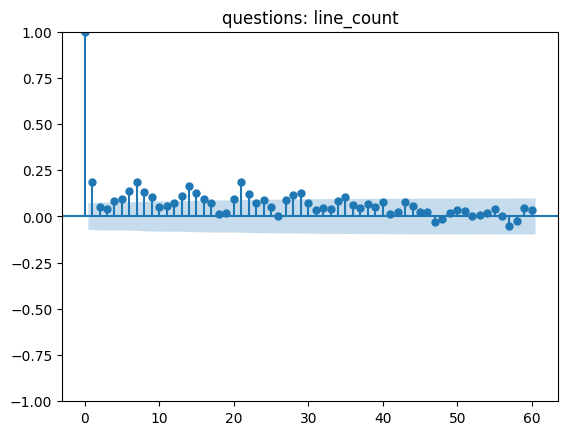

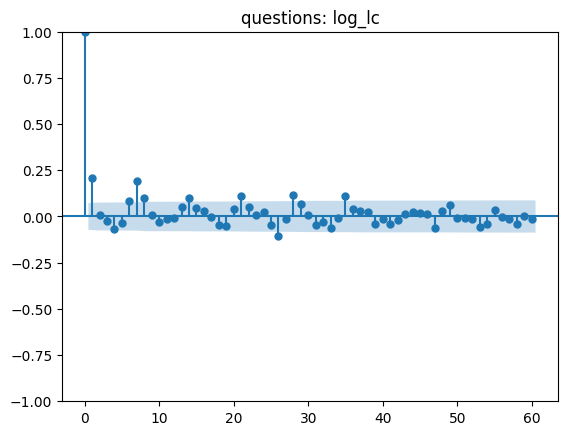

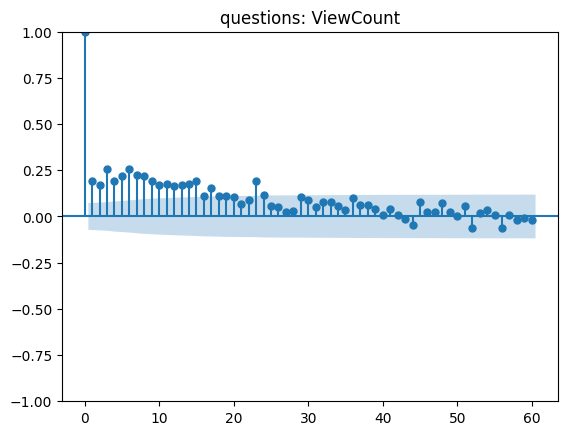

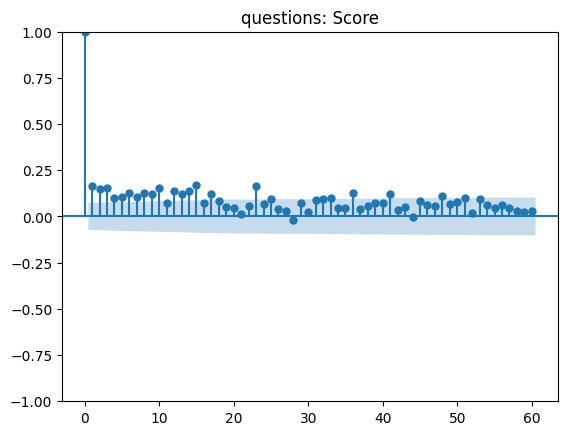

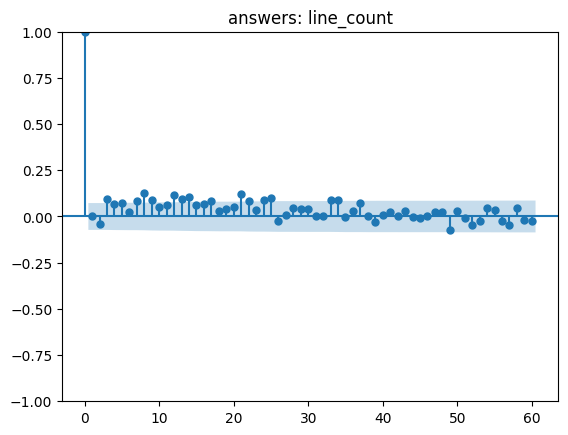

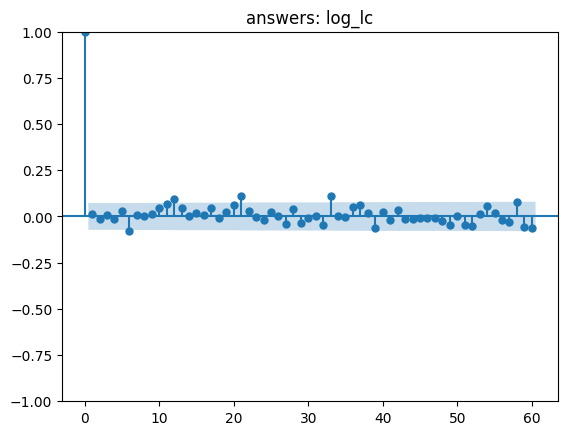

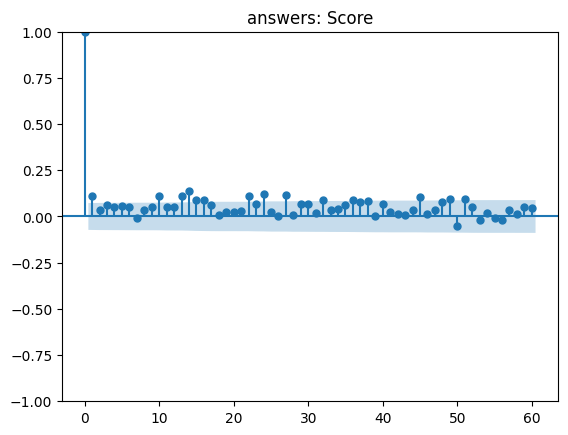

In [7]:
for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            acf(dfs[type], type, outcome) 

### Tag daily time series

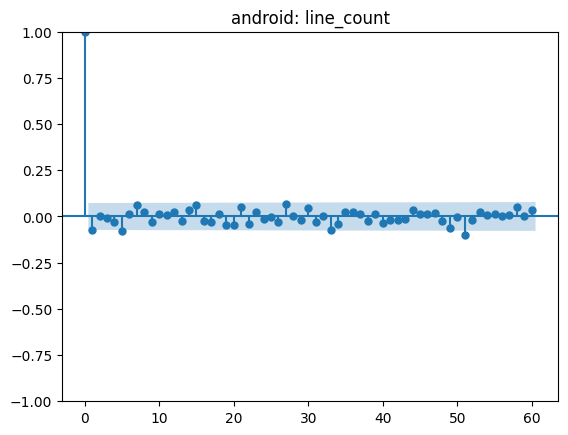

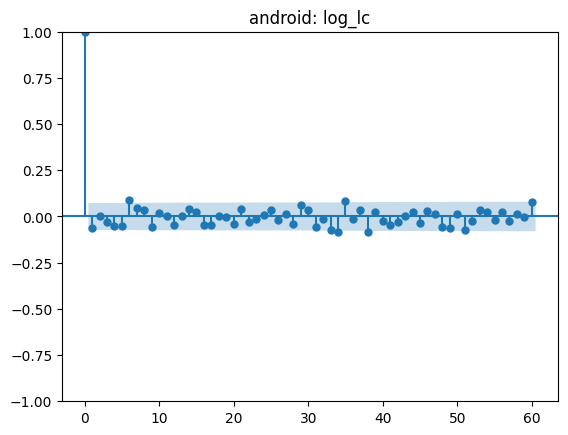

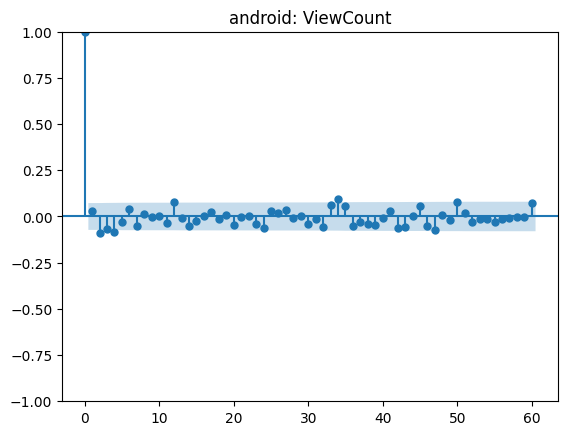

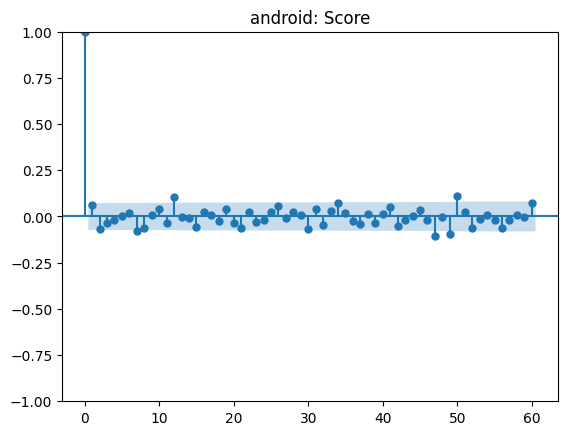

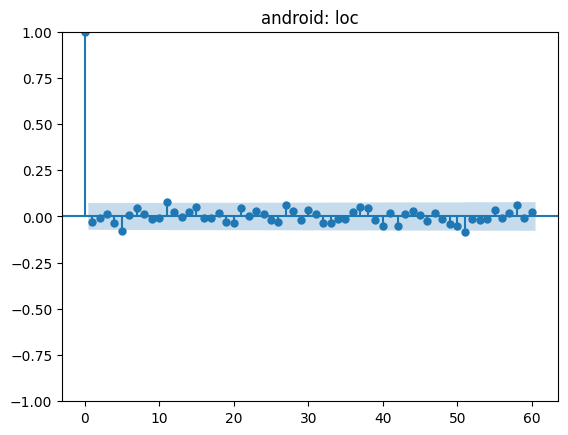

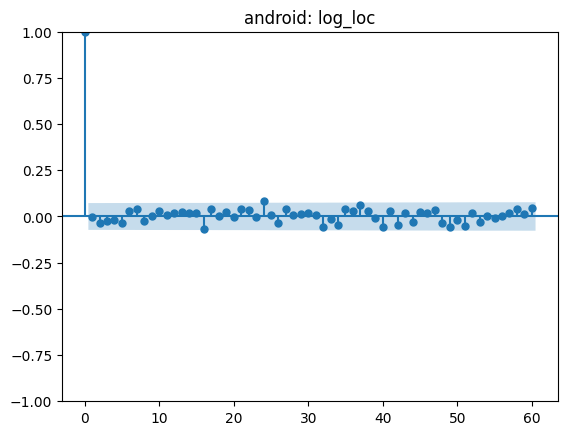

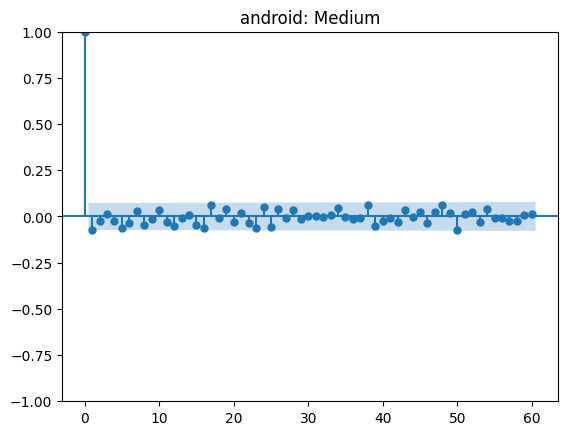

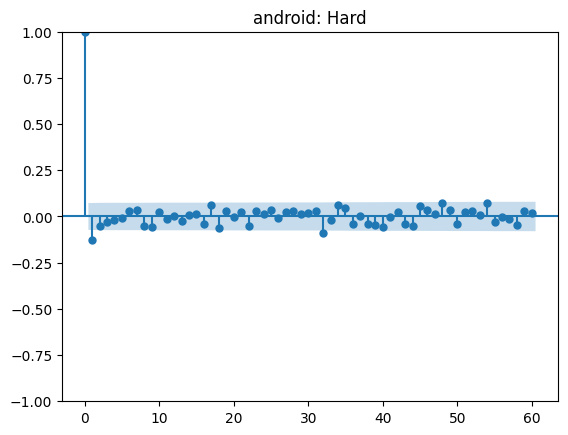

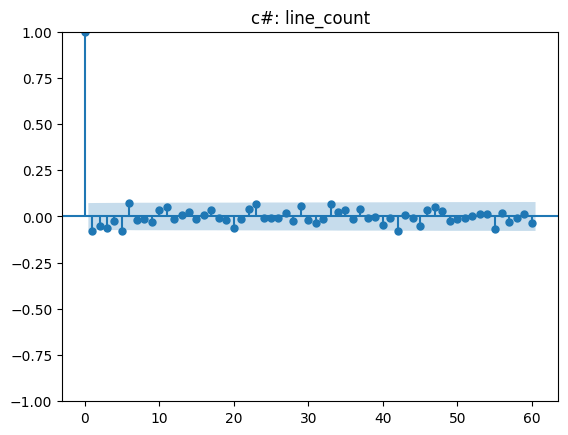

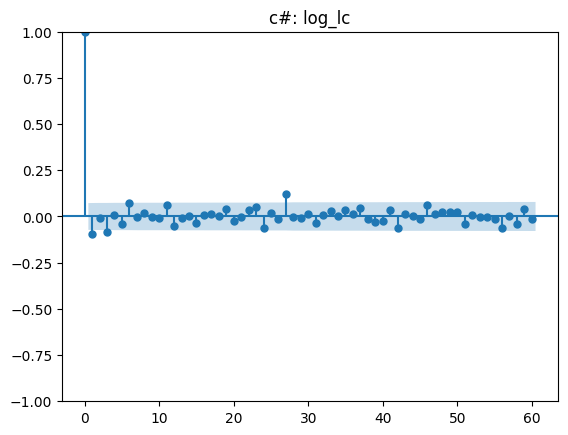

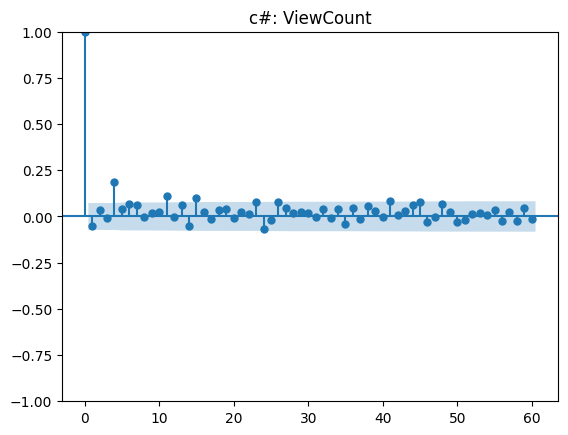

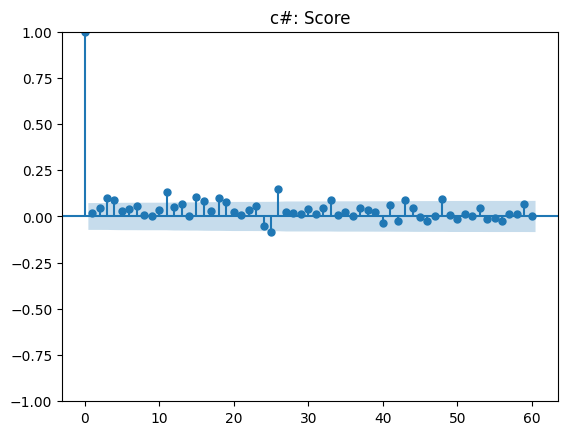

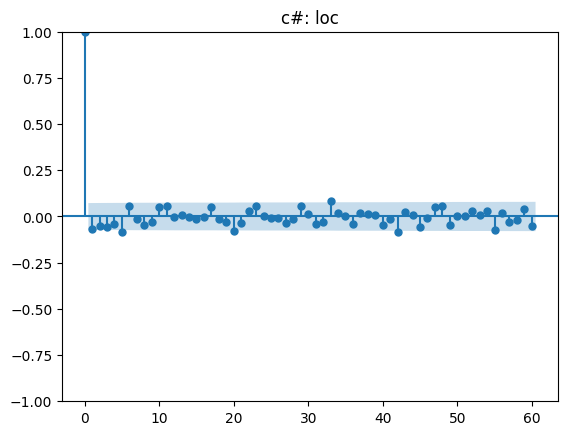

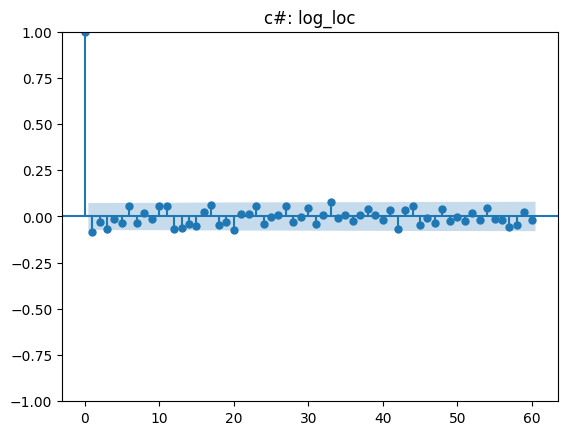

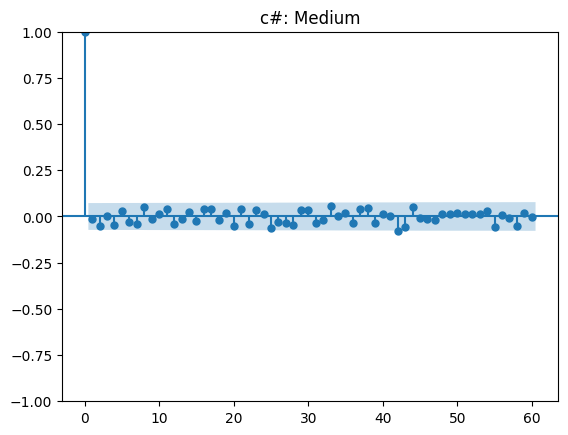

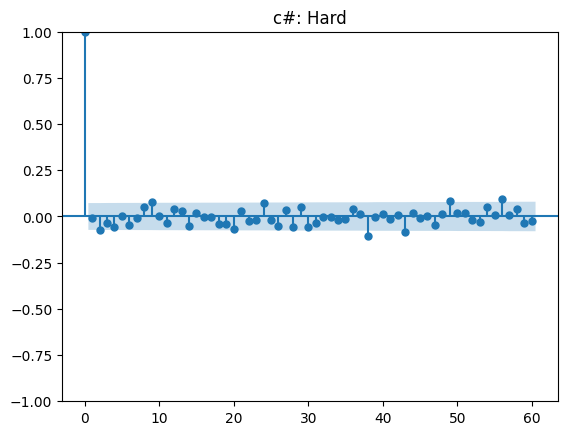

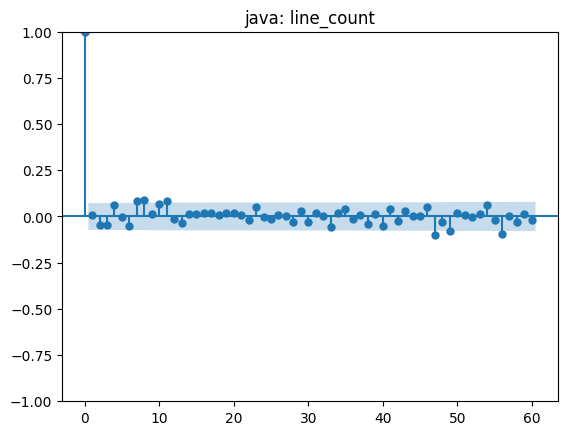

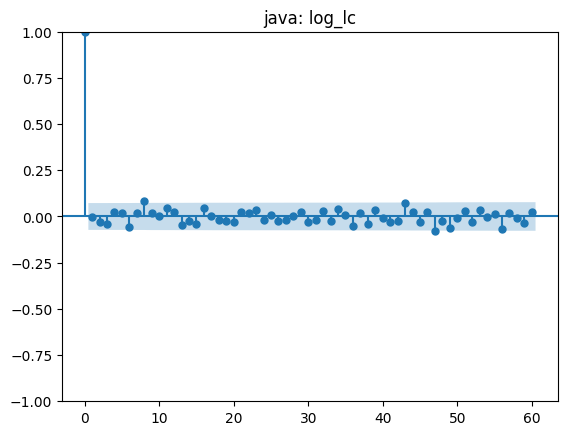

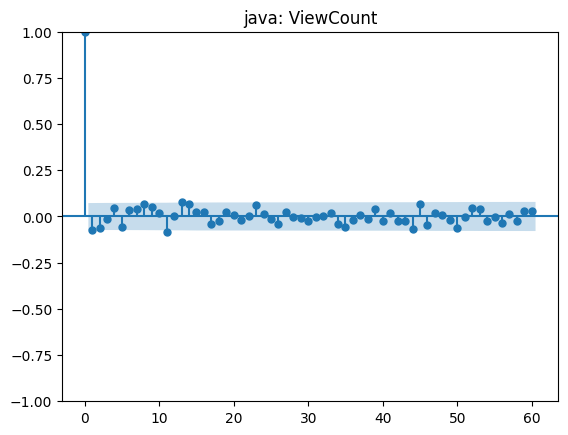

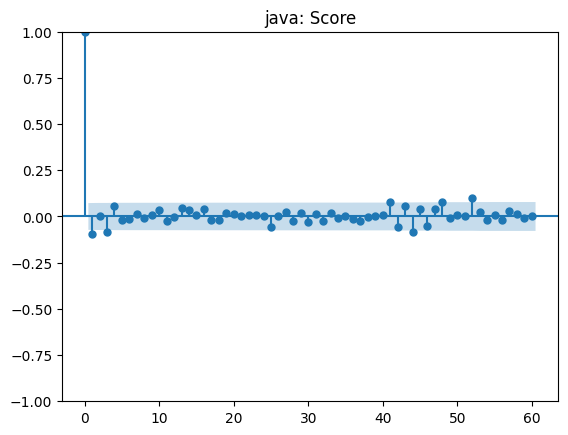

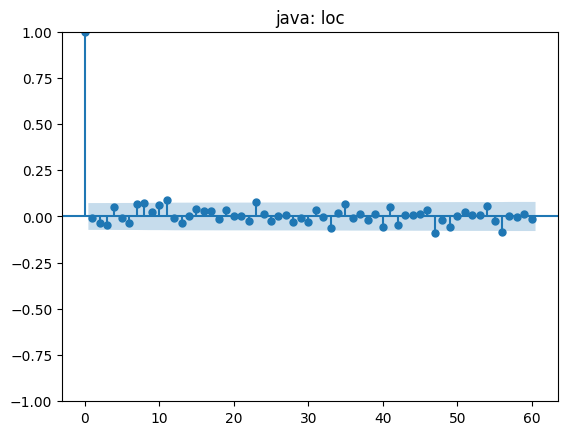

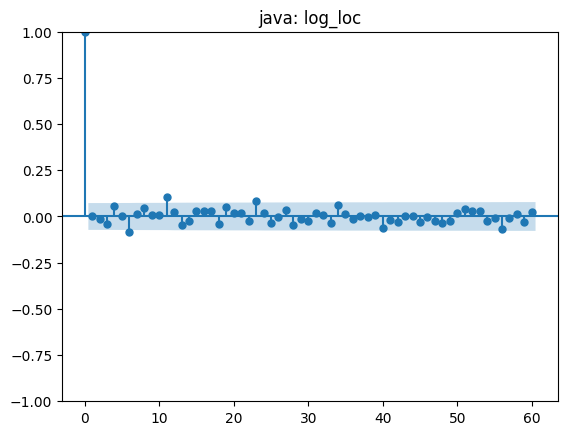

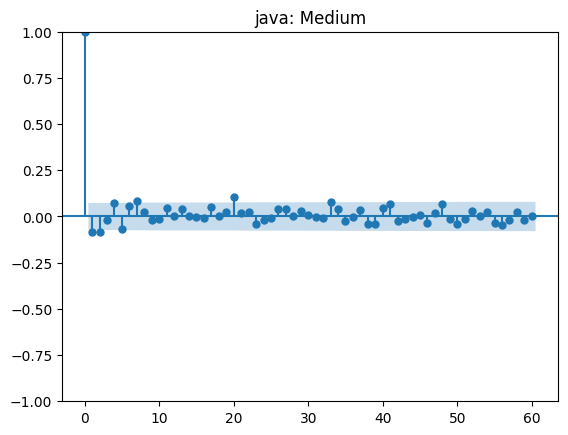

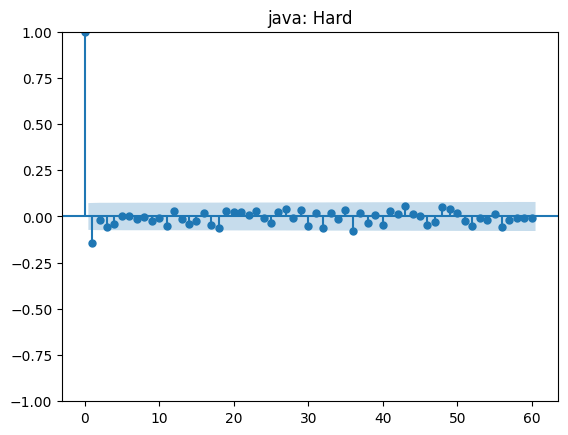

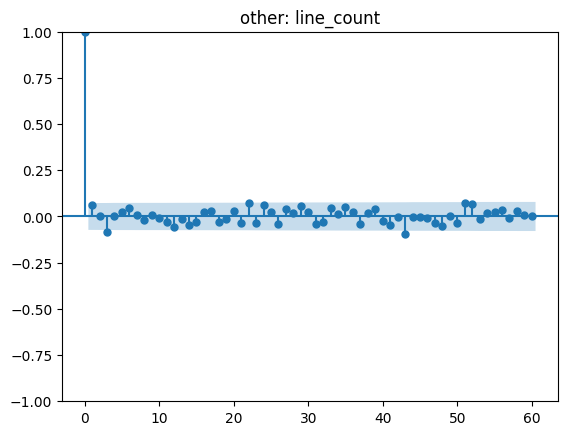

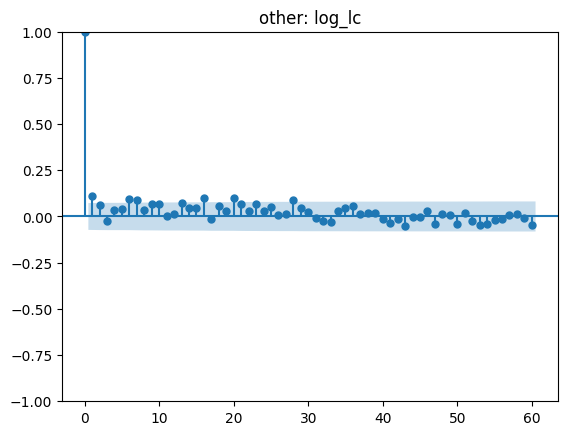

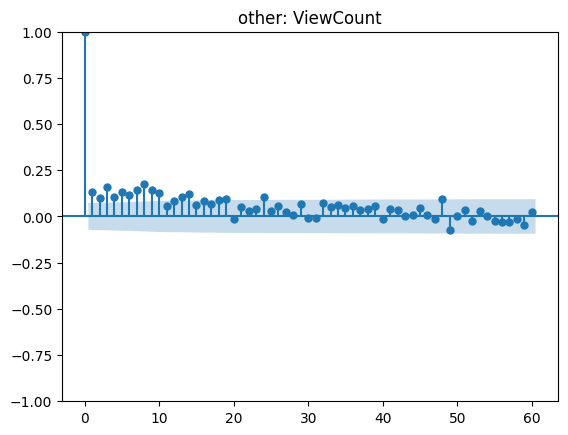

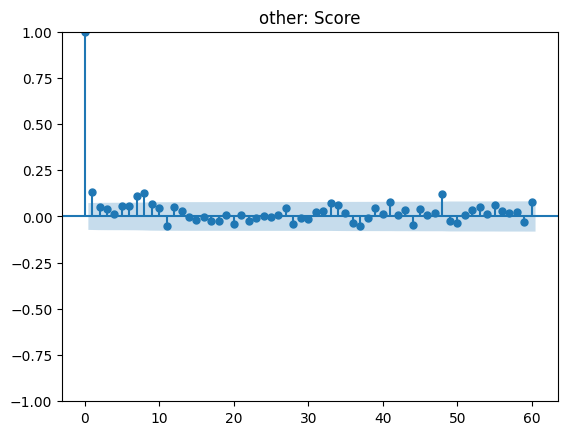

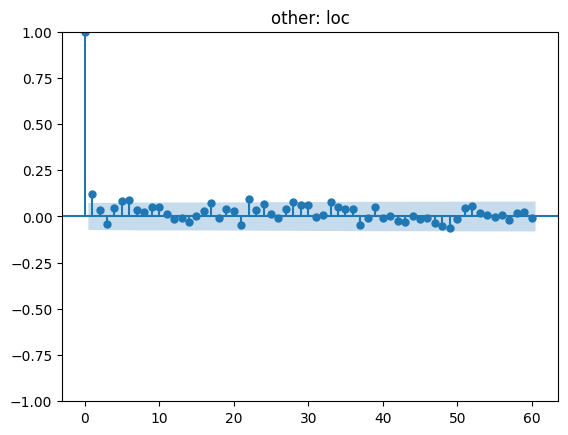

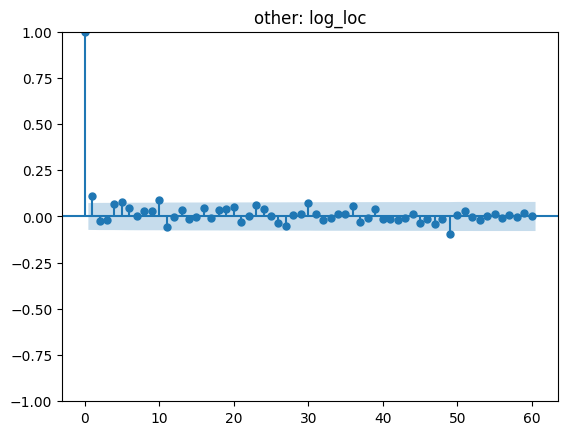

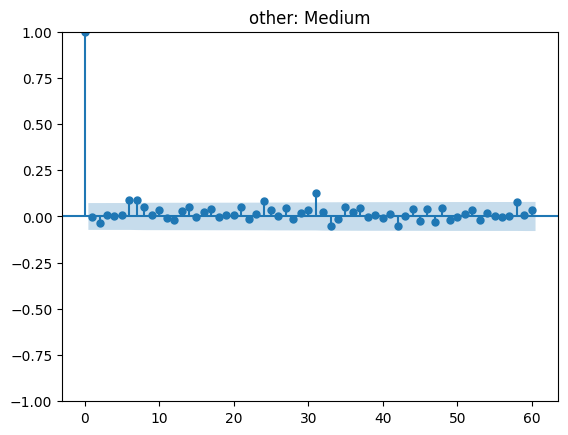

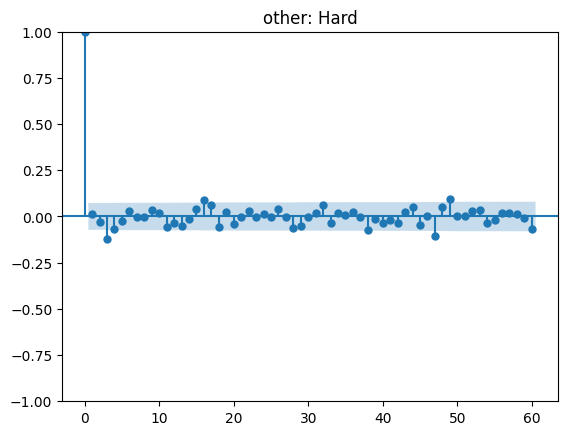

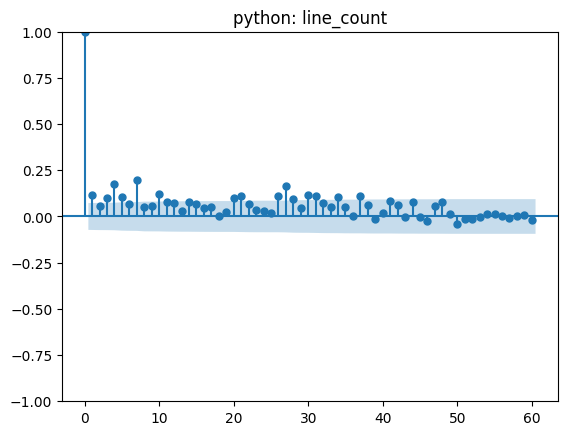

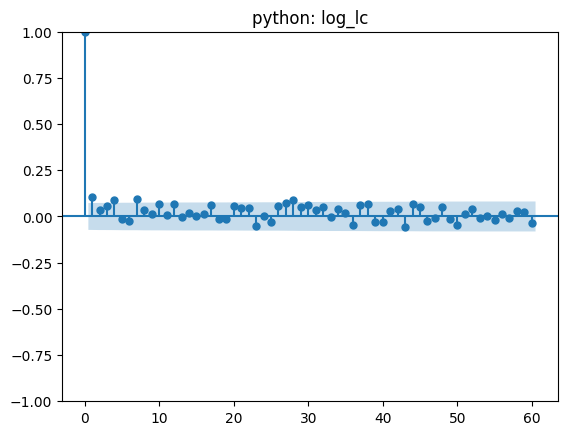

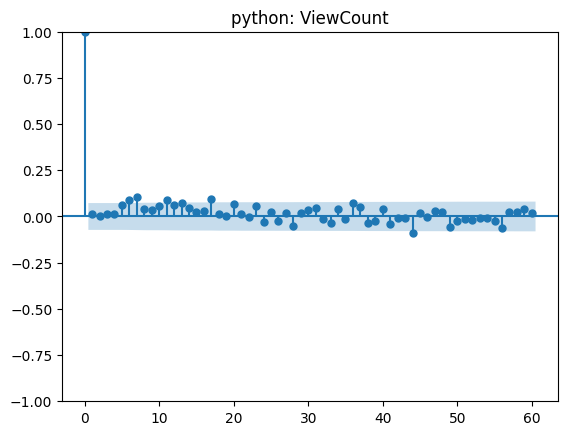

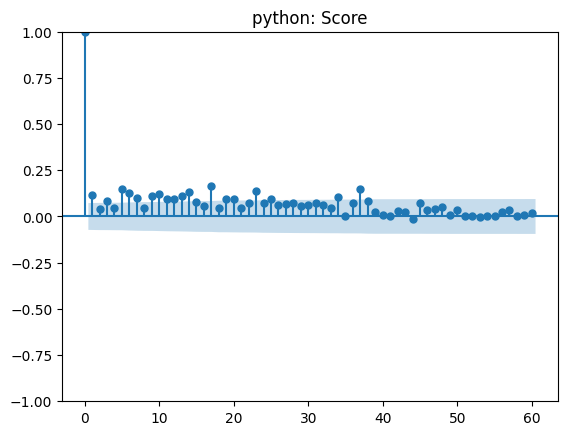

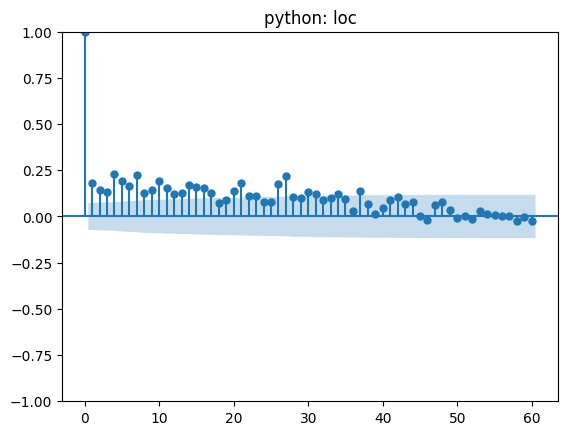

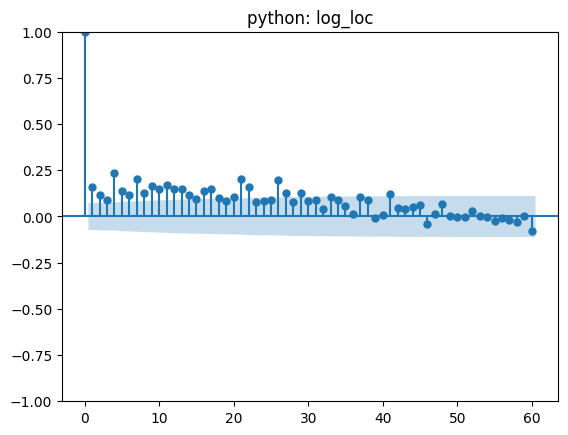

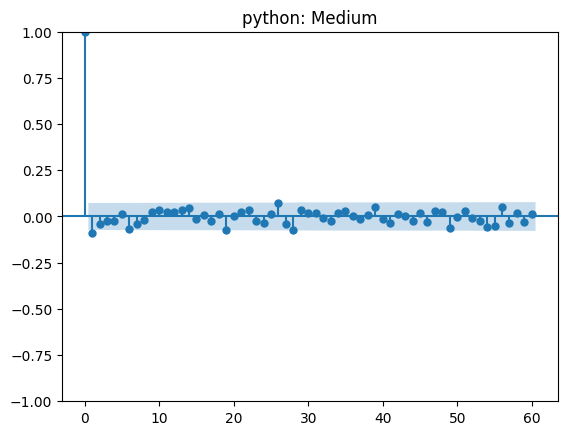

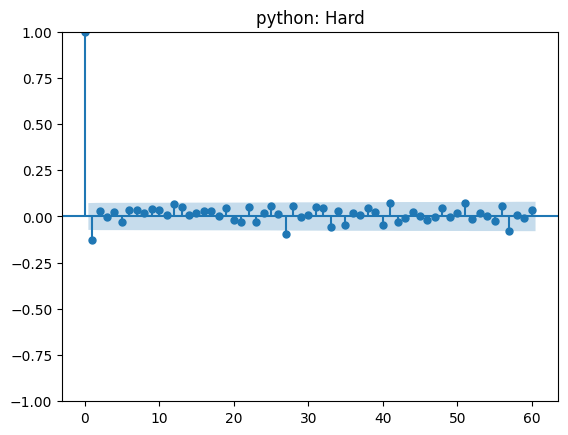

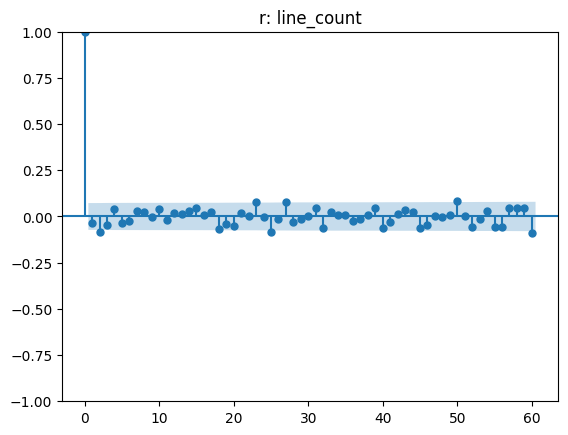

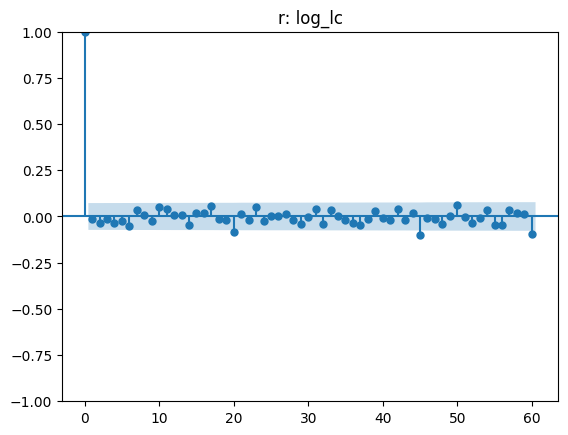

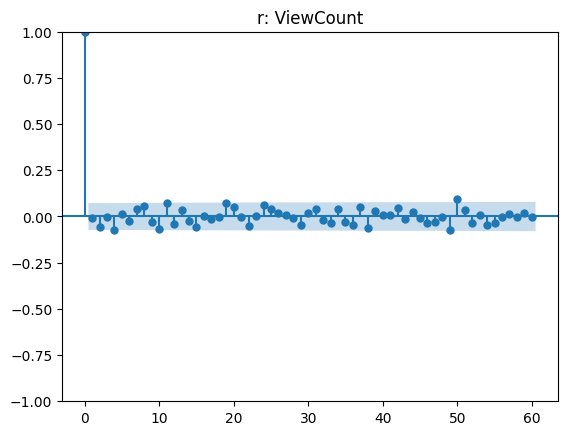

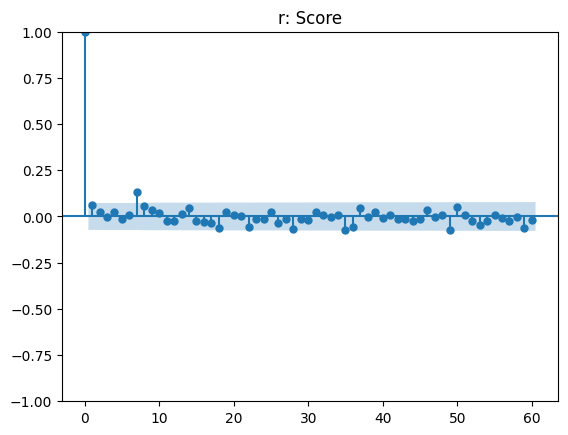

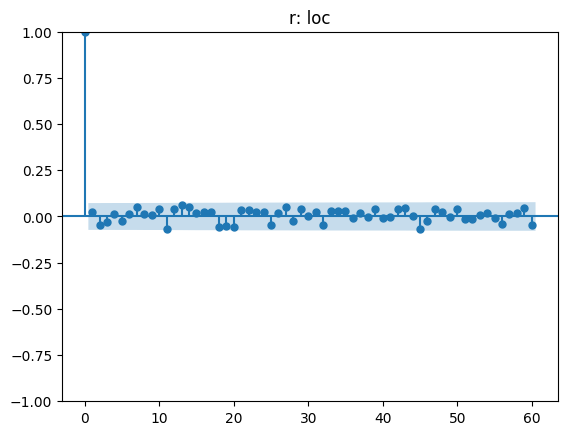

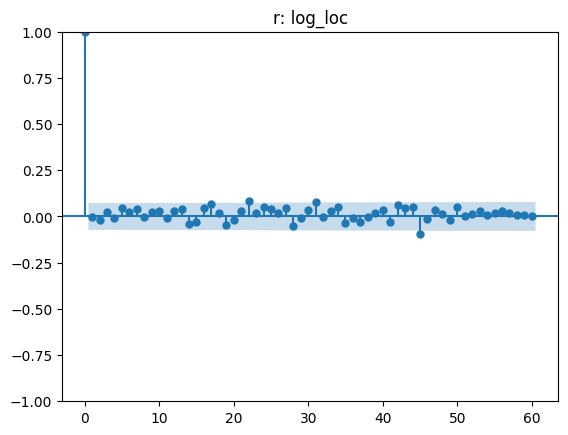

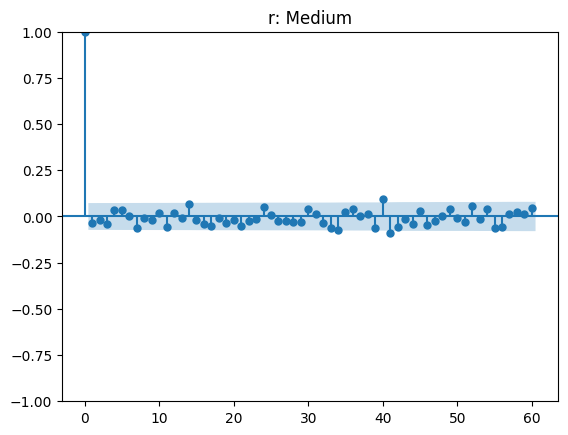

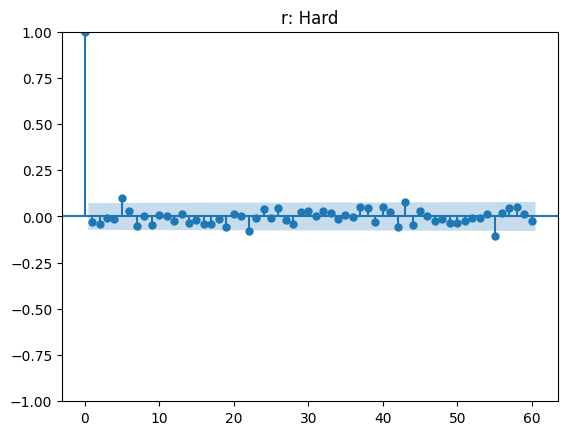

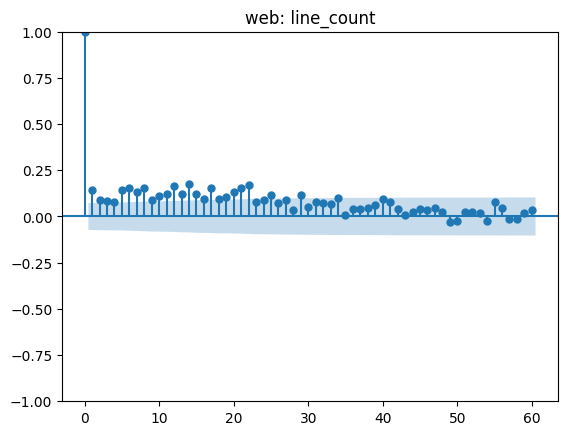

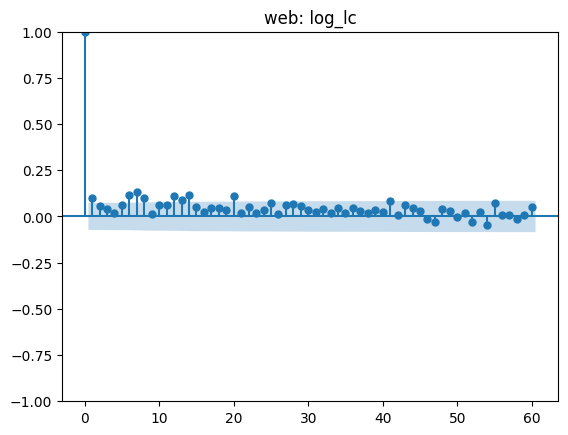

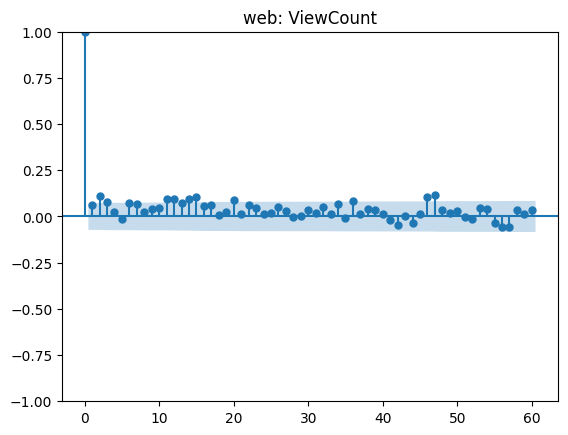

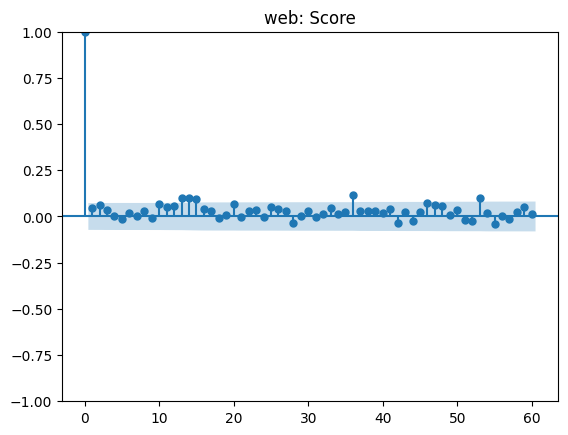

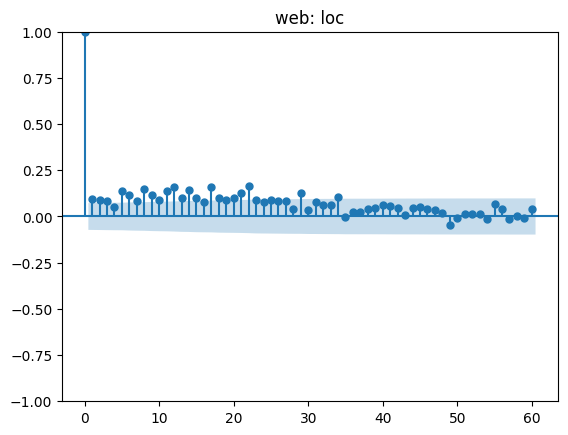

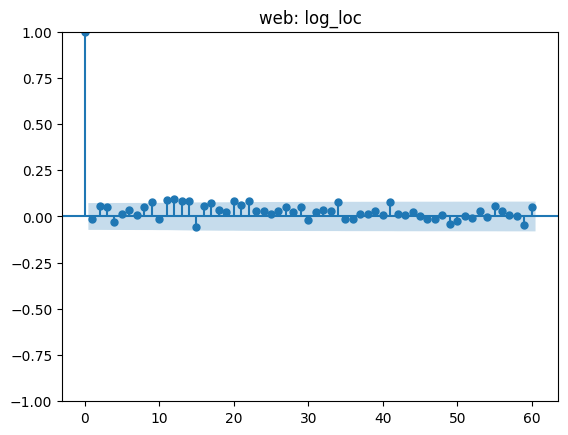

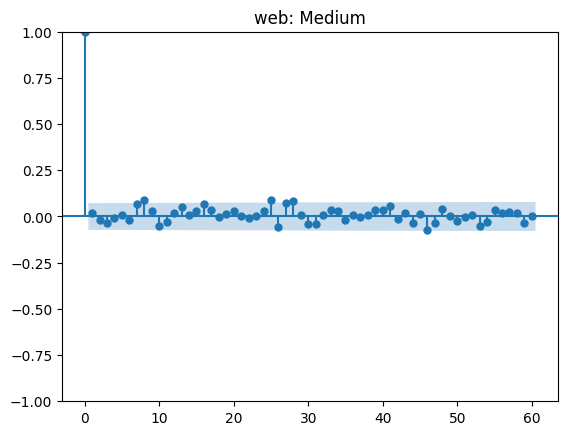

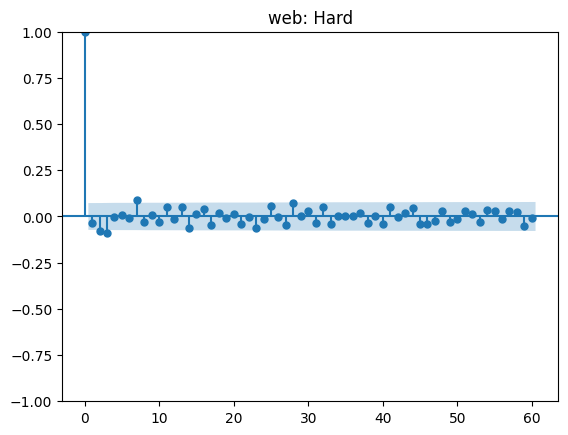

In [8]:
outcomes = ['line_count', 'log_lc', 'ViewCount', 'Score', 'loc', 'log_loc', 'Medium', 'Hard']
for tag in tags:
    for outcome in outcomes:
        acf(tag_dfs[tag], tag, outcome)

# Longest positive effect streak

In [9]:
def resample(dfs, results, outcomes, sample_function=so.block_bootstrap):
    l_hats = {}
    m_hats = {}
    a_hats = {}
    boots = {}
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print(f'Processing: {type} - {outcome}')
        
            l_hats[(type, outcome)] = so.effect_streak(results[(type, outcome)])
            m_hats[(type, outcome)] = so.max_rolling_mean(results[(type, outcome)])
            a_hats[(type, outcome)] = so.auc(results[(type, outcome)])

            res = so.resample_statistic(dfs[type], outcome, sample_function=sample_function, n_resamples=5)
            l_boot = [so.effect_streak(b) for b in res]
            m_boot = [so.max_rolling_mean(b) for b in res]
            a_boot = [so.auc(b) for b in res]

            boots[(type, outcome)] = pd.DataFrame({'streak': l_boot, 'max': m_boot, 'auc': a_boot})

    
    return l_hats, m_hats, a_hats, boots

In [10]:
def observed_stats(results, outcomes):
    l_hats = {}
    m_hats = {}
    a_hats = {}
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            l_hats[(type, outcome)] = so.effect_streak(results[(type, outcome)])
            m_hats[(type, outcome)] = so.max_rolling_mean(results[(type, outcome)])
            a_hats[(type, outcome)] = so.auc(results[(type, outcome)])
    return l_hats, m_hats, a_hats

In [11]:
def resample_results(outcomes, hats, boots, statistics='streak'):
    for type, outcome_list in outcomes.items():
        for outcome in outcome_list:
            print('-------------------------------------------')
            print(f'{type}: {outcome}')

            hat = hats[(type, outcome)]
            boot = boots[(type, outcome)][statistics]
            
            print(f'Observed {statistics}:', hat)
            print('Resampled median:', np.median(boot))
            print('Resampled 5% quantile:', np.quantile(boot, 0.05))

            b_95 = np.quantile(boot, 0.05)
            b_90 = np.quantile(boot, 0.10)
            print(f'95% lower bound on {statistics}:', int(b_95))
            print(f'90% lower bound on {statistics}:', int(b_90))

            p = (boot >= hat).mean()
            print('p-value:', p)

            print('95% interval:', np.quantile(boot, [0.025, 0.975]))

            plt.figure()
            sns.histplot(boot)
            plt.title(f'{type}: {outcome} - {statistics}')

## Question/answers

In [12]:
results = so.read_results('qa.csv')

In [13]:
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc']}

### Bootstrap distribution of the effect streak

-------------------------------------------
questions: log_lc
Observed streak: 1.0
Resampled median: 1.0
Resampled 5% quantile: 0.5357615894039736
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.698
95% interval: [0.44354305 1.        ]
-------------------------------------------
answers: log_lc
Observed streak: 1.0
Resampled median: 0.5894039735099338
Resampled 5% quantile: 0.23807947019867545
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.151
95% interval: [0.1986755 1.       ]
-------------------------------------------
questions: log_lc
Observed max: 0.07508304697799567
Resampled median: 0.07574642971222705
Resampled 5% quantile: 0.057754784367249484
95% lower bound on max: 0
90% lower bound on max: 0
p-value: 0.531
95% interval: [0.05471832 0.09450474]
-------------------------------------------
answers: log_lc
Observed max: 0.04052282424492404
Resampled median: 0.036522244729540854
Resampled 5% quantile: 0.021992266854817626
95% lower bo

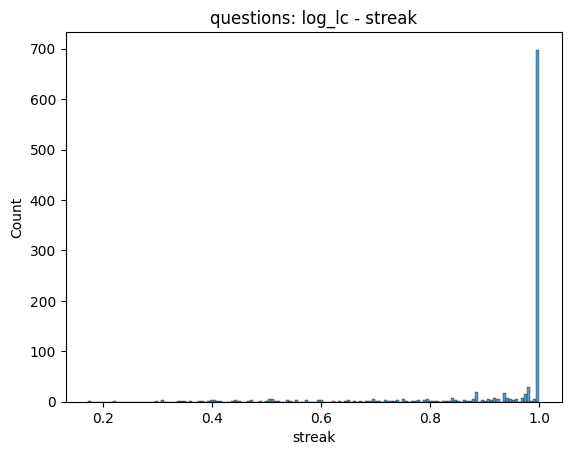

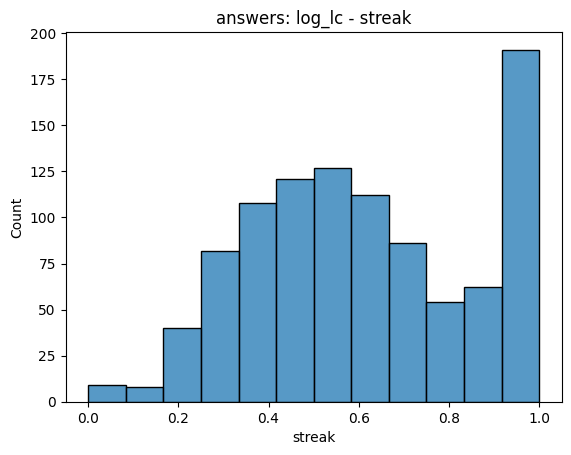

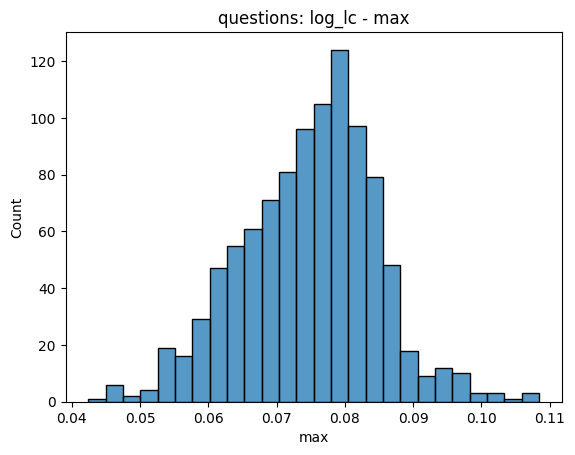

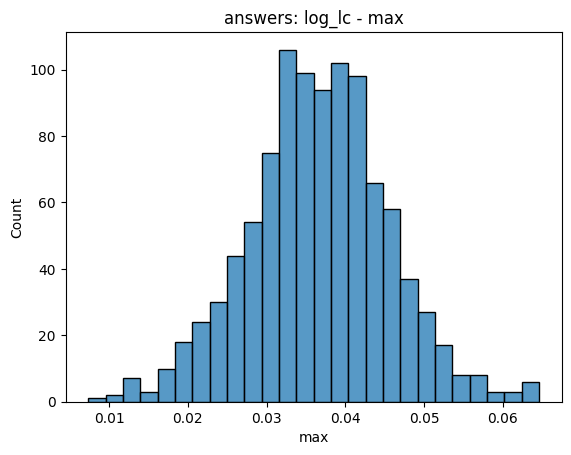

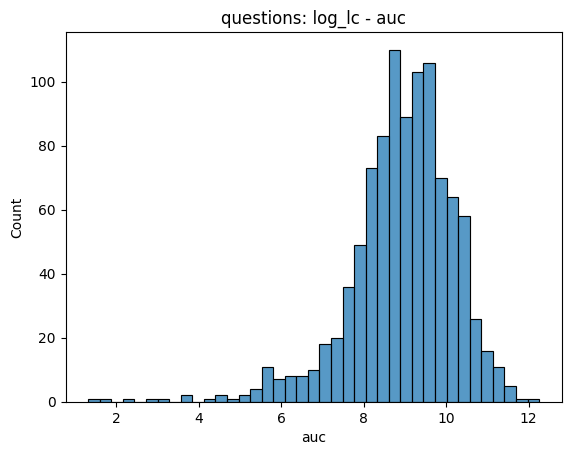

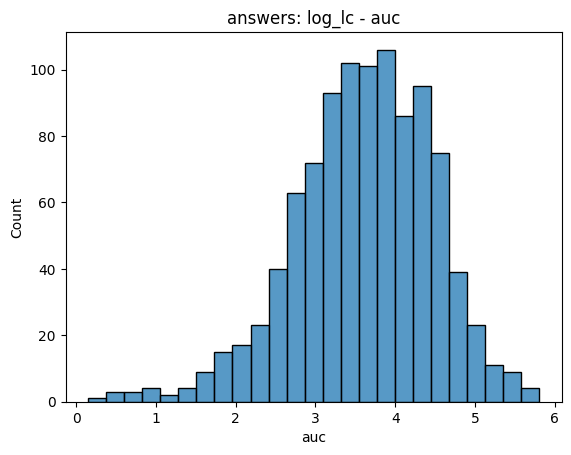

In [14]:
compute_results = False
if compute_results:
    l_hats, m_hats, a_hats, boots = resample(dfs, results, outcomes)
    so.store_results(boots, 'qa_boot.csv')
else:
    boots = so.read_results('qa_boot.csv', resampled=True)
    l_hats, m_hats, a_hats = observed_stats(results, outcomes)

resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

### Permutation distribution of the effect streak

-------------------------------------------
questions: log_lc
Observed streak: 1.0
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.002
95% interval: [0.         0.28476821]
-------------------------------------------
answers: log_lc
Observed streak: 1.0
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.0
95% interval: [0.         0.27168874]
-------------------------------------------
questions: log_lc
Observed max: 0.07508304697799567
Resampled median: 0.0029504871036913002
Resampled 5% quantile: -0.008973378386906346
95% lower bound on max: 0
90% lower bound on max: 0
p-value: 0.0
95% interval: [-0.01195674  0.01753803]
-------------------------------------------
answers: log_lc
Observed max: 0.04052282424492404
Resampled median: 0.00167951962507945
Resampled 5% quantile: -0.004235055089468515
95% lower bound on max: 0
90% lower bound on max: 0
p-v

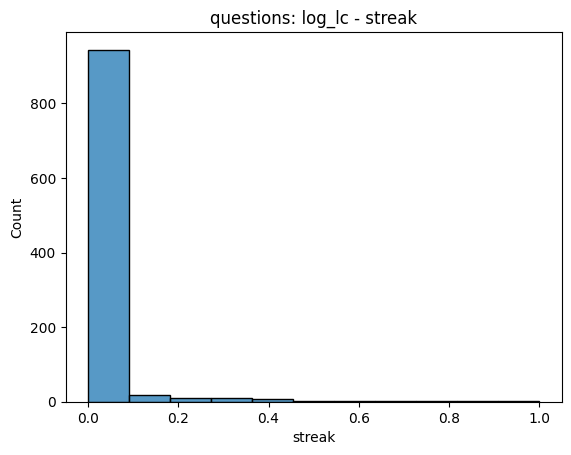

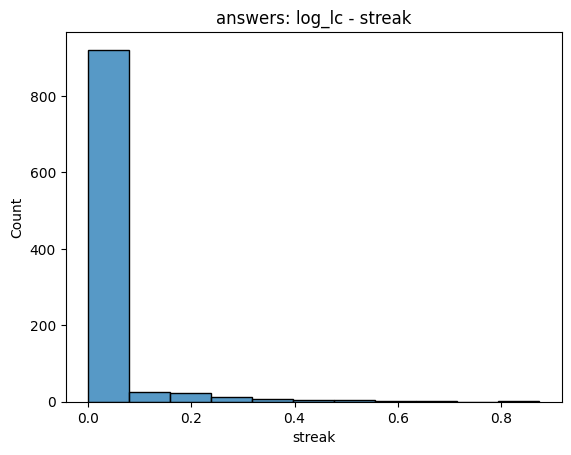

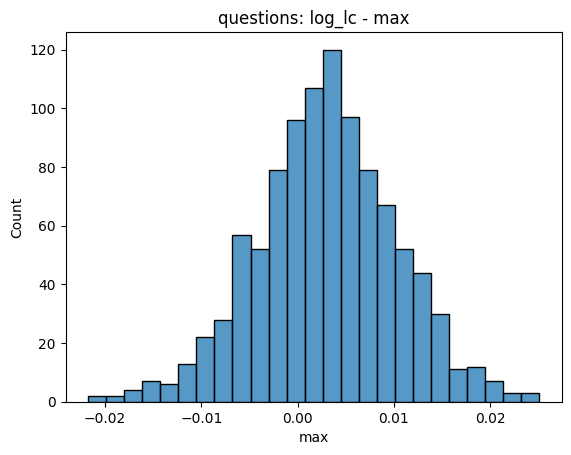

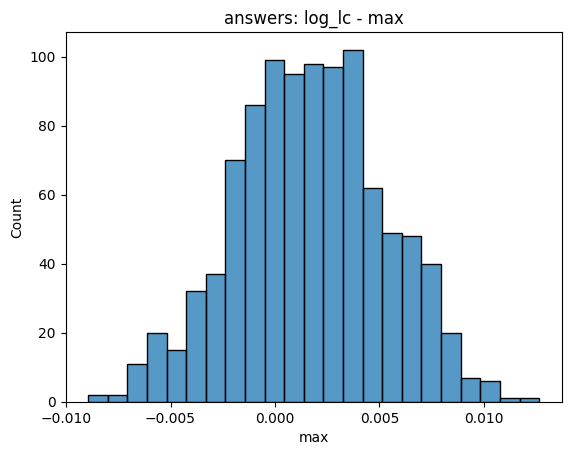

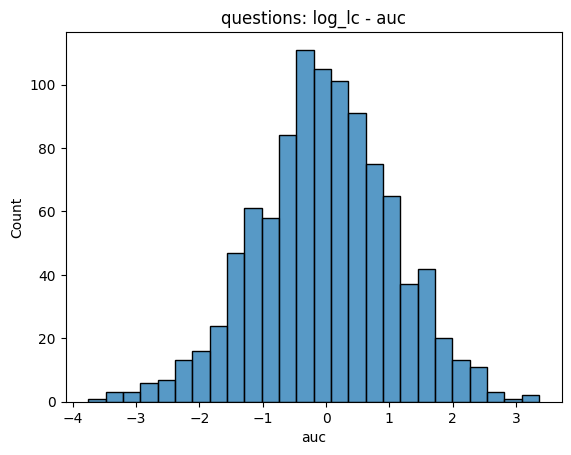

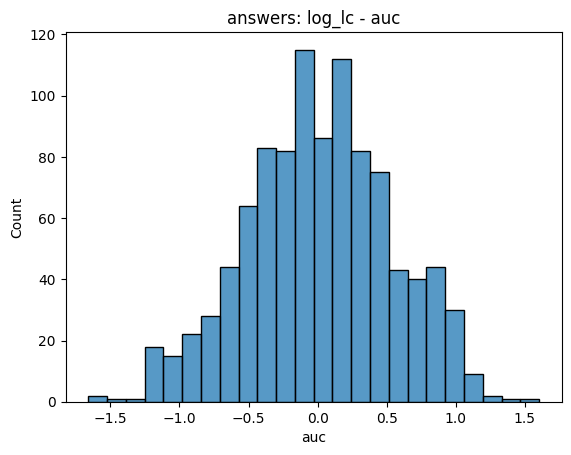

In [15]:
if compute_results:
    l_hats, m_hats, a_hats, boots = resample(dfs, results, outcomes, sample_function=so.permute_treatment)
    so.store_results(boots, 'qa_perm.csv')
else:
    boots = so.read_results('qa_perm.csv', resampled=True)
    l_hats, m_hats, a_hats = observed_stats(results, outcomes)
    
resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

## Tags

In [16]:
tag_results = so.read_results('tags.csv')

In [17]:
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'java': targets, 'python': targets, 'web': targets}

-------------------------------------------
java: log_lc
Observed streak: 0.6490066225165563
Resampled median: 0.3576158940397351
Resampled 5% quantile: 0.16523178807947014
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.109
95% interval: [0.13245033 1.        ]
-------------------------------------------
java: log_loc
Observed streak: 0.4105960264900662
Resampled median: 0.1986754966887417
Resampled 5% quantile: 0.0728476821192053
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.094
95% interval: [0.05960265 0.64917219]
-------------------------------------------
java: Medium
Observed streak: 0.4105960264900662
Resampled median: 0.2185430463576159
Resampled 5% quantile: 0.0596026490066225
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.077
95% interval: [0.0397351  0.52980132]
-------------------------------------------
python: log_lc
Observed streak: 1.0
Resampled median: 0.9668874172185432
Resampled 5% quantile: 0.3841059

C:\Users\denis\AppData\Local\Temp\ipykernel_17552\2218253018.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


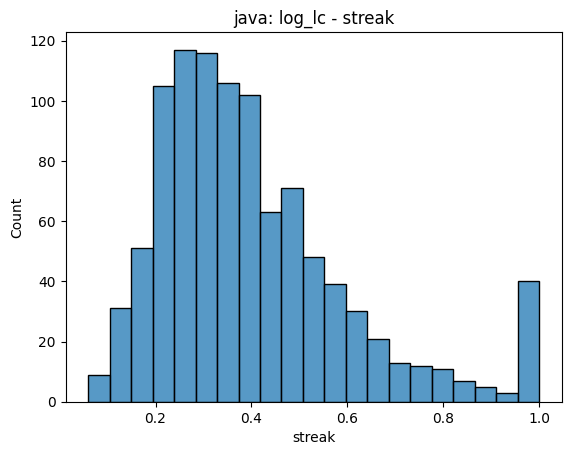

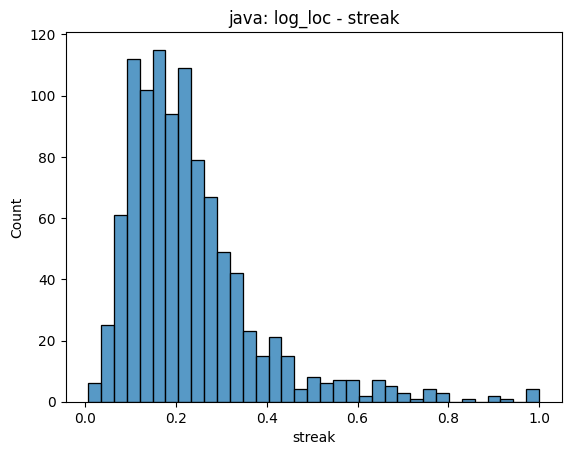

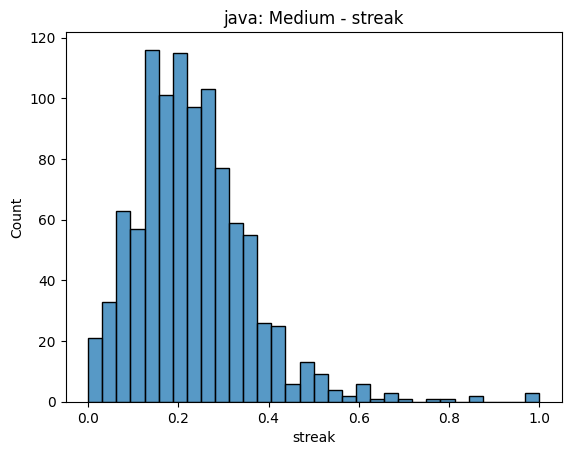

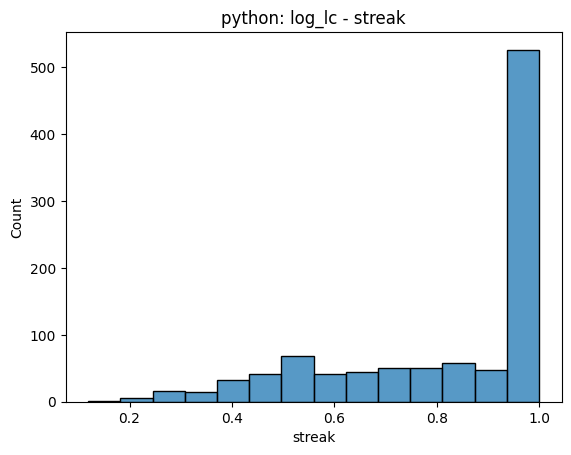

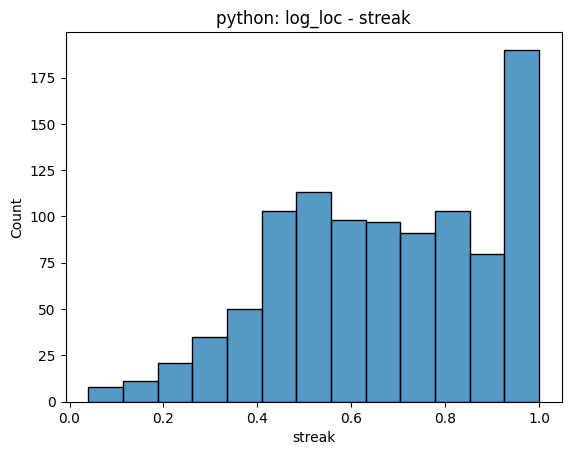

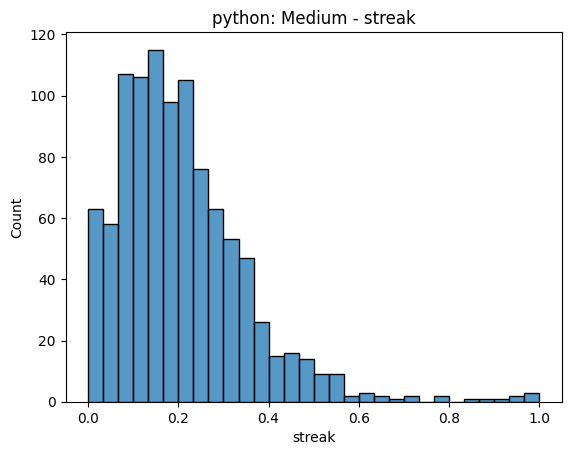

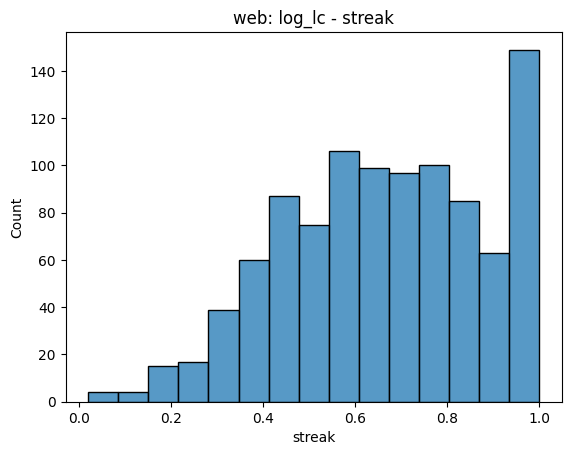

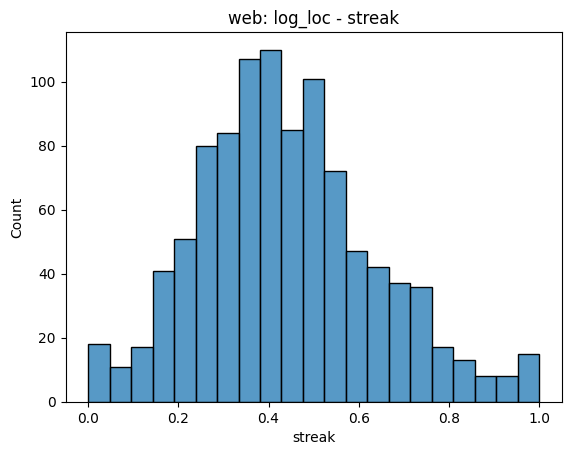

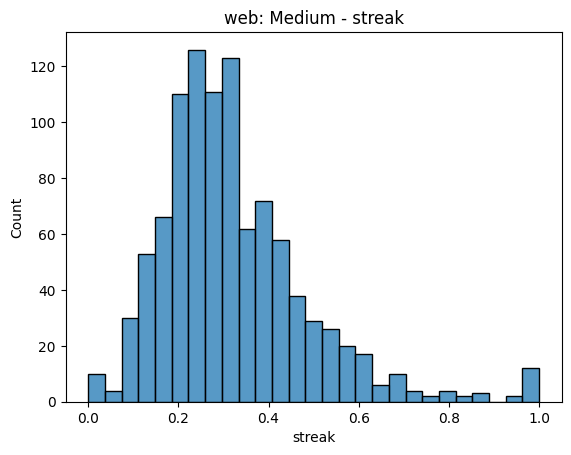

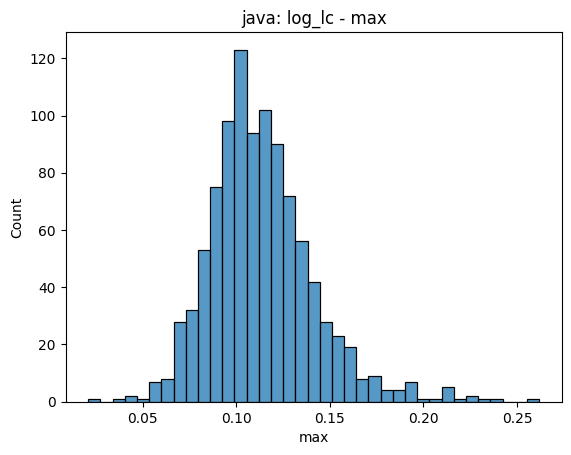

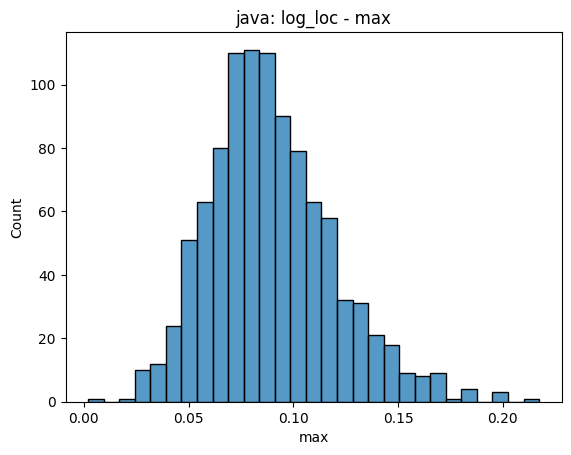

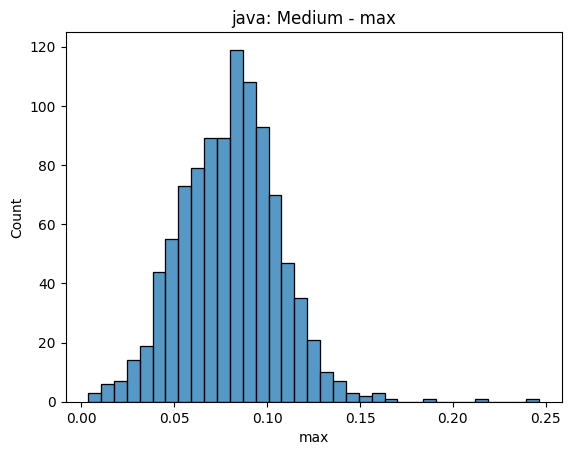

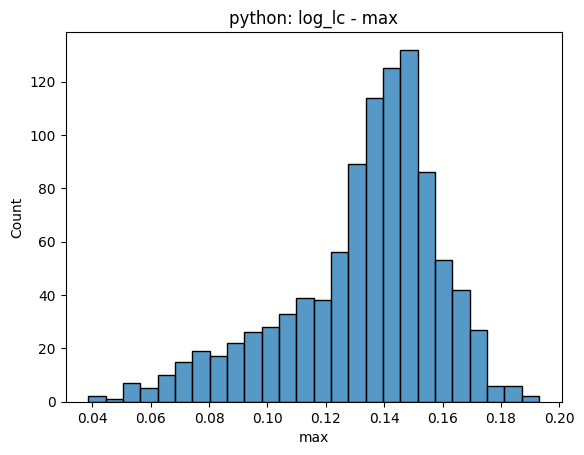

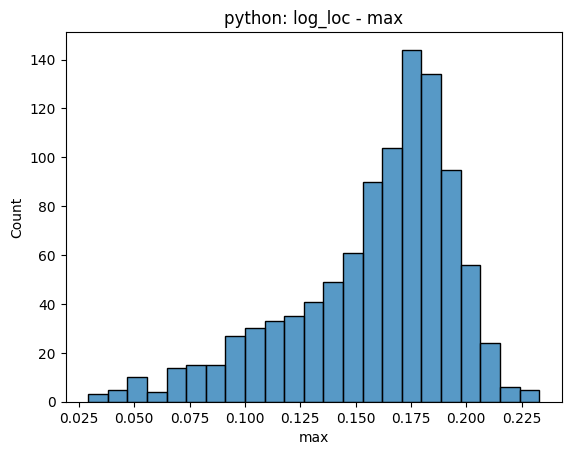

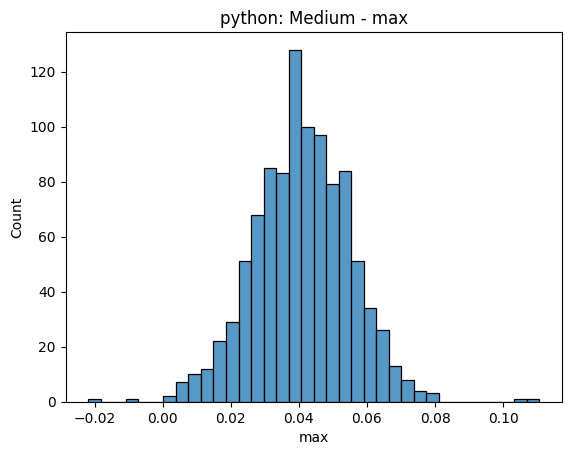

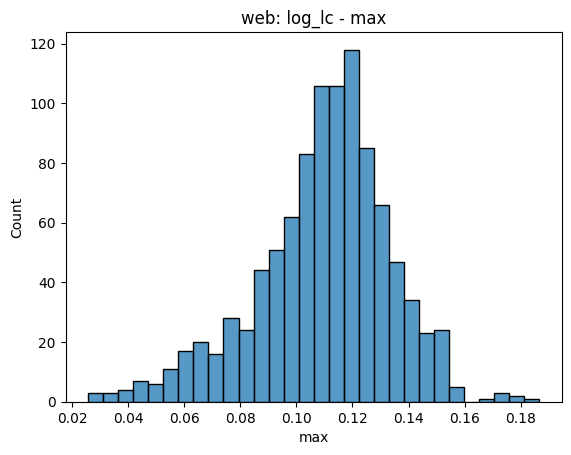

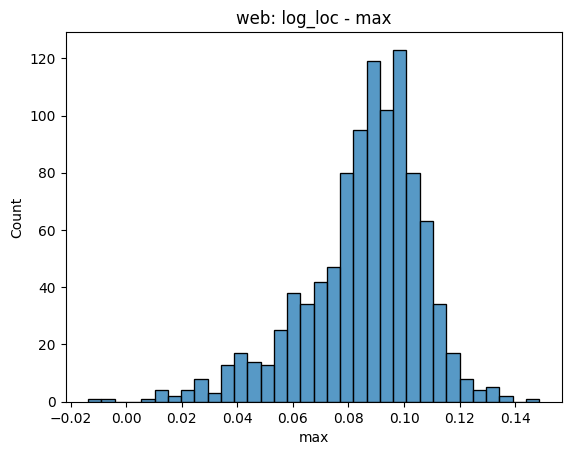

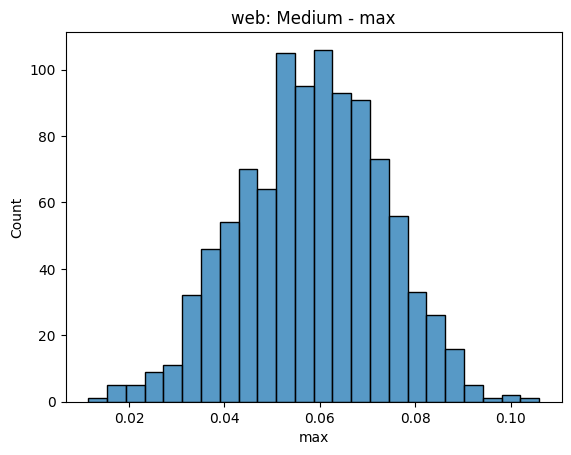

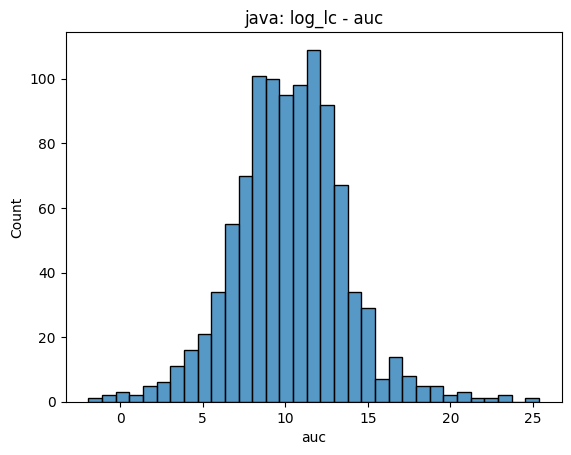

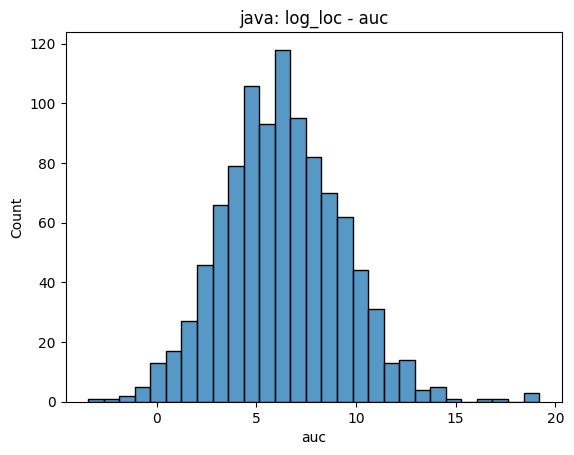

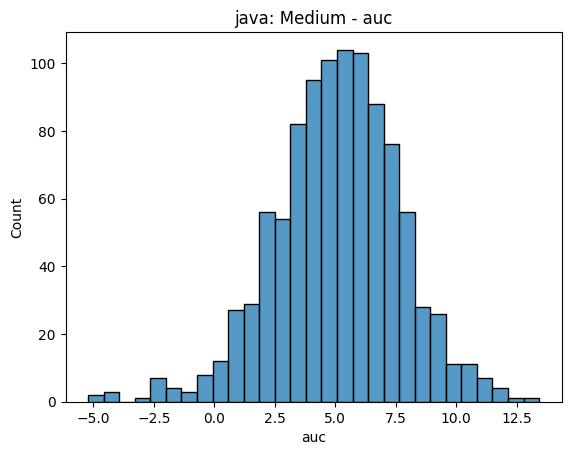

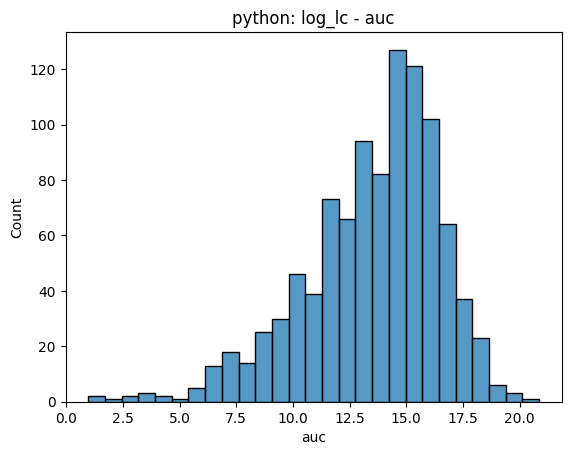

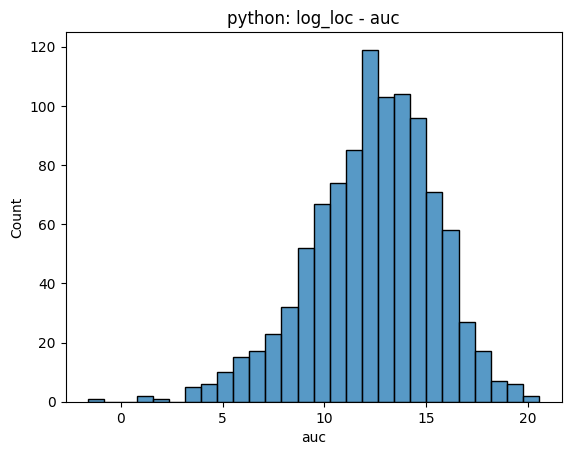

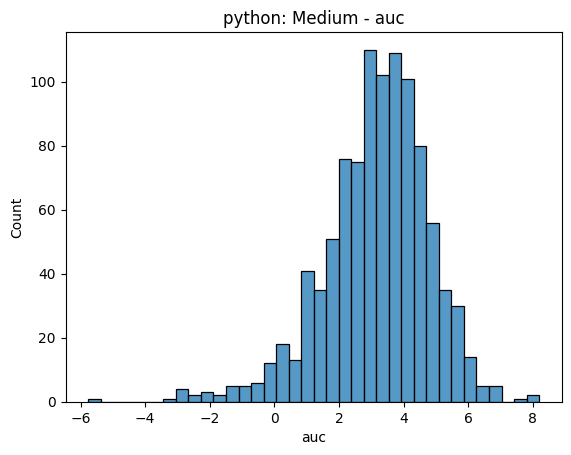

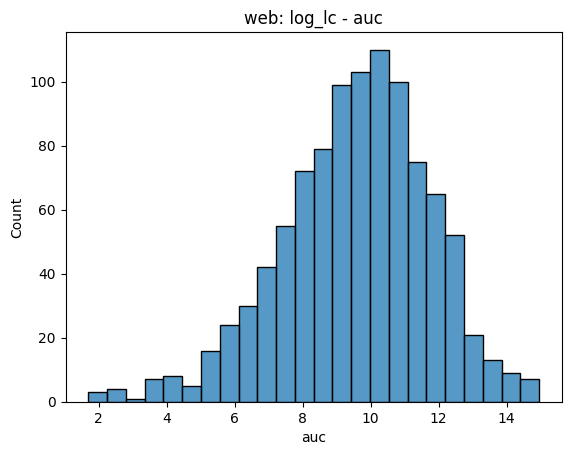

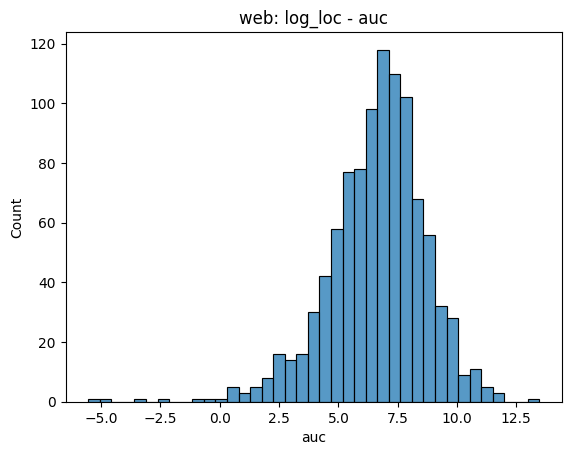

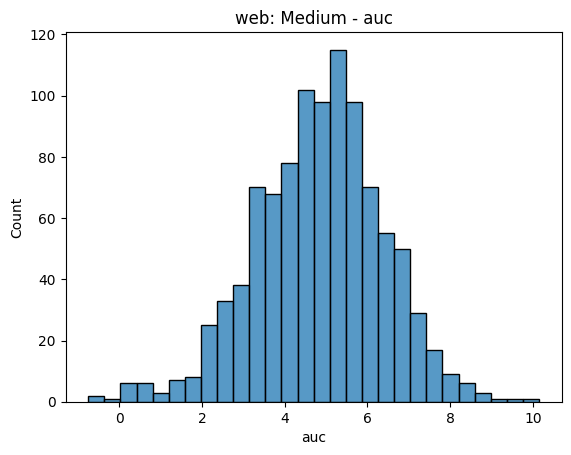

In [18]:
if compute_results:
    l_hats, m_hats, a_hats, boots = resample(tag_dfs, tag_results, outcomes)
    so.store_results(boots, 'tags_boot.csv')
else:
    boots = so.read_results('tags_boot.csv', resampled=True)
    l_hats, m_hats, a_hats = observed_stats(tag_results, outcomes)

resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

-------------------------------------------
java: log_lc
Observed streak: 0.6490066225165563
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.004
95% interval: [0.         0.21208609]
-------------------------------------------
java: log_loc
Observed streak: 0.4105960264900662
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.009
95% interval: [0.         0.17251656]
-------------------------------------------
java: Medium
Observed streak: 0.4105960264900662
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.009
95% interval: [0.         0.23195364]
-------------------------------------------
python: log_lc
Observed streak: 1.0
Resampled median: 0.0
Resampled 5% quantile: 0.0
95% lower bound on streak: 0
90% lower bound on streak: 0
p-value: 0.002
95% interval: [0.         0.27201987]


C:\Users\denis\AppData\Local\Temp\ipykernel_17552\2218253018.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


-------------------------------------------
python: log_loc
Observed auc: 14.582933423650822
Resampled median: -0.021085164130050398
Resampled 5% quantile: -2.311373243853514
95% lower bound on auc: -2
90% lower bound on auc: -1
p-value: 0.0
95% interval: [-2.74359648  3.06767818]
-------------------------------------------
python: Medium
Observed auc: 4.131203932854905
Resampled median: 0.02233806521883105
Resampled 5% quantile: -1.948299278890736
95% lower bound on auc: -1
90% lower bound on auc: -1
p-value: 0.0
95% interval: [-2.38158237  2.28307249]
-------------------------------------------
web: log_lc
Observed auc: 10.969068974742138
Resampled median: -0.054287545951129154
Resampled 5% quantile: -1.9745585852011485
95% lower bound on auc: -1
90% lower bound on auc: -1
p-value: 0.0
95% interval: [-2.43113605  2.21112723]
-------------------------------------------
web: log_loc
Observed auc: 7.6231776067259
Resampled median: -0.03584880823046235
Resampled 5% quantile: -2.328466469

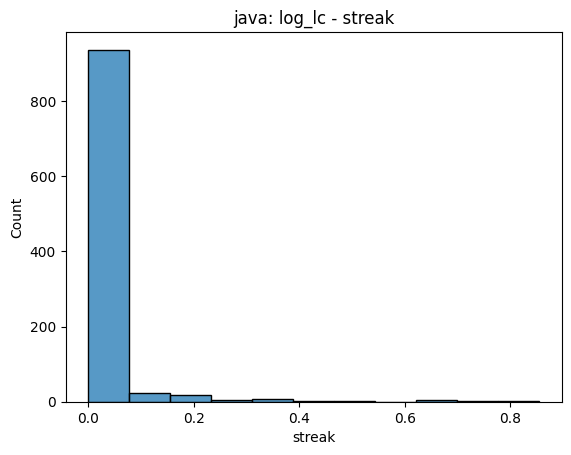

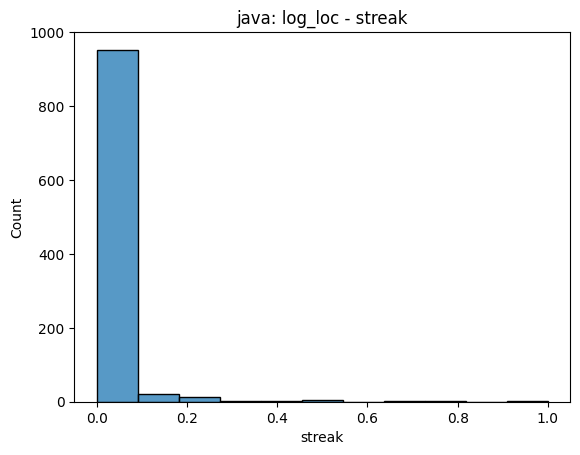

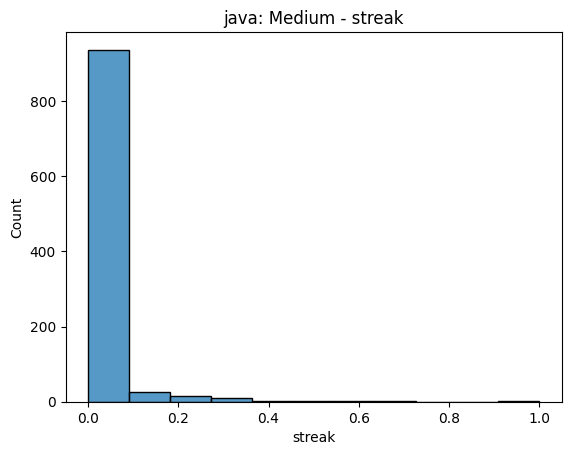

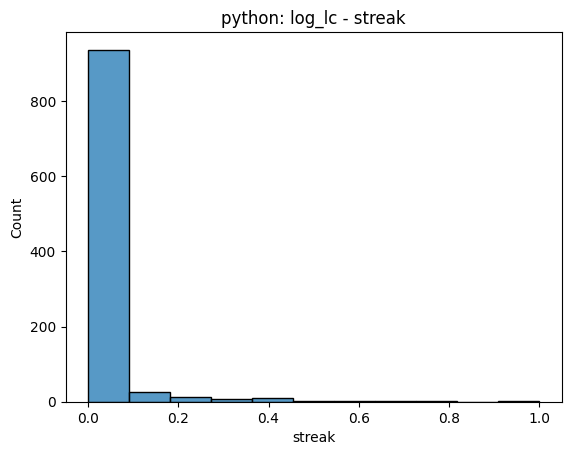

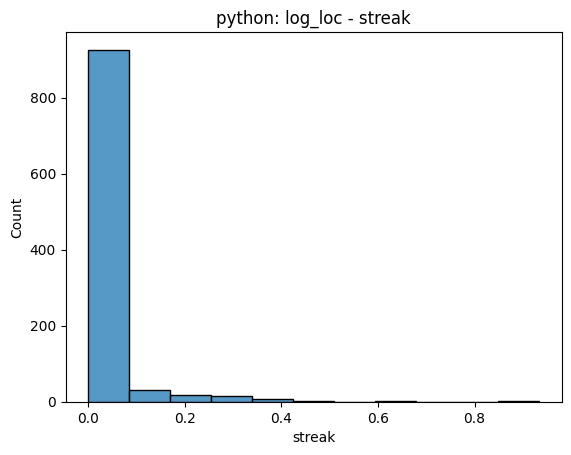

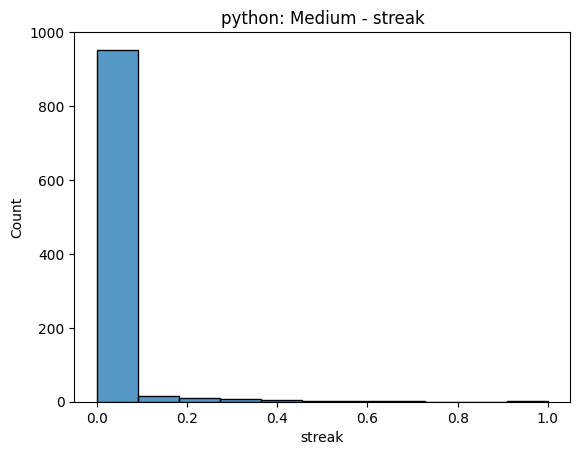

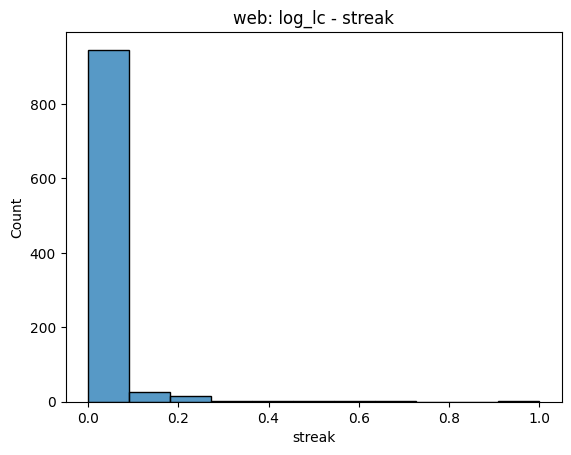

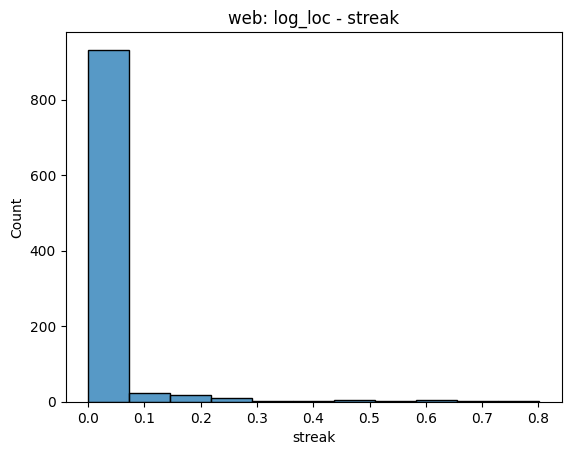

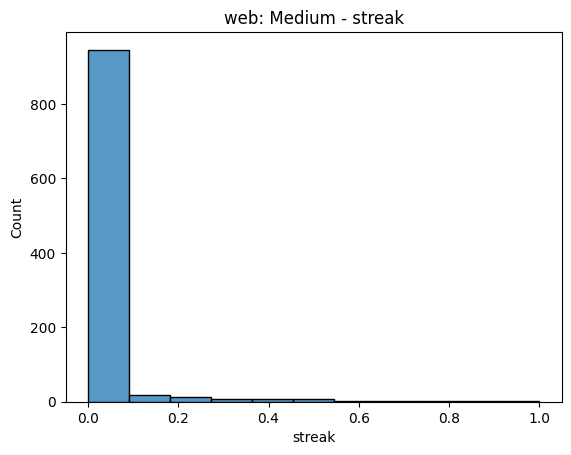

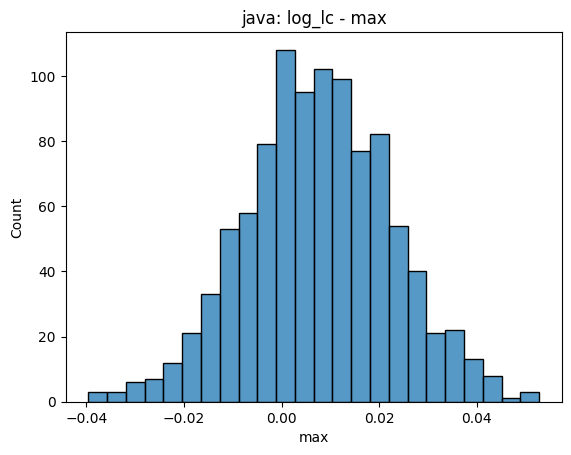

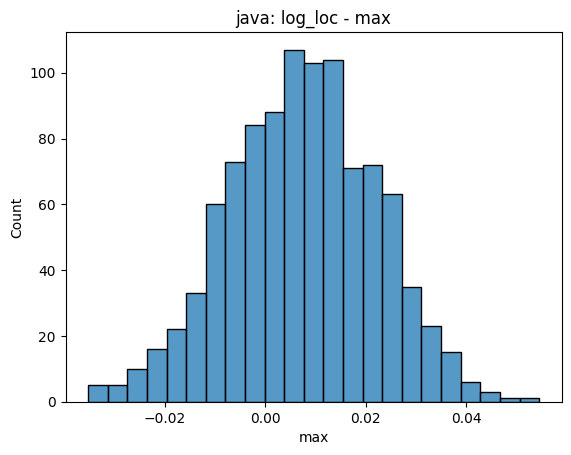

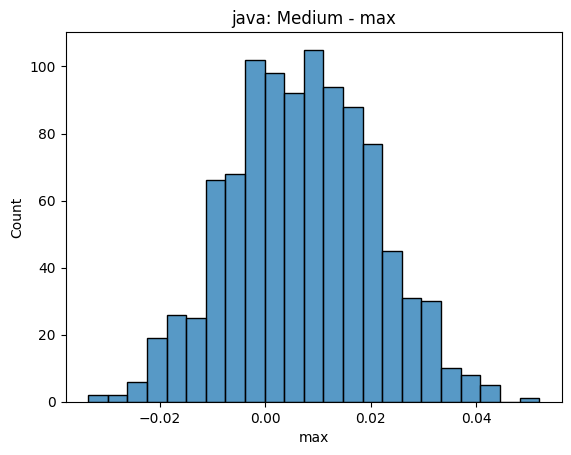

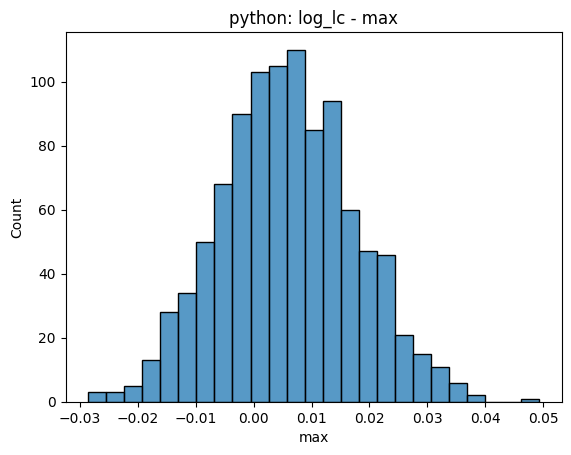

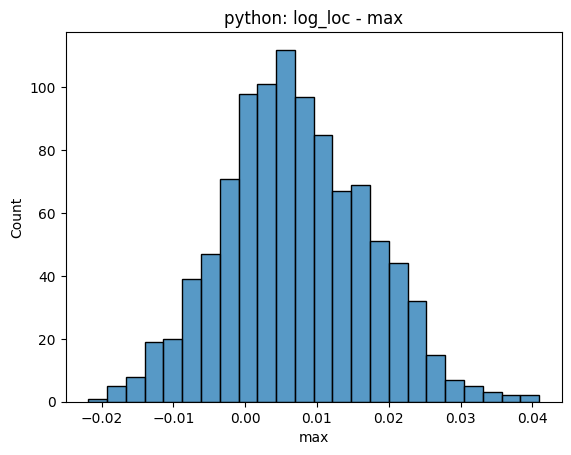

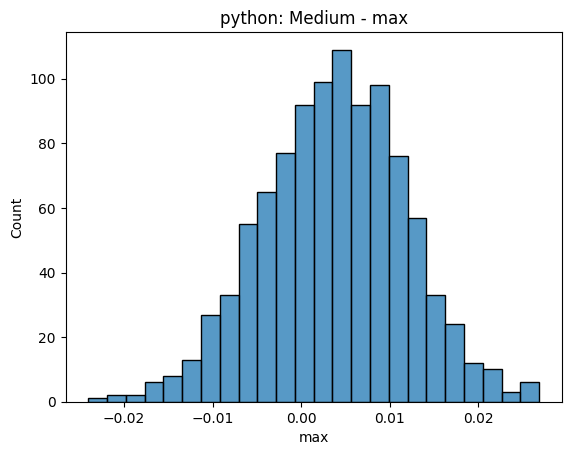

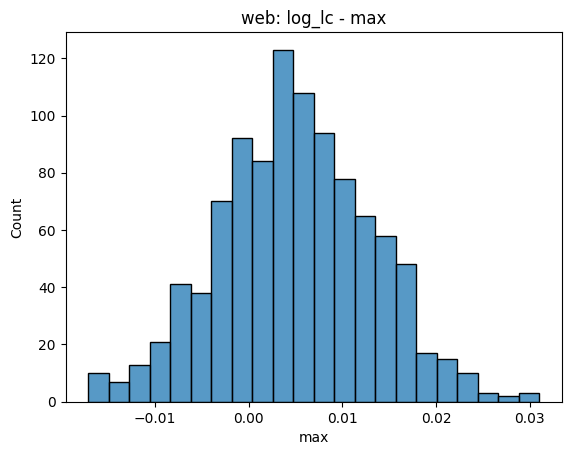

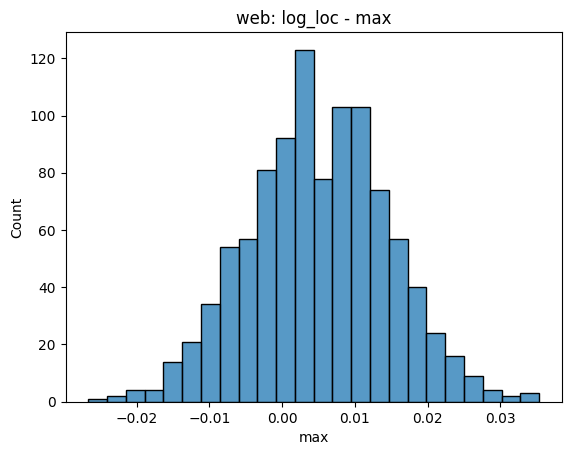

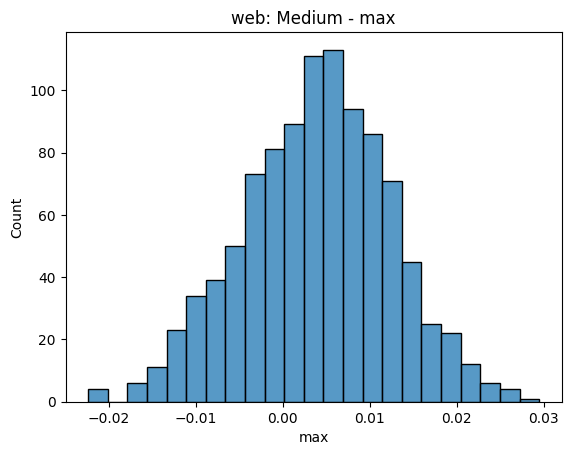

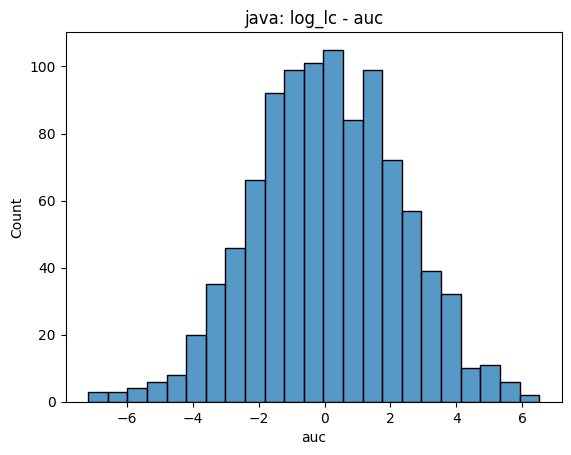

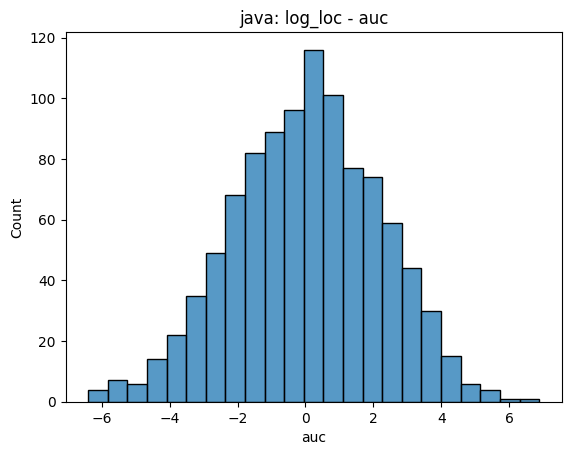

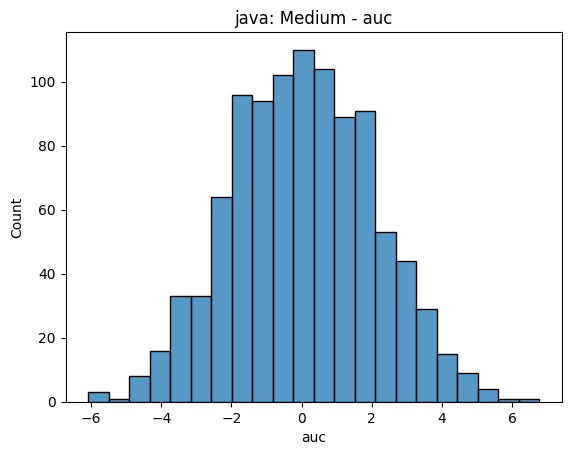

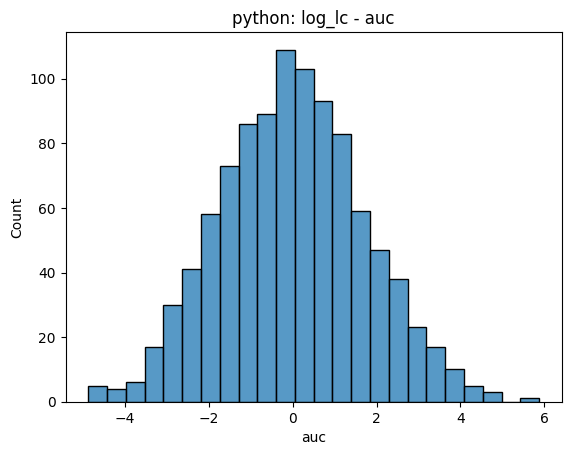

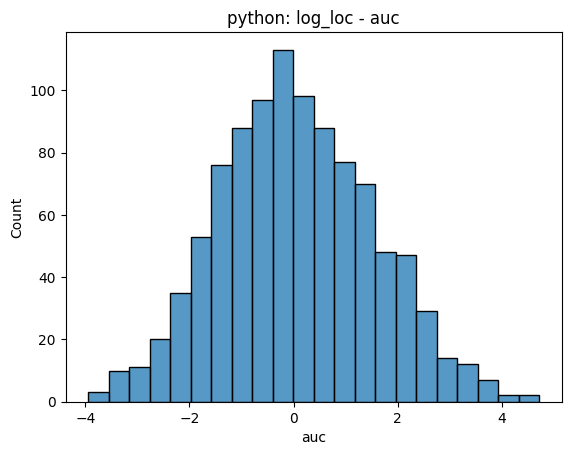

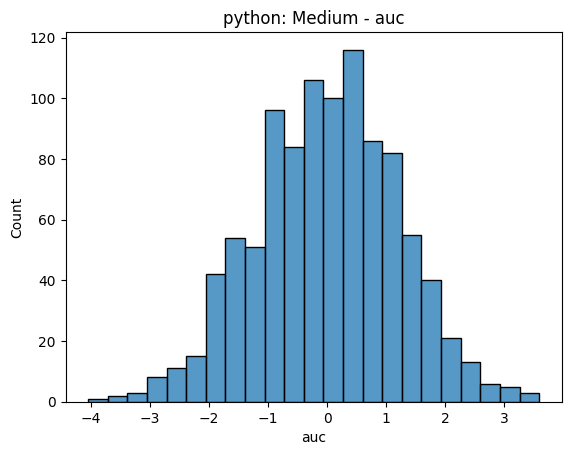

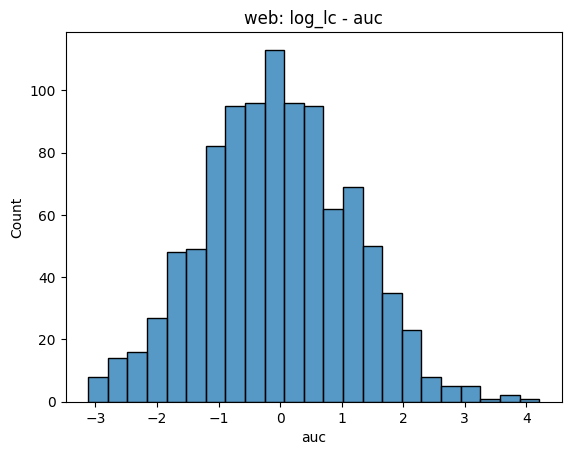

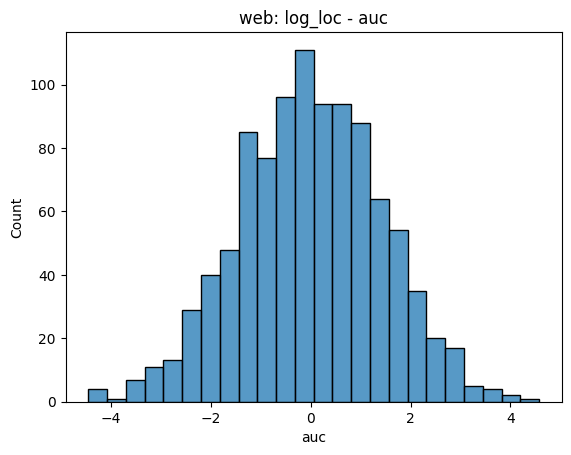

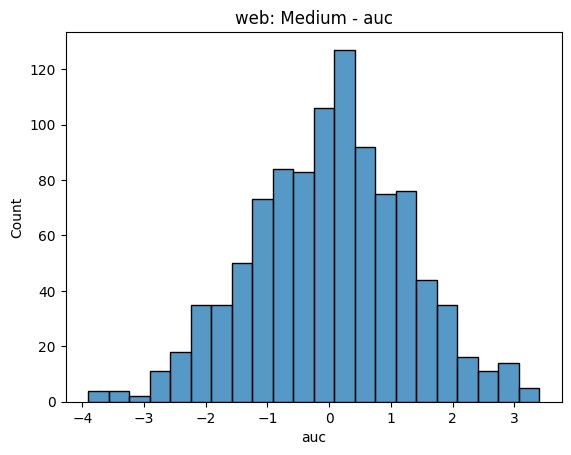

In [19]:
if compute_results:
    l_hats, m_hats, a_hats, boots = resample(tag_dfs, tag_results, outcomes, sample_function=so.permute_treatment)
    so.store_results(boots, 'tags_perm.csv')
else:
    boots = so.read_results('tags_perm.csv', resampled=True)
    l_hats, m_hats, a_hats = observed_stats(tag_results, outcomes)

resample_results(outcomes, l_hats, boots)
resample_results(outcomes, m_hats, boots, 'max')
resample_results(outcomes, a_hats, boots, 'auc')

In [20]:
dfs = dfs | tag_dfs
results = results | tag_results
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}

# placebo berfore the real event
placebo_t = ['2022-08-31', '2022-09-30', '2022-10-31']
placebo_c = ['2021-08-31', '2021-09-30', '2021-10-31']
pre_start_t = ['2022-05-30'] * 3
pre_start_c = ['2021-05-31'] * 3
shifted_t = [(pd.to_datetime(placebo) + pd.DateOffset(days=151)).strftime("%Y-%m-%d") for placebo in placebo_t]

# placebo after the real event
placebo_t.extend(['2022-12-31', '2023-01-31', '2023-02-28'])
placebo_c.extend(['2021-12-31', '2022-01-31', '2022-02-28'])
pre_start_t.extend(['2022-06-30', '2022-07-31', '2022-08-31'])
pre_start_c.extend(['2021-06-30', '2021-07-31', '2021-08-31'])
shifted_t.extend(['2023-04-29'] * 3)

#start_dates, masks = so.rolling_window_masks(q_daily, data_column='date', normalized=True, window_days=30, pre_end=placebo_t, pre_end_c=placebo_c, pre_start=shifted_t, pre_start_c=shifted_c)

placebo_results = {}
for type, outcome_list in outcomes.items():
     for outcome in outcome_list:
          
          print(f'Observed: {type} - {outcome}')
          print('Streak: ', so.effect_streak(results[(type, outcome)]))
          print('Max: ', so.max_rolling_mean(results[(type, outcome)]))
          print('AUC: ', so.auc(results[(type, outcome)]) / len(results[(type, outcome)]))
          
          for pt, pc, pst, psc, st in zip(placebo_t, placebo_c, pre_start_t, pre_start_c, shifted_t):
               start_dates, masks = so.rolling_window_masks(dfs[type], data_column='date', normalized=True, window_days=30, pre_start=pst, pre_start_c=psc, pre_end=pt, pre_end_c=pc, end=st)
               daily = dfs[type].copy()
               daily['P'] = (((daily['date'] >= pd.to_datetime(pt)) & (daily['date'] <= pd.to_datetime('2023-05-29'))) | 
                              ((daily['date'] >= pd.to_datetime(pc)) & (daily['date'] <= pd.to_datetime('2022-05-30')))).astype(int)
               
               X, y = so.did_design_matrix(f'{outcome}_bar', daily)
               res = so.did_wls(daily, X, y, masks, start_dates, outcome)
               placebo_results[(type, outcome, pt)] = res

               print(f'Placebo: {type} - {outcome} - {pt}')
               print('Streak: ', so.effect_streak(res))
               print('Max: ', so.max_rolling_mean(res))
               print('AUC: ', so.auc(res) / len(res))

Observed: questions - log_lc
Streak:  1.0
Max:  0.07508304697799567
AUC:  0.06282949738442181


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Placebo: questions - log_lc - 2022-08-31
Streak:  0.6973684210526315
Max:  0.0679697022194537
AUC:  0.041812117894568845
Placebo: questions - log_lc - 2022-09-30
Streak:  0.8881578947368421
Max:  0.07788134590177417
AUC:  0.05324800096985047


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Placebo: questions - log_lc - 2022-10-31
Streak:  1.0
Max:  0.08018119573472739
AUC:  0.06484176191878314
Placebo: questions - log_lc - 2022-12-31
Streak:  1.0
Max:  0.06502458607001925
AUC:  0.05499996337134368
Placebo: questions - log_lc - 2023-01-31
Streak:  1.0
Max:  0.05460425364408761
AUC:  0.046451492627927
Placebo: questions - log_lc - 2023-02-28
Streak:  1.0
Max:  0.037644539674104124
AUC:  0.03210612621263674
Observed: answers - log_lc
Streak:  1.0
Max:  0.04052282424492404
AUC:  0.02897367333751148
Placebo: answers - log_lc - 2022-08-31
Streak:  0.40789473684210525
Max:  0.020479287561133572
AUC:  0.0032475369804295736


...

Placebo: web - log_lc - 2022-10-31
Streak:  1.0
Max:  0.10321812525875378
AUC:  0.05907128679477047
Placebo: web - log_lc - 2022-12-31
Streak:  1.0
Max:  0.10836990190414261
AUC:  0.07728055969902775
Placebo: web - log_lc - 2023-01-31
Streak:  1.0
Max:  0.10293957286375724
AUC:  0.08388684174120524
Placebo: web - log_lc - 2023-02-28
Streak:  1.0
Max:  0.0948709225276521
AUC:  0.08657417512577716
Observed: web - log_loc
Streak:  0.8278145695364238
Max:  0.08830720095761577
AUC:  0.05048461991209205


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Placebo: web - log_loc - 2022-08-31
Streak:  0.23026315789473684
Max:  0.03575372201647916
AUC:  0.013119752372714634
Placebo: web - log_loc - 2022-09-30
Streak:  0.4276315789473684
Max:  0.049347158976035706
AUC:  0.023882315230737576
Placebo: web - log_loc - 2022-10-31
Streak:  0.631578947368421
Max:  0.0806566194129926
AUC:  0.03801818488255095
Placebo: web - log_loc - 2022-12-31
Streak:  1.0
Max:  0.08520265699835172
AUC:  0.058273256597248774
Placebo: web - log_loc - 2023-01-31
Streak:  1.0
Max:  0.08184041603828003
AUC:  0.06466724264206943
Placebo: web - log_loc - 2023-02-28
Streak:  1.0
Max:  0.07752225037296873
AUC:  0.07141400317235698
Observed: web - Medium
Streak:  0.48344370860927155
Max:  0.06272073135501272
AUC:  0.03596461045614023
Placebo: web - Medium - 2022-08-31
Streak:  0.3881578947368421
Max:  0.03876432799862341
AUC:  0.015067421954448835
Placebo: web - Medium - 2022-09-30
Streak:  0.3881578947368421
Max:  0.037965552381690484
AUC:  0.019015571113825614


c:\Users\denis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


Placebo: web - Medium - 2022-10-31
Streak:  0.3881578947368421
Max:  0.04202242784571486
AUC:  0.025818368504953747
Placebo: web - Medium - 2022-12-31
Streak:  0.6
Max:  0.055604256719034004
AUC:  0.029997485027998736
Placebo: web - Medium - 2023-01-31
Streak:  0.797752808988764
Max:  0.053248022761193226
AUC:  0.03275716269183867
Placebo: web - Medium - 2023-02-28
Streak:  1.0
Max:  0.05201477414323557
AUC:  0.04075947327173111


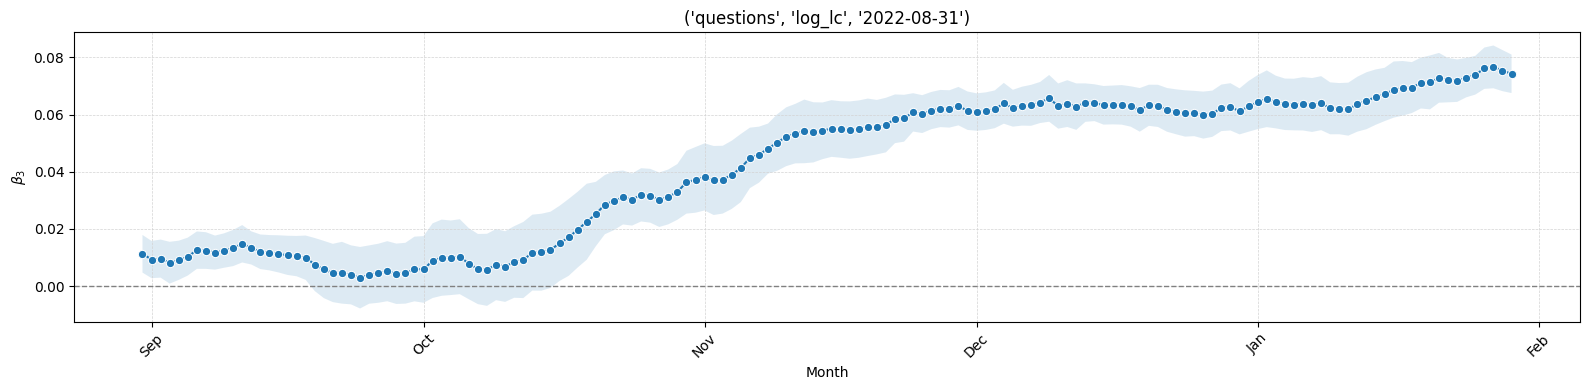

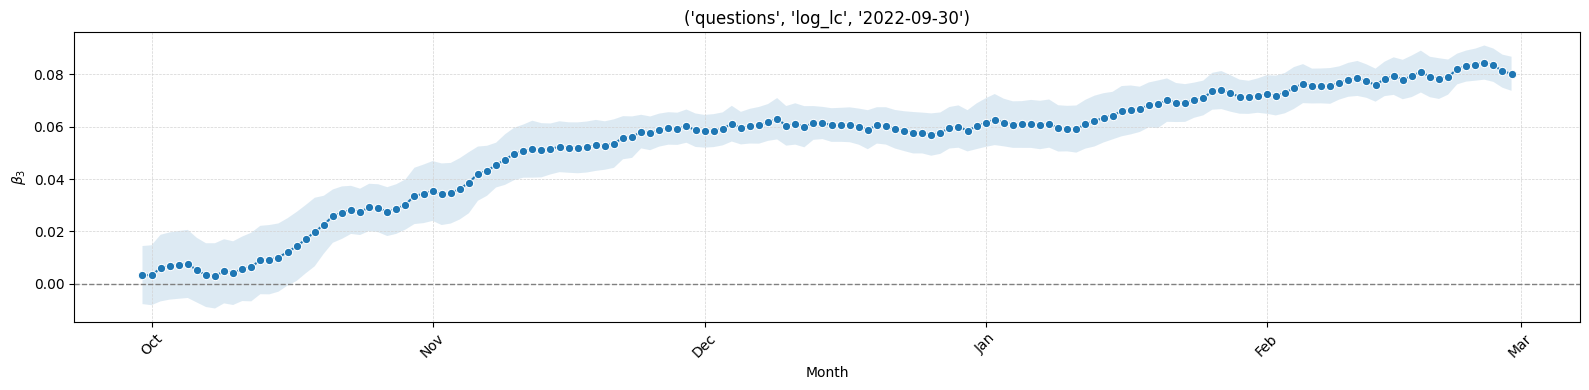

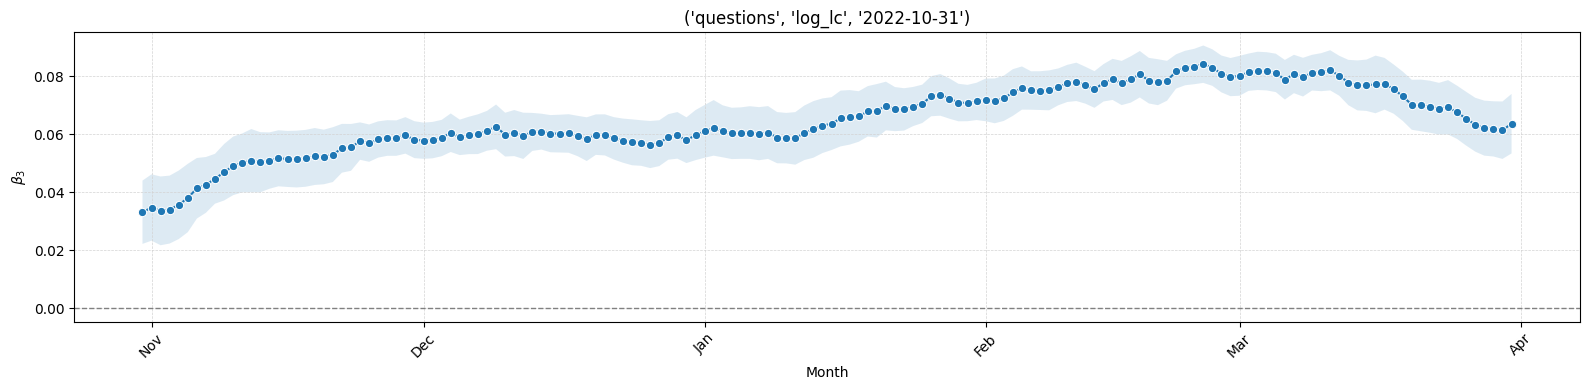

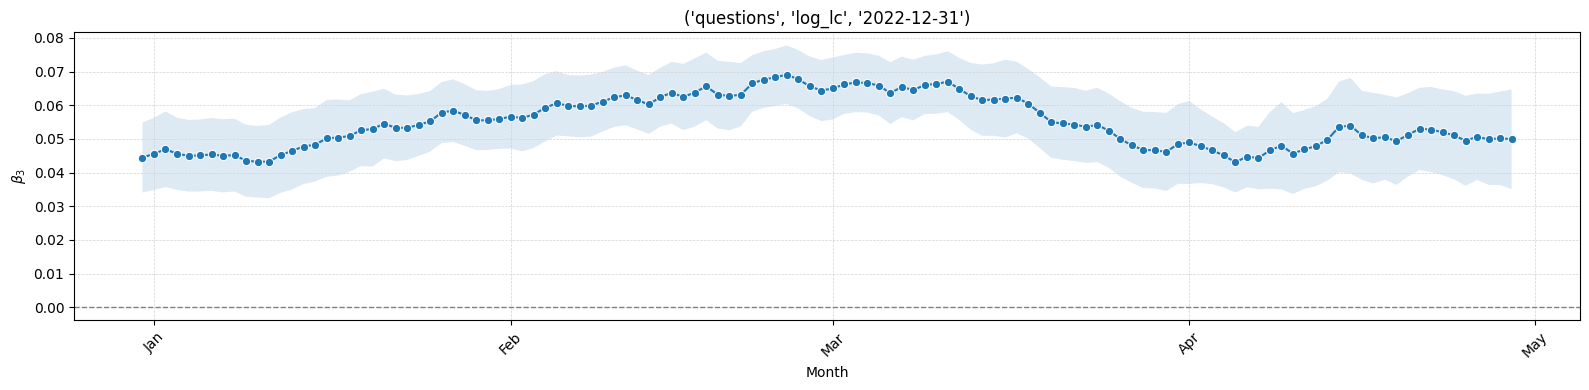

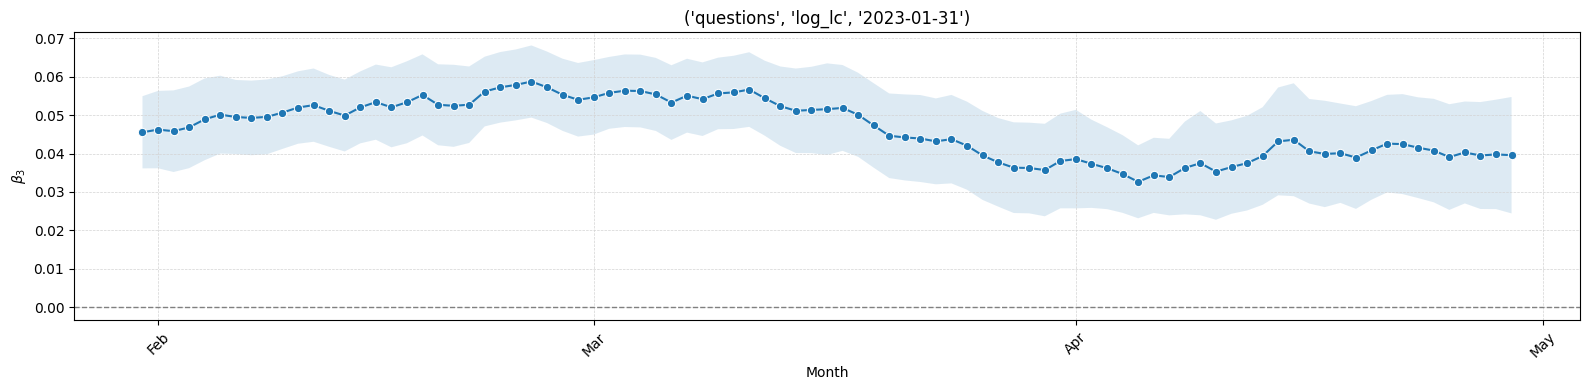

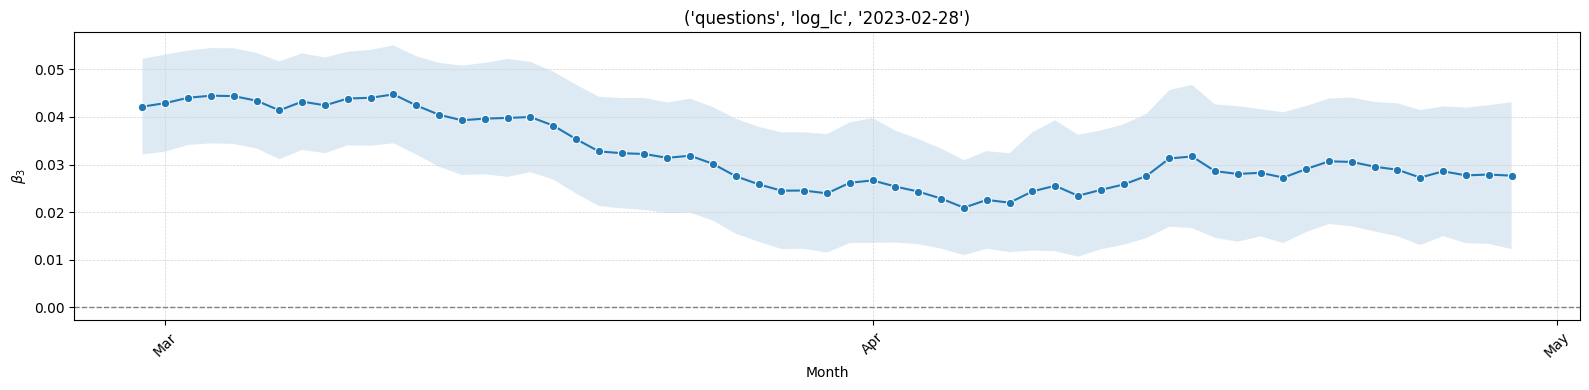

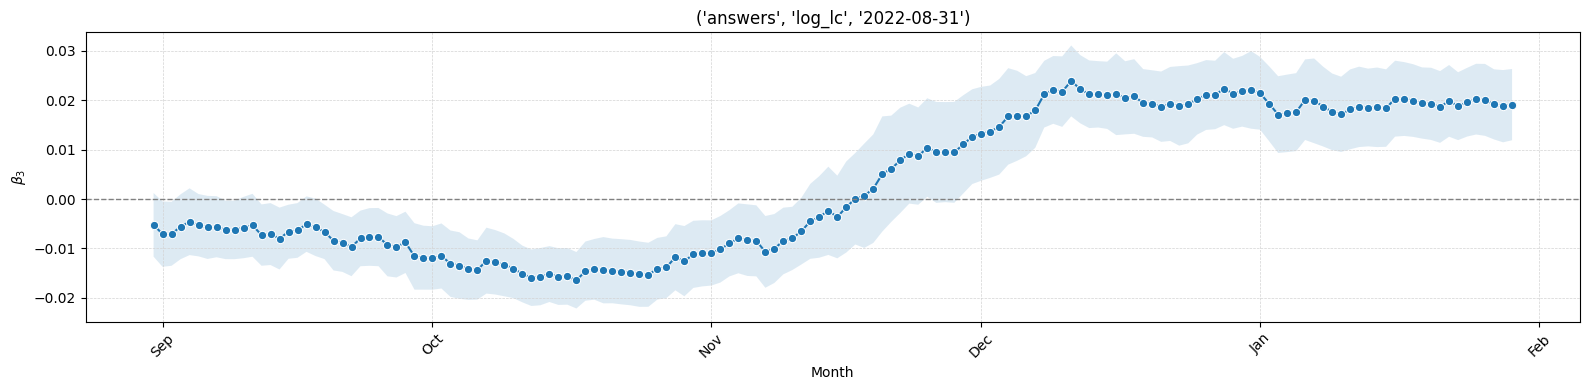

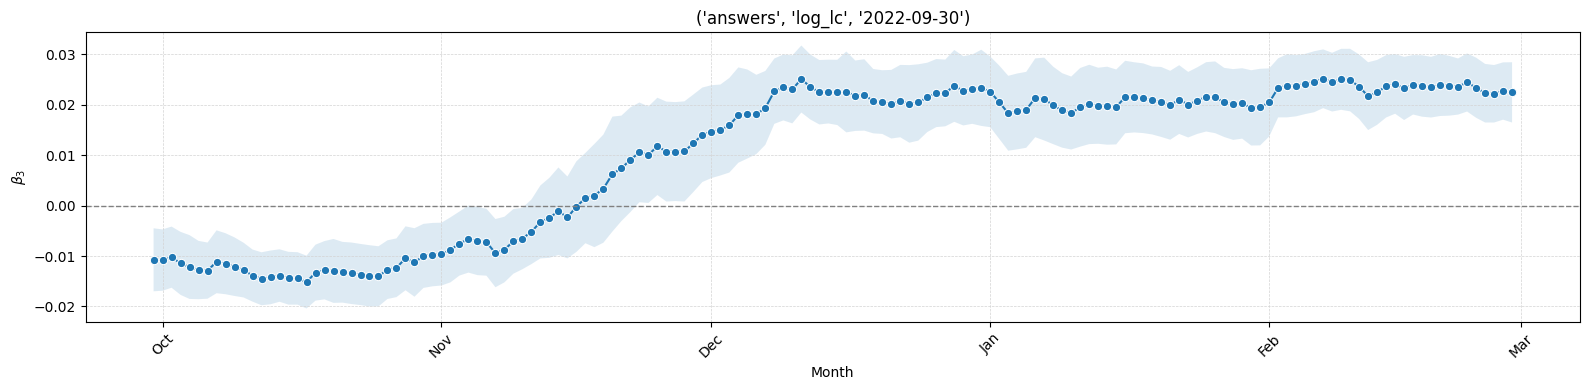

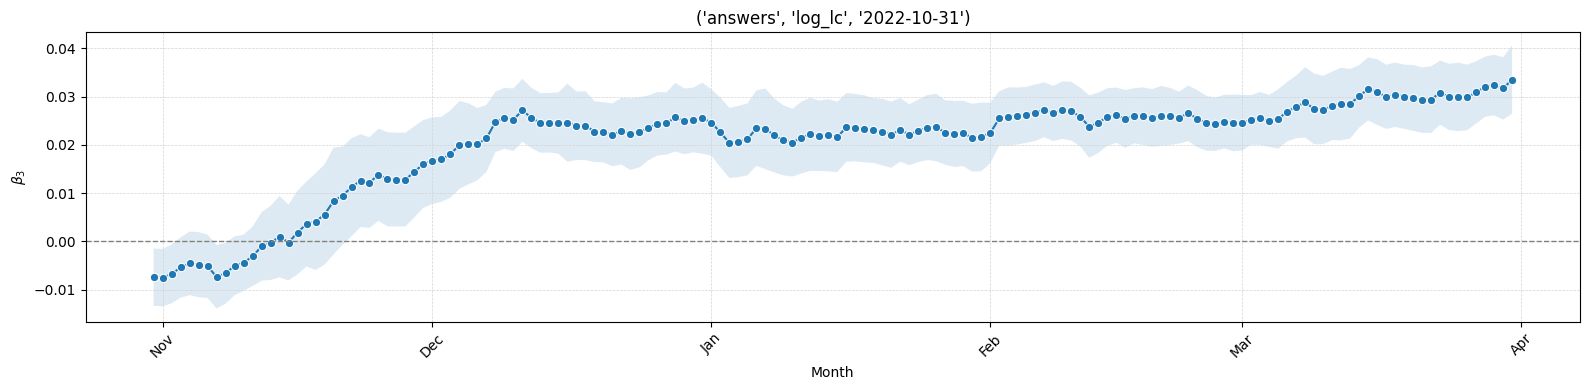

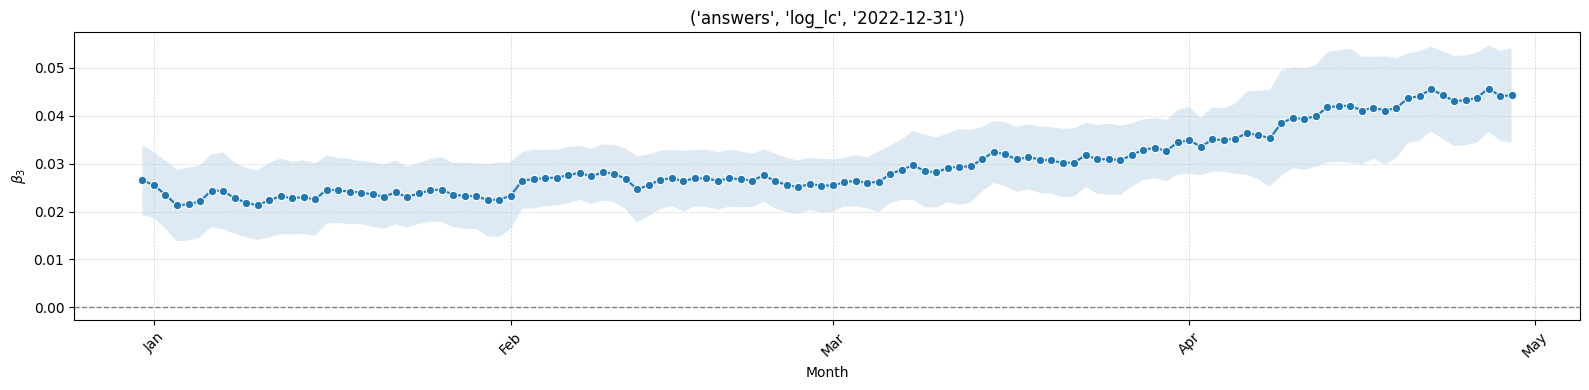

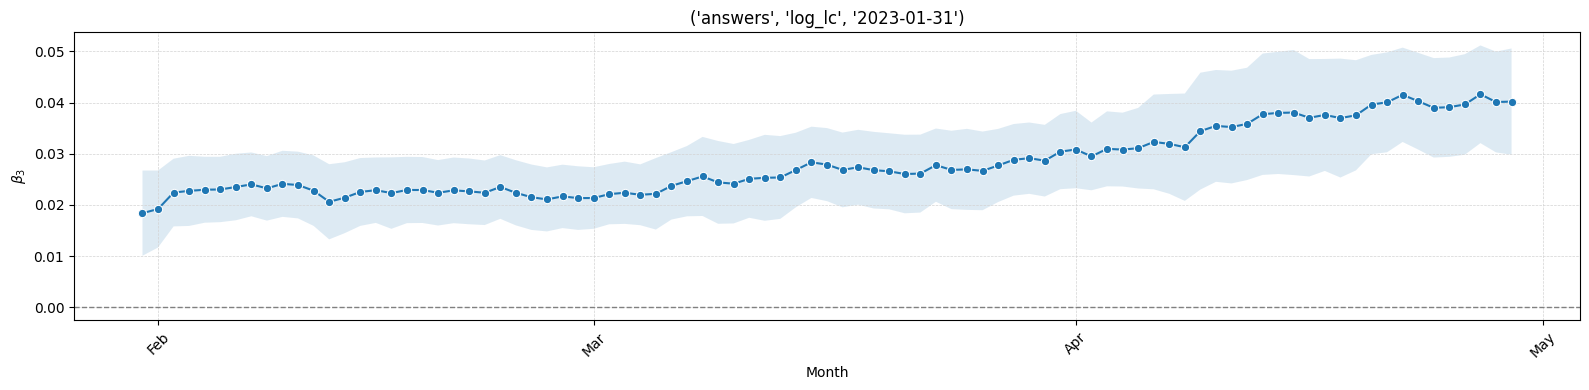

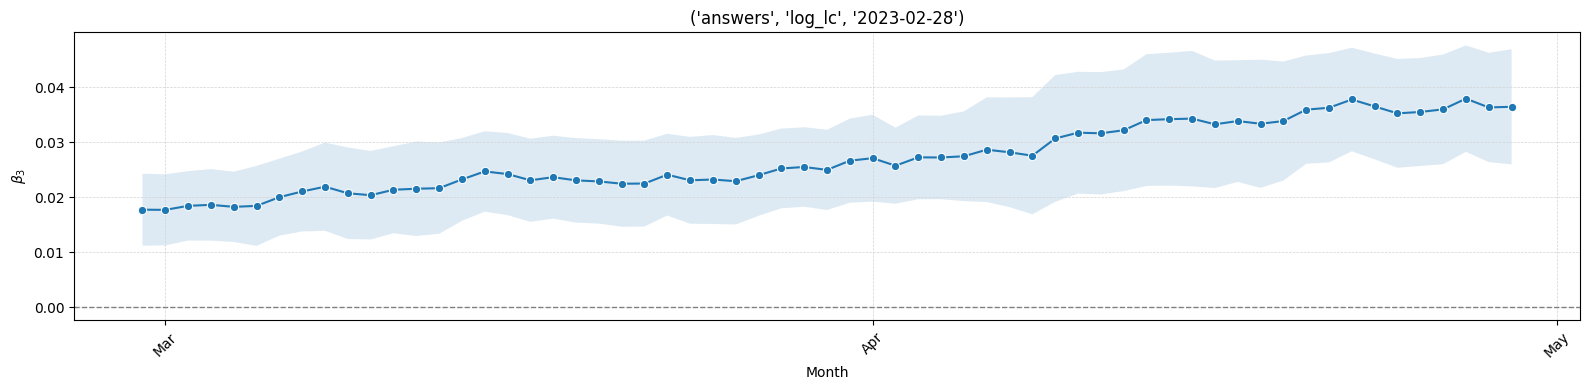

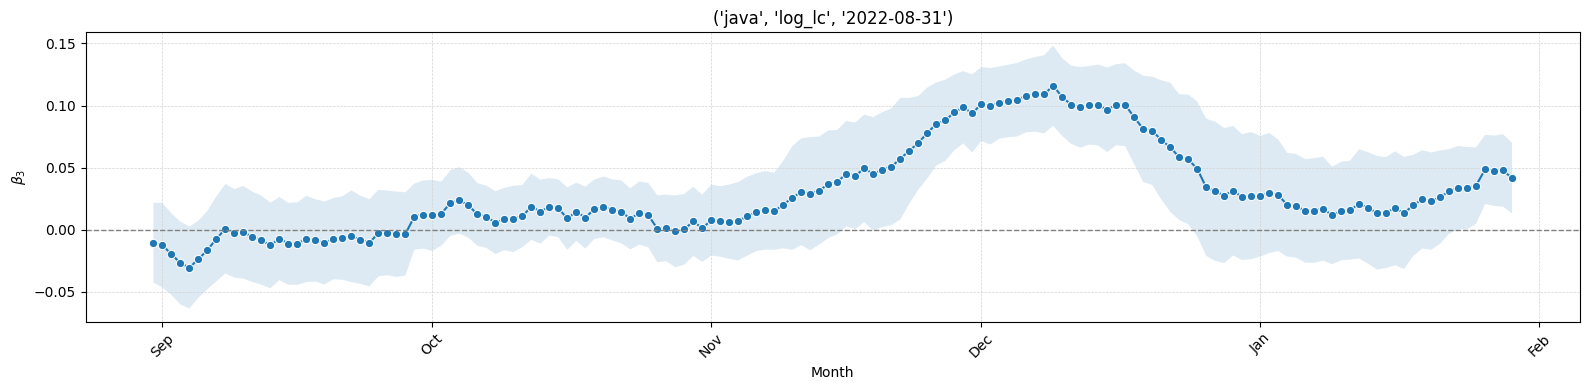

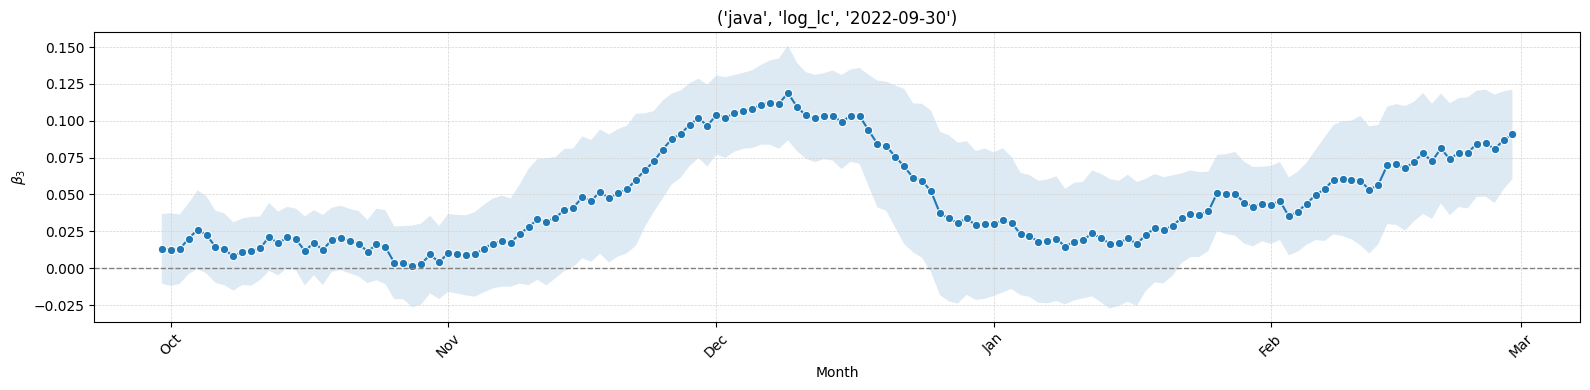

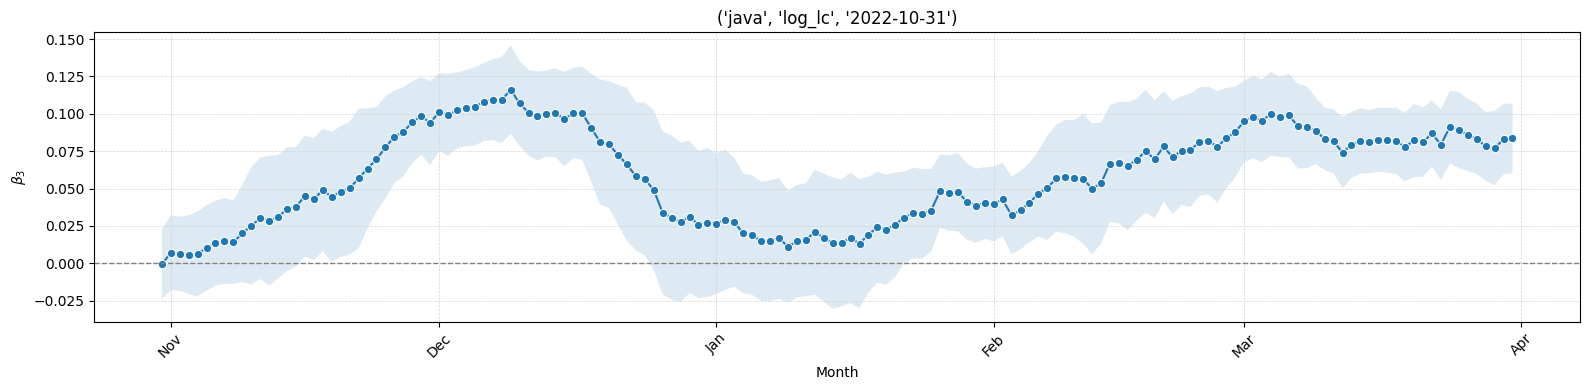

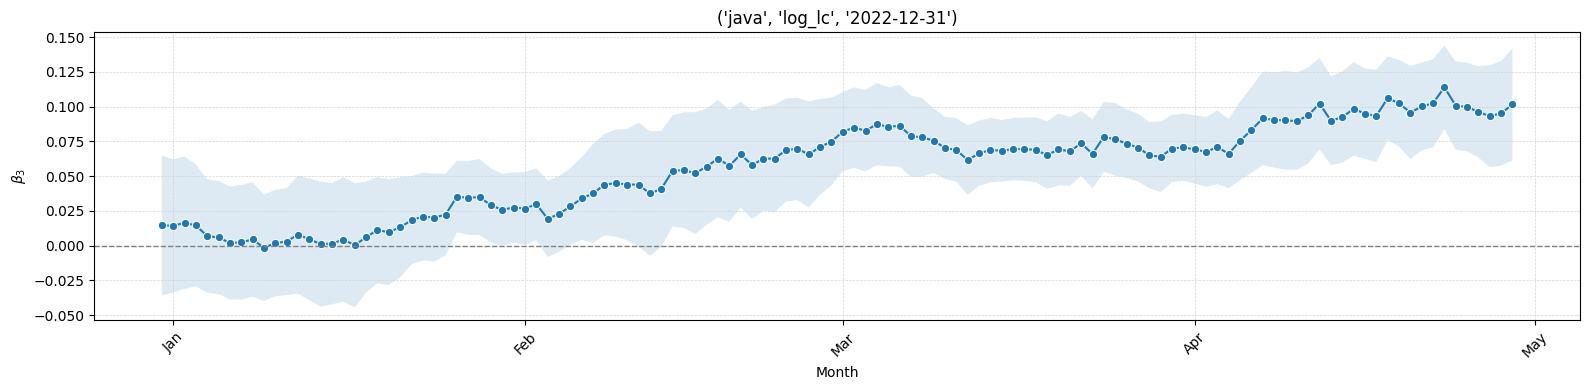

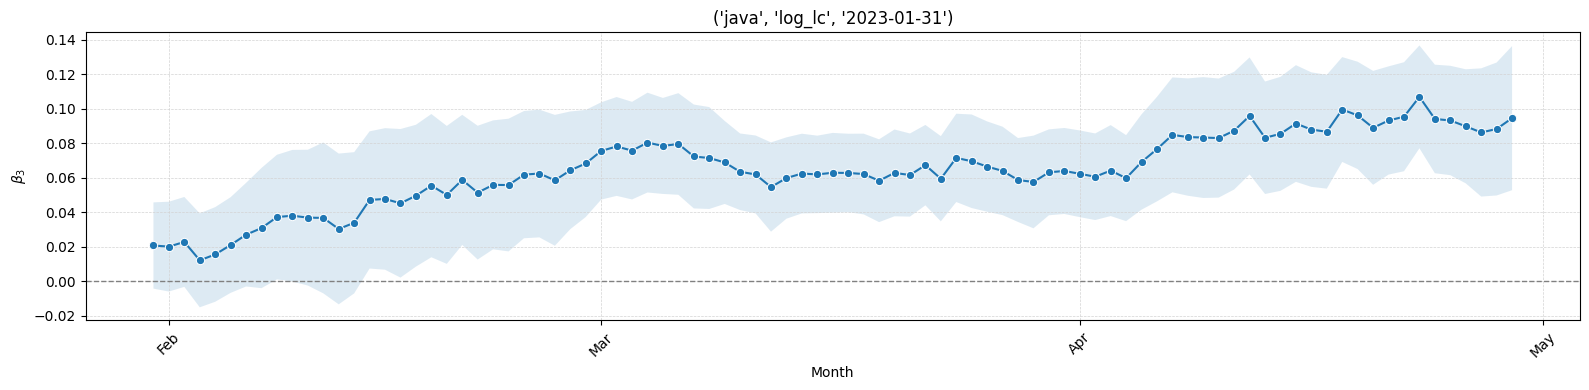

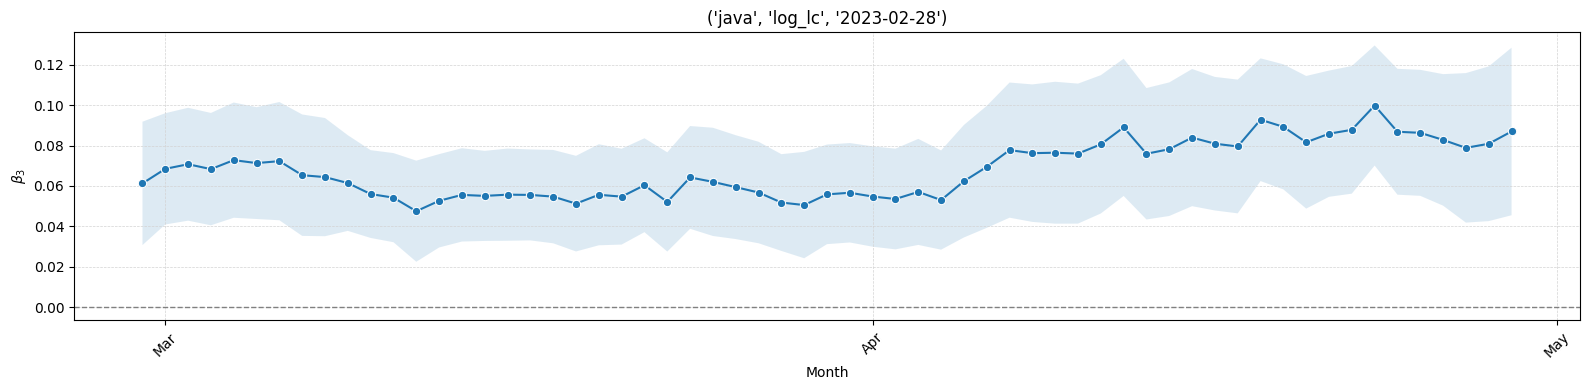

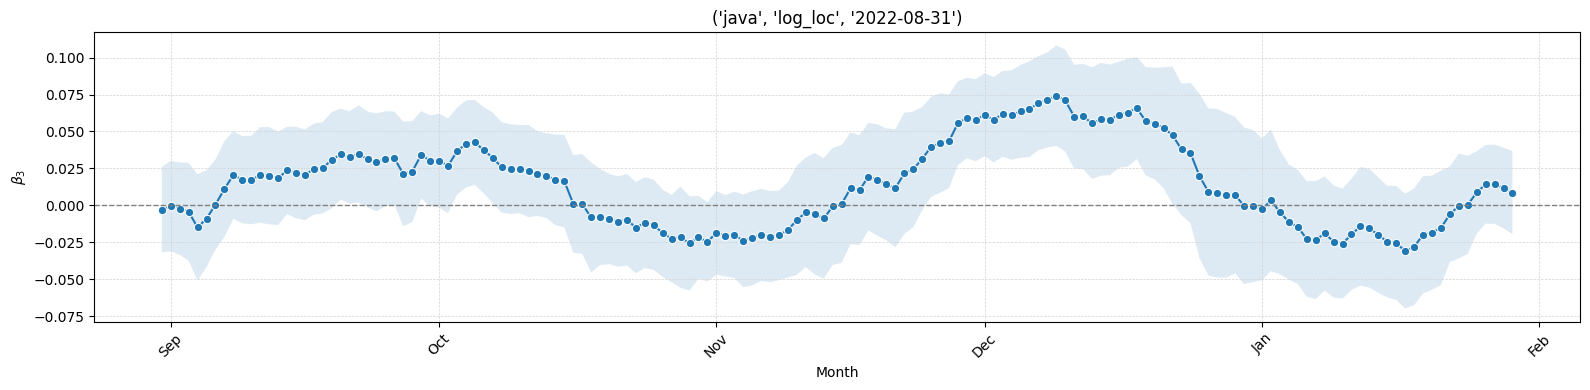

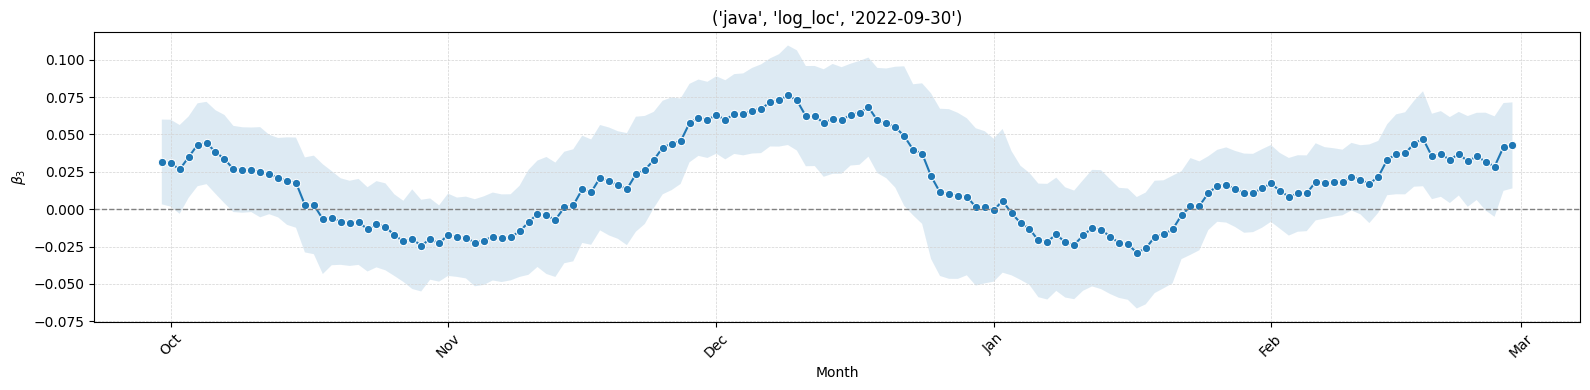

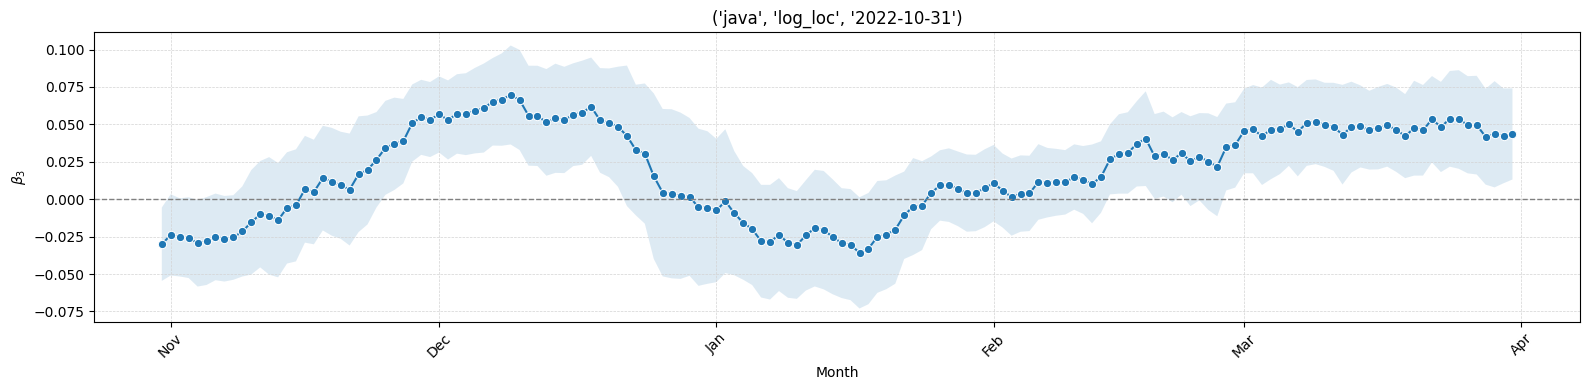

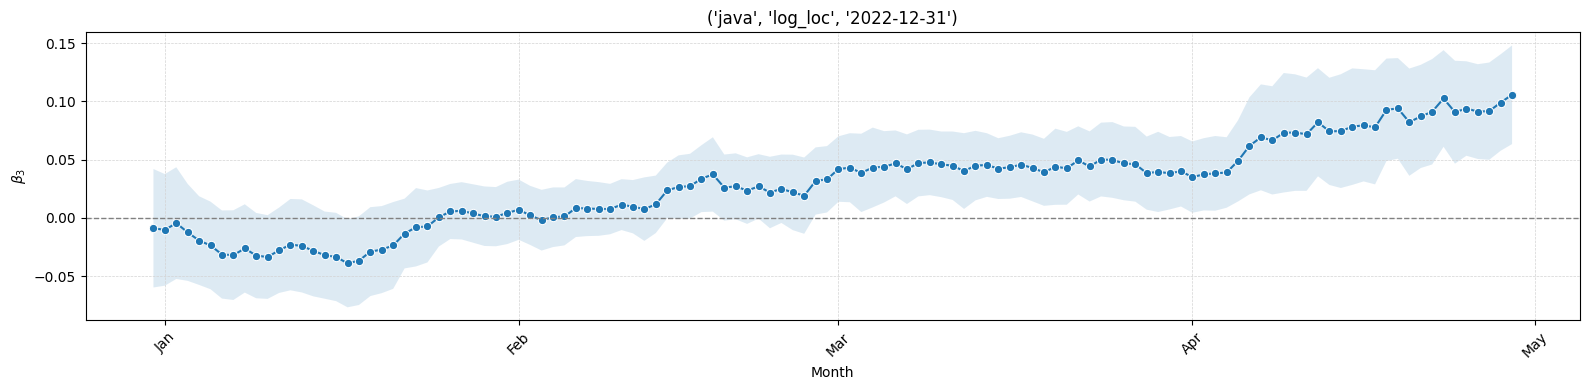

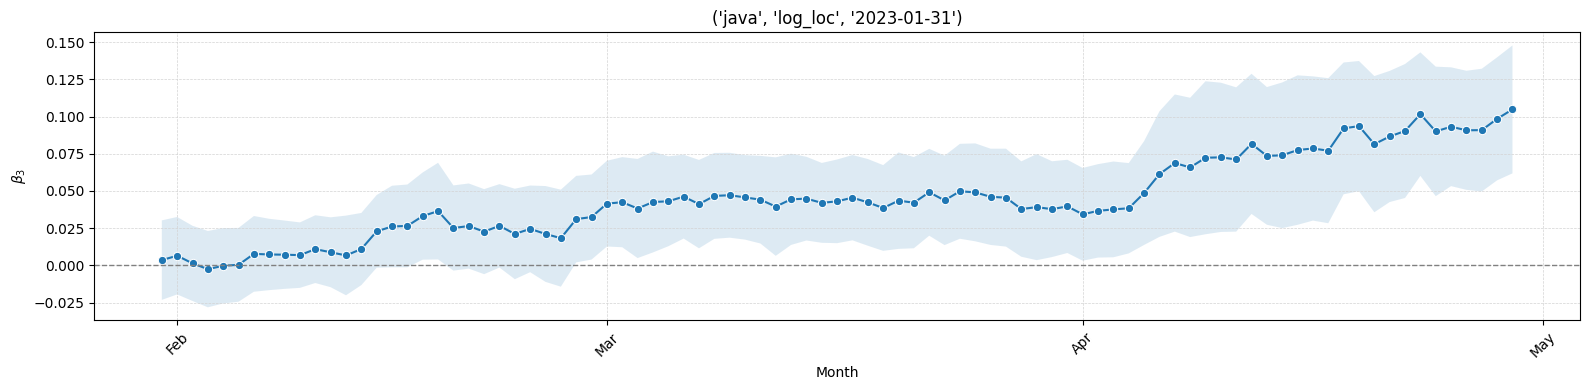

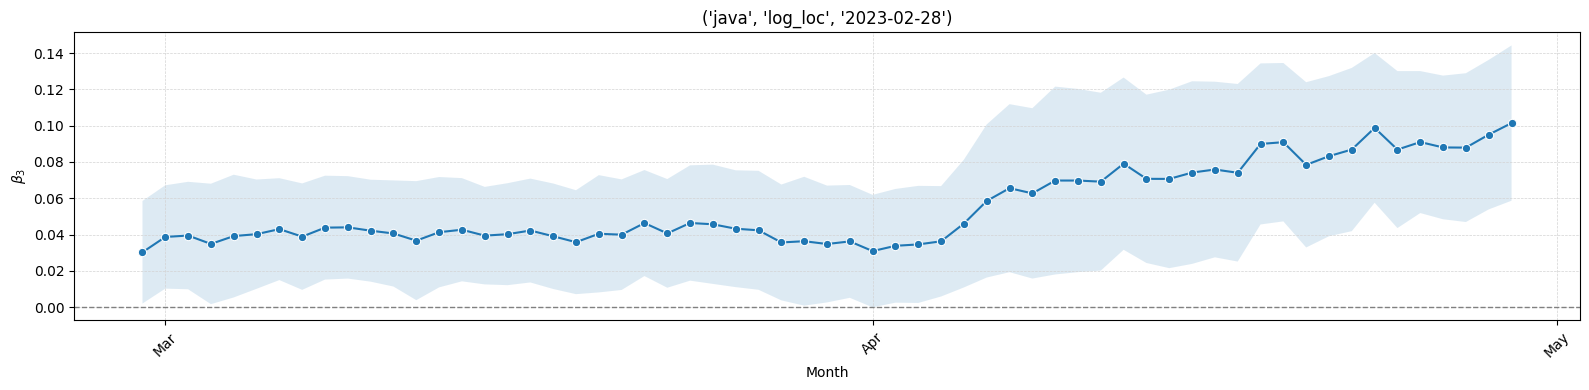

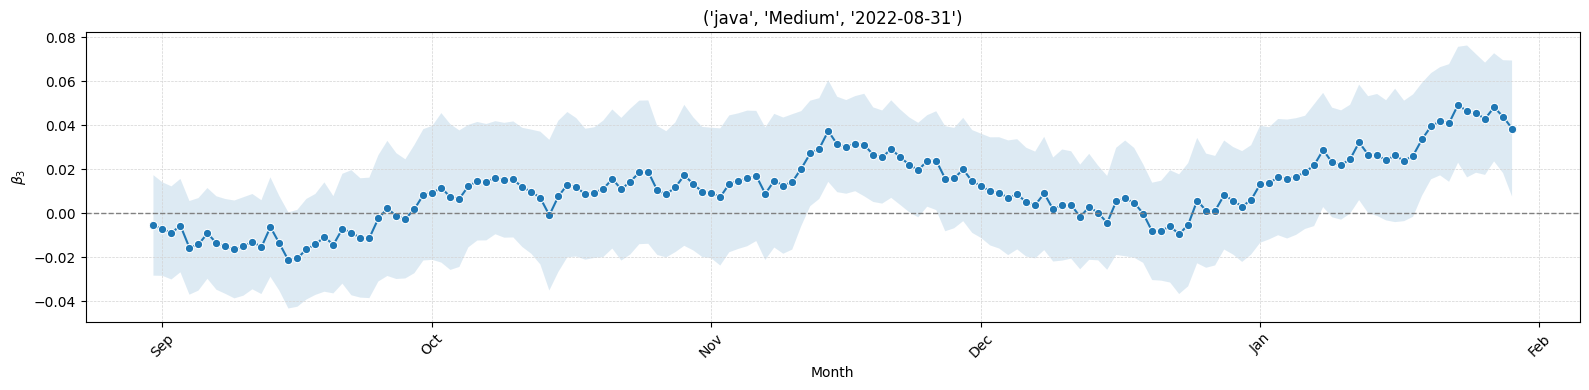

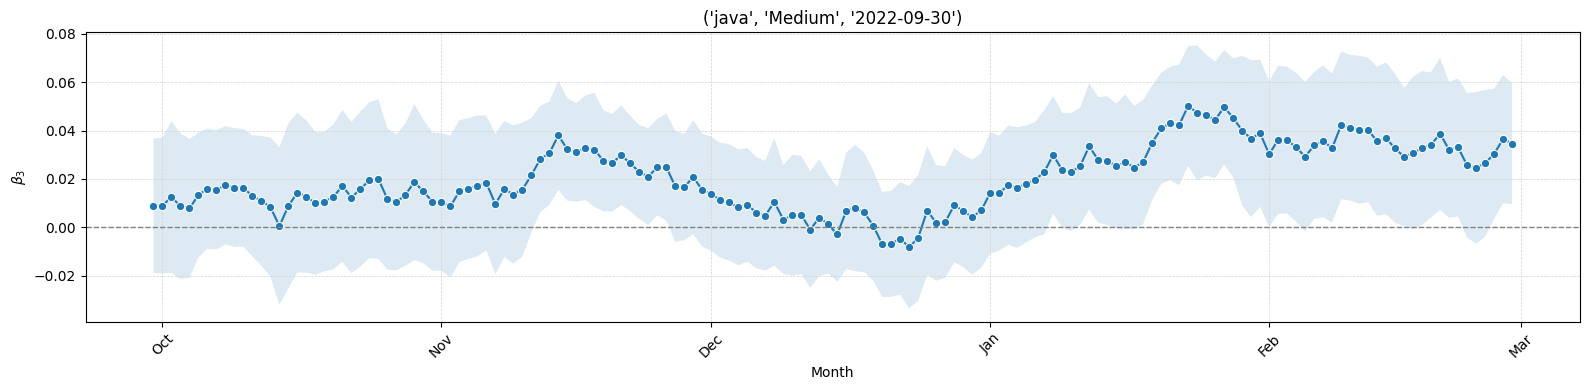

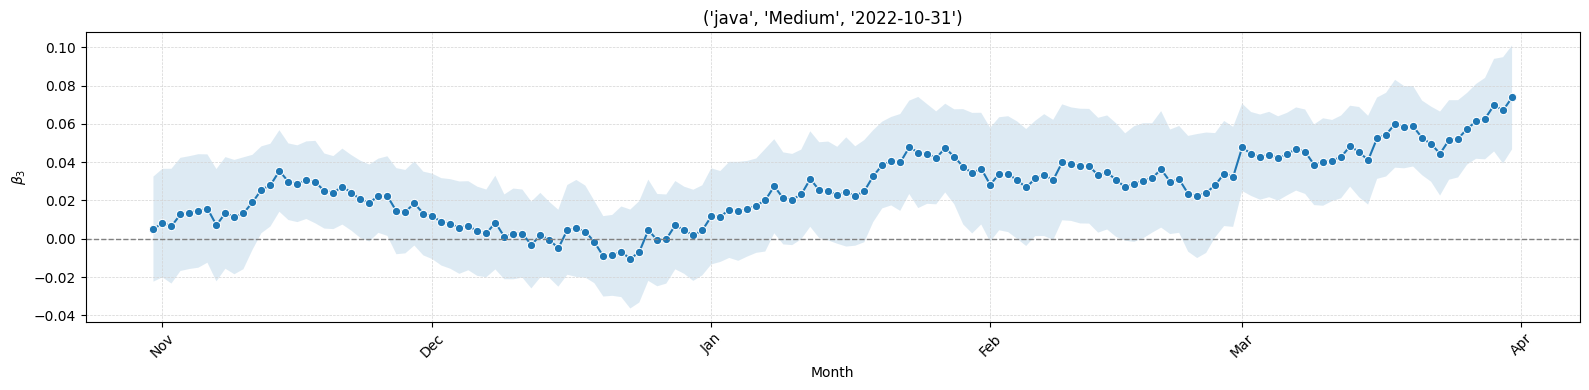

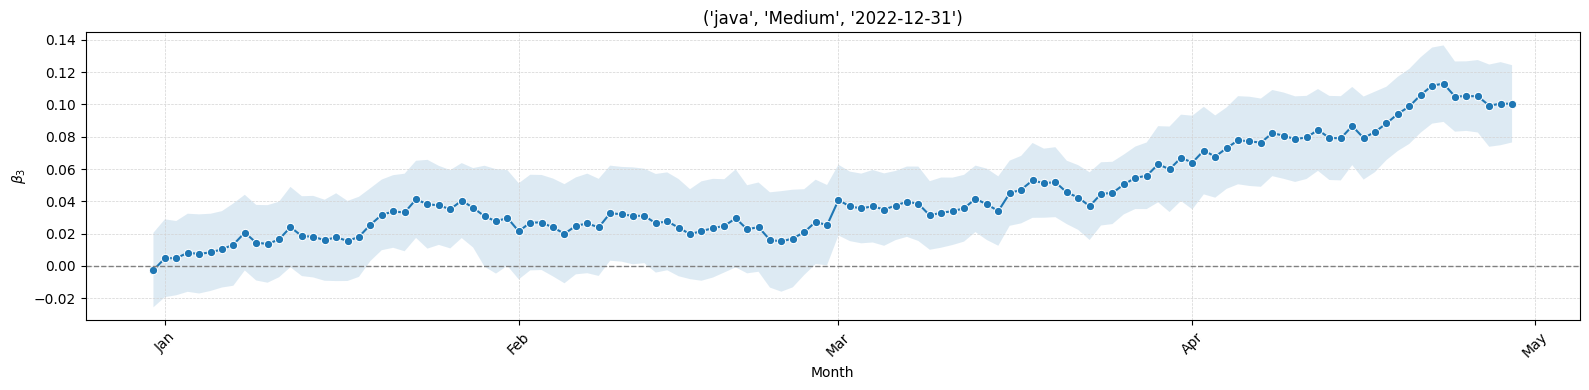

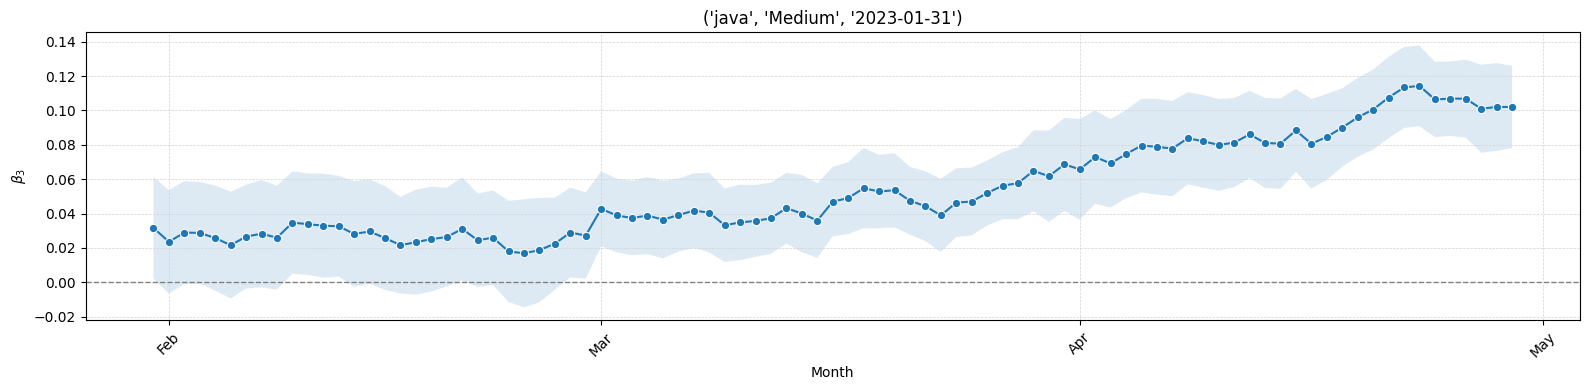

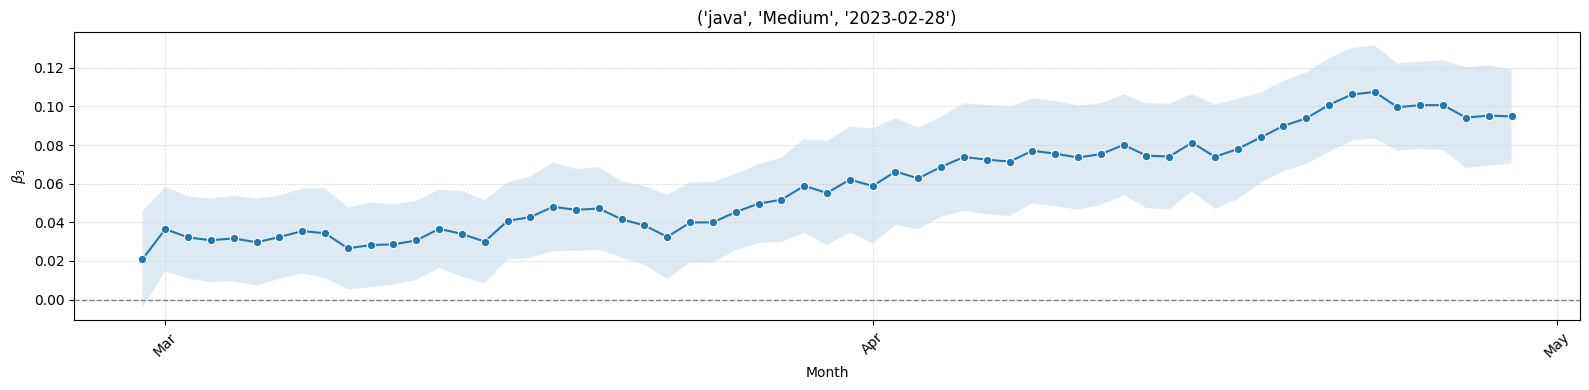

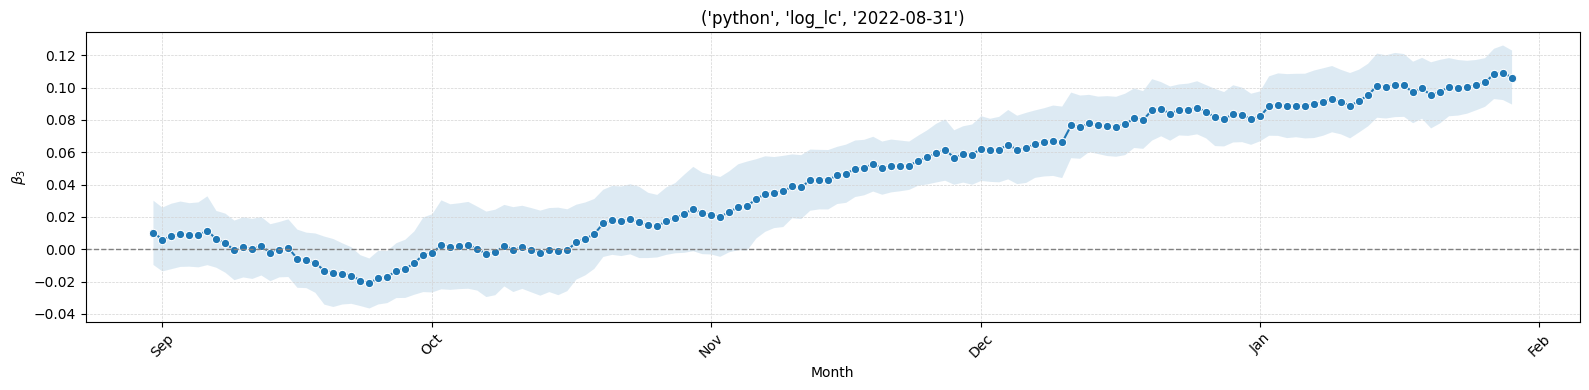

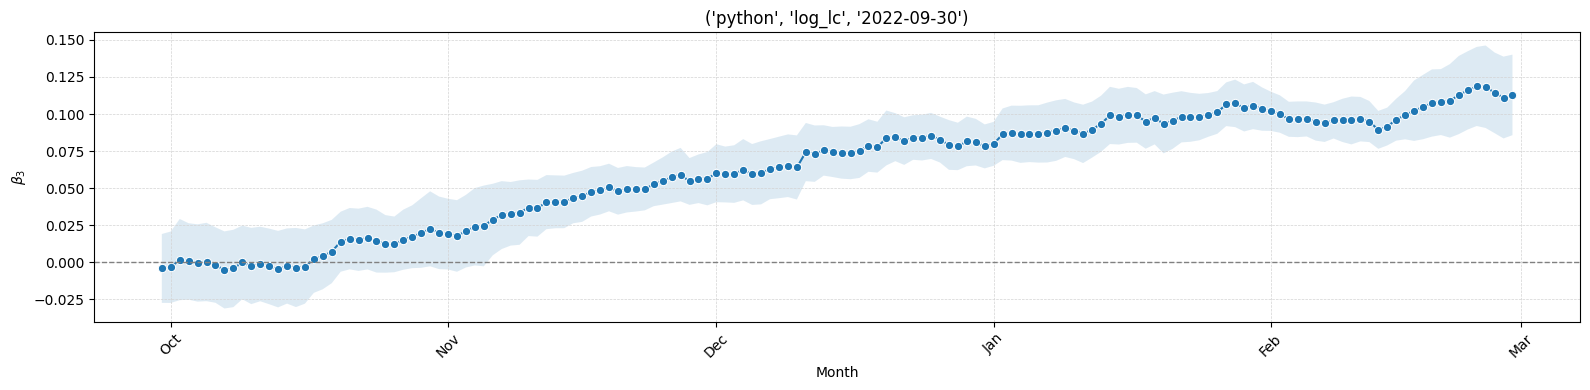

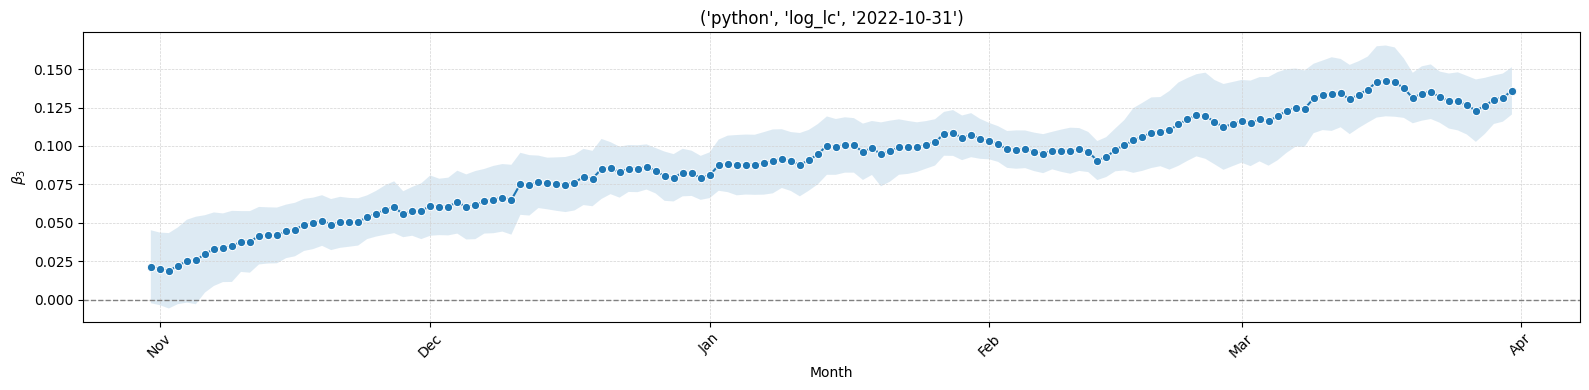

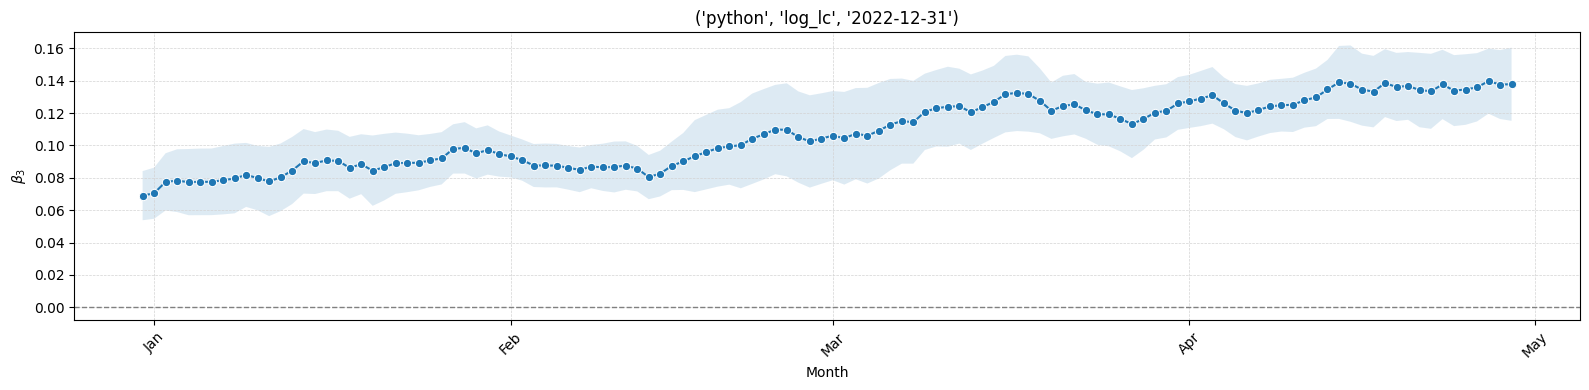

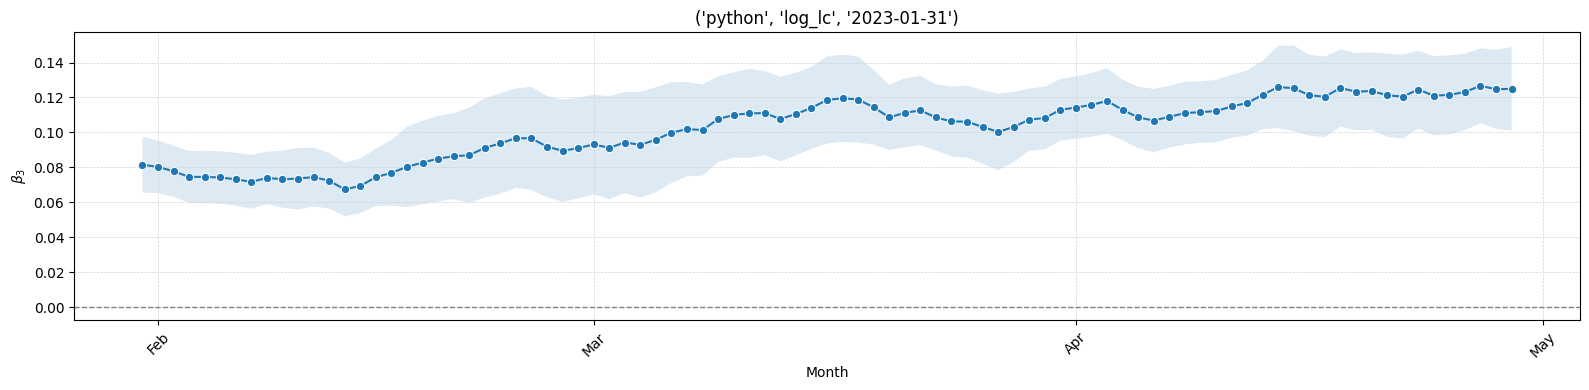

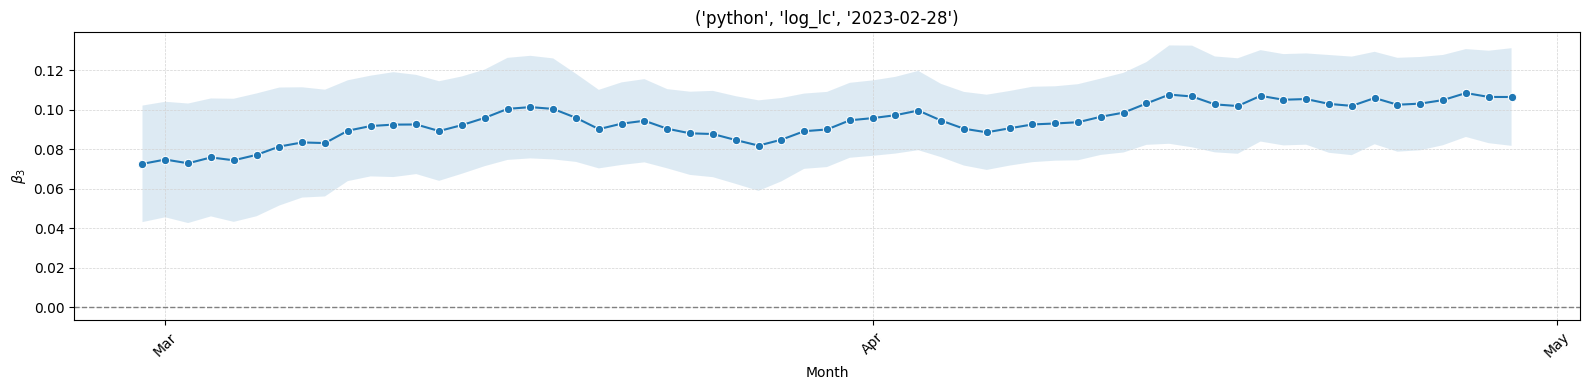

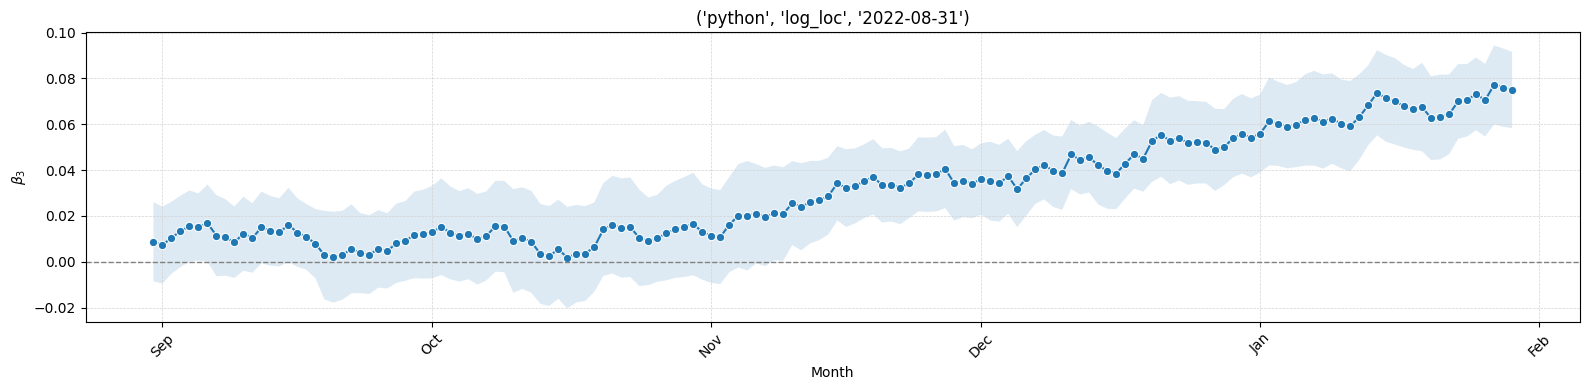

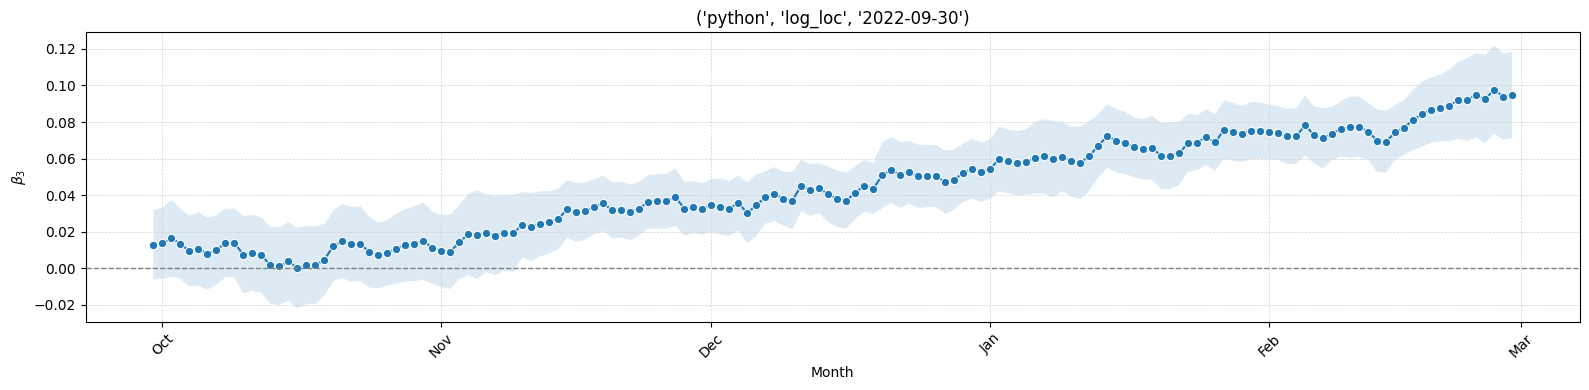

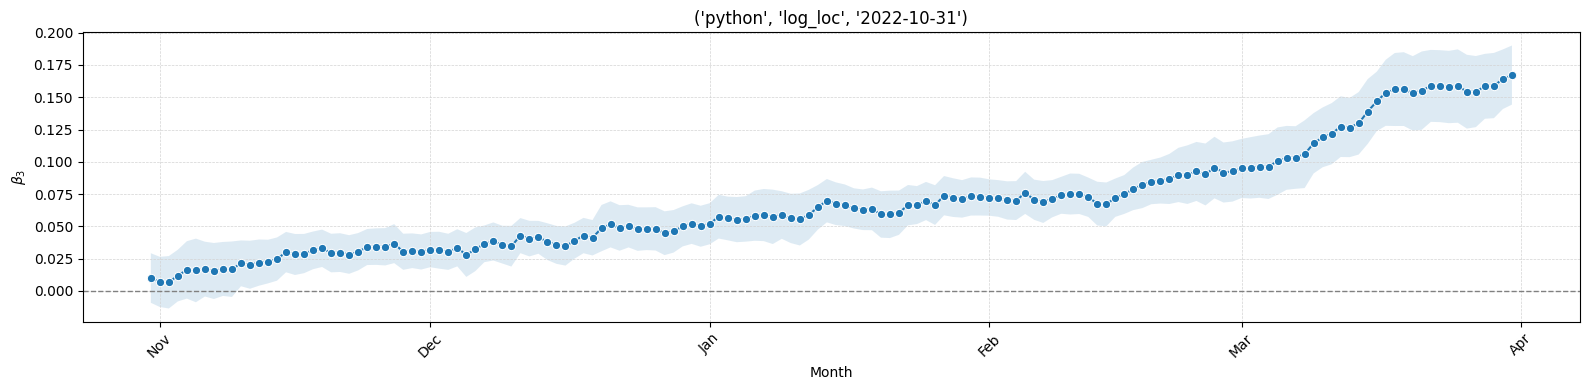

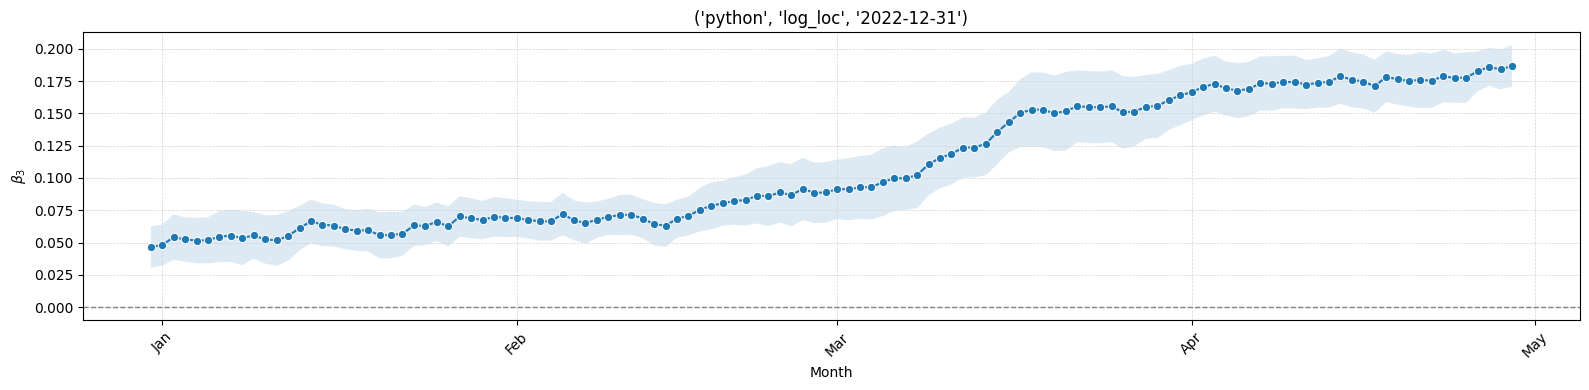

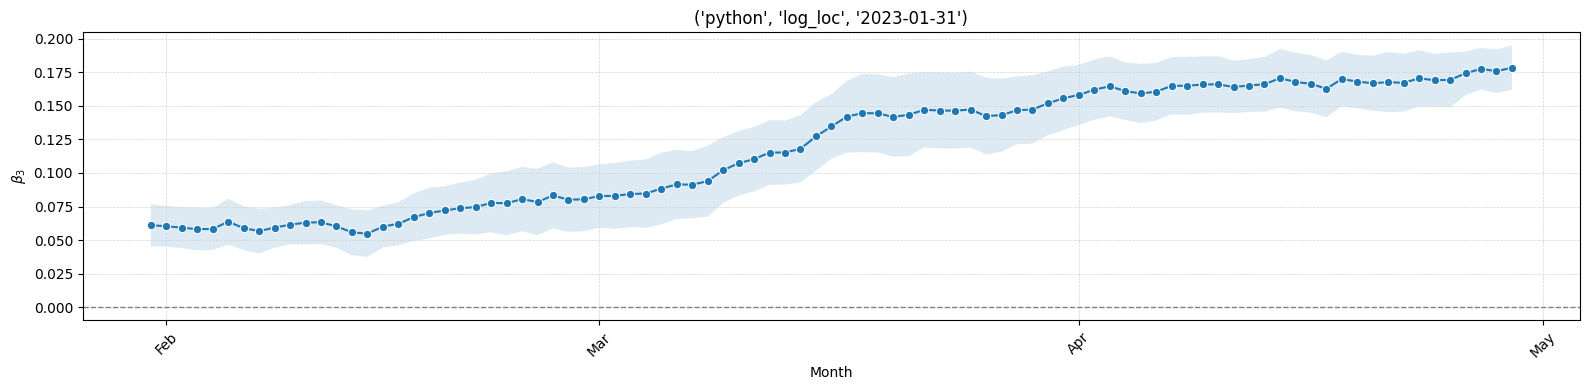

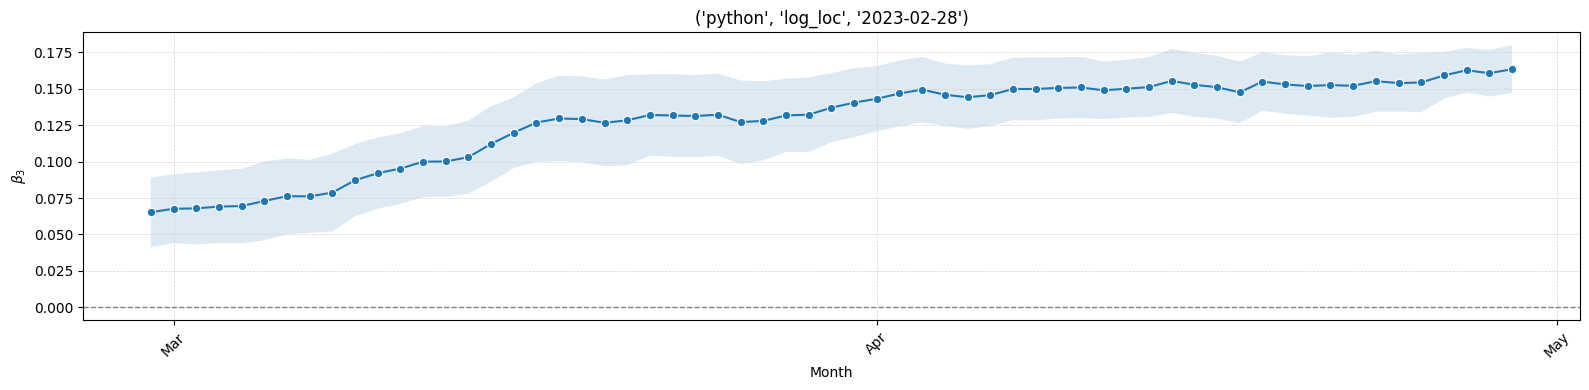

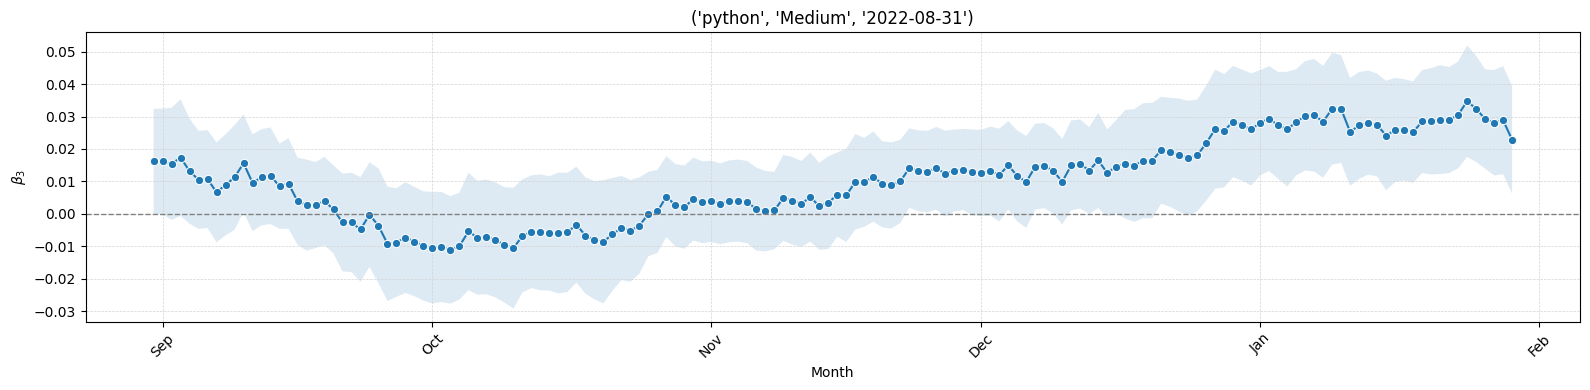

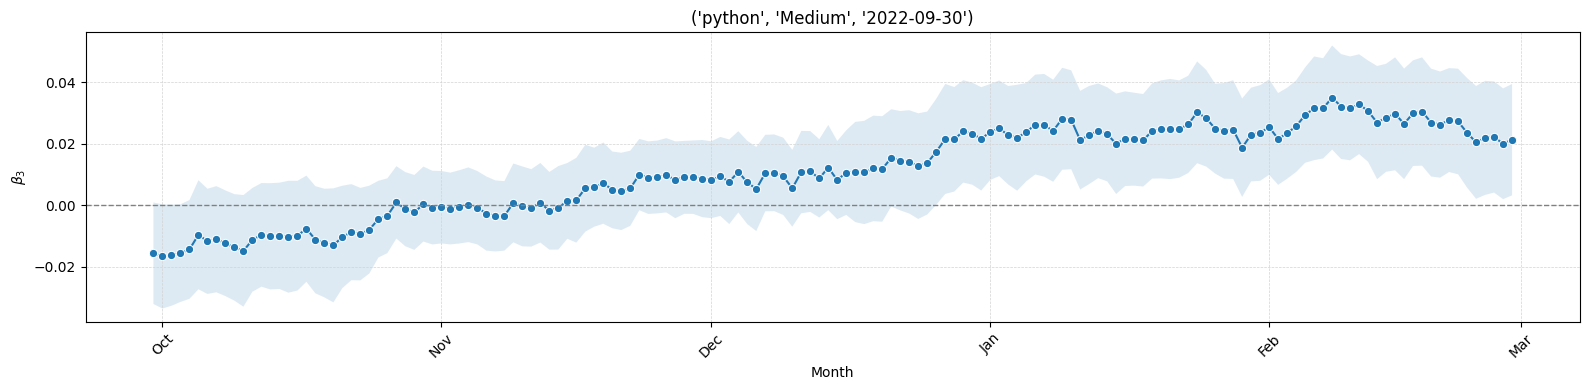

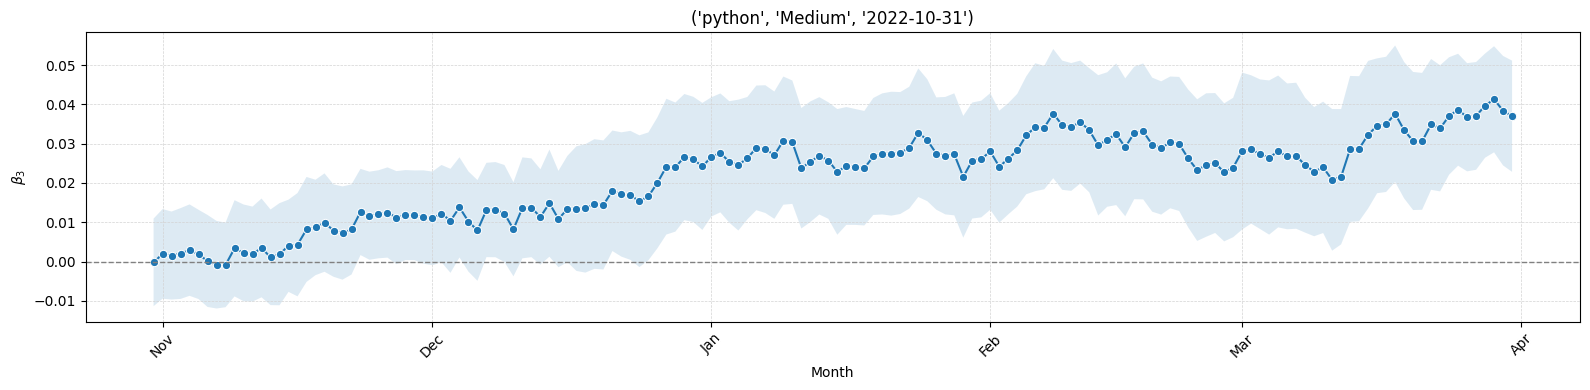

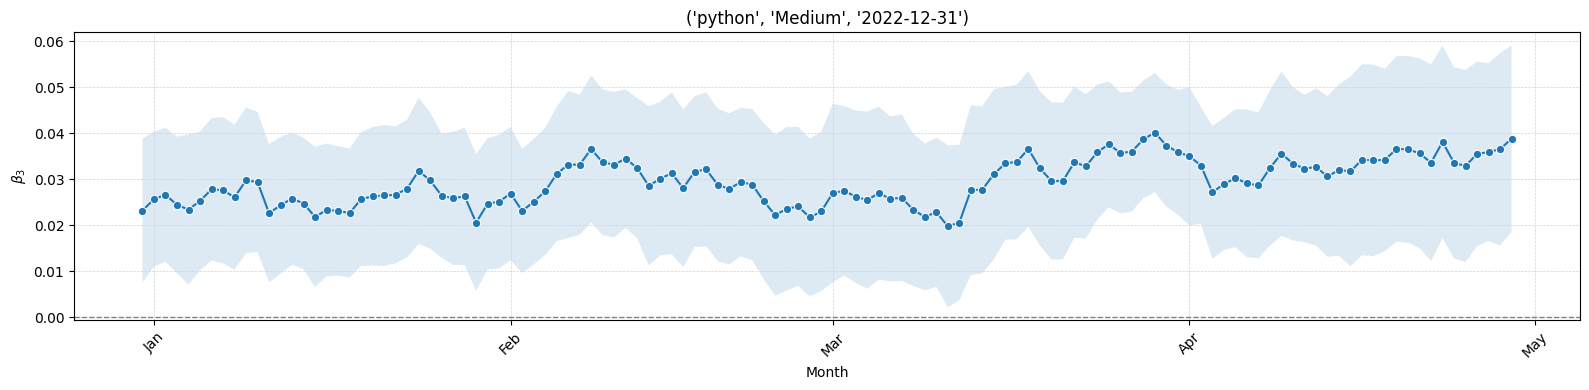

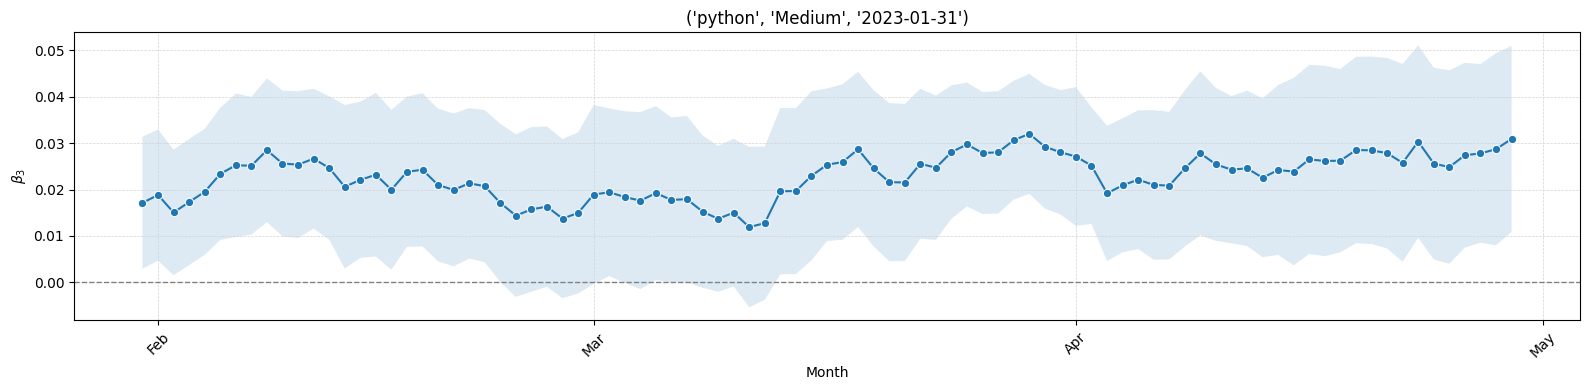

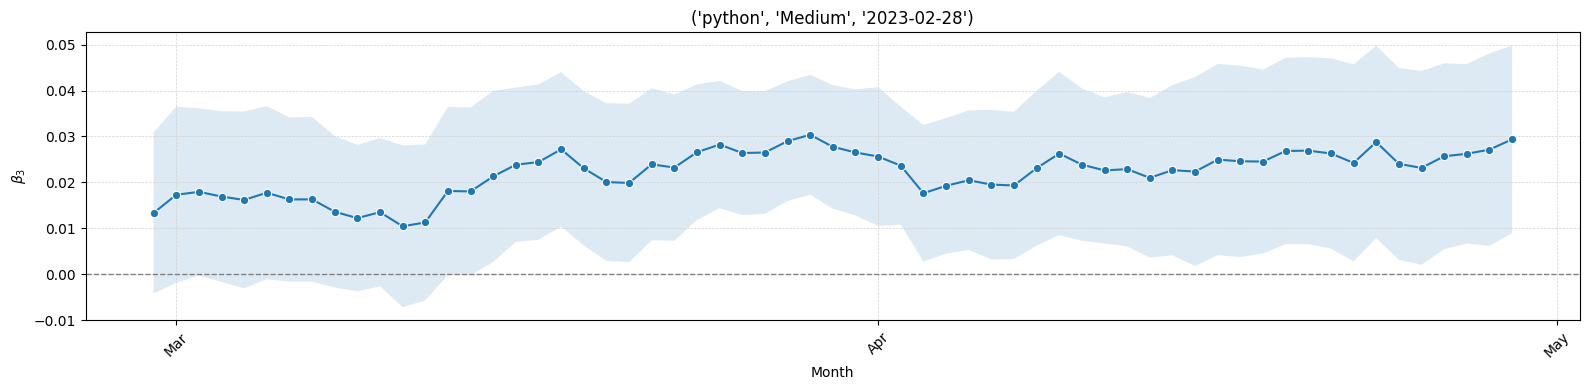

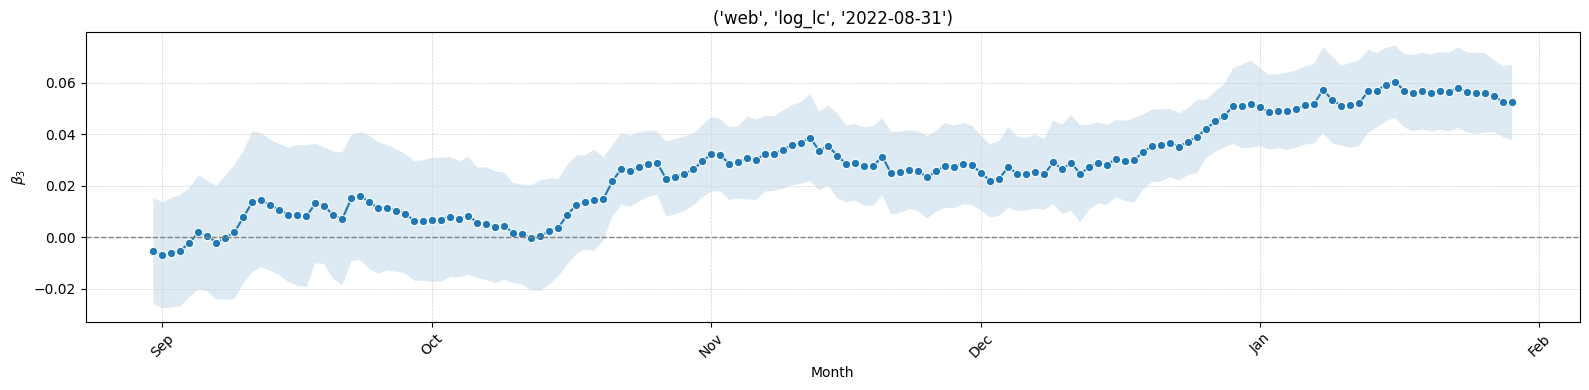

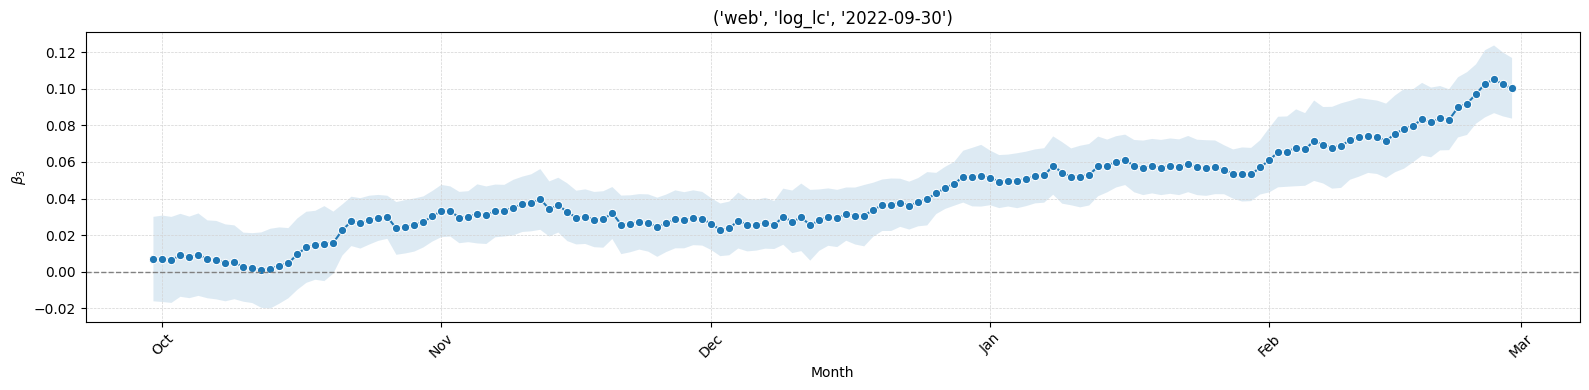

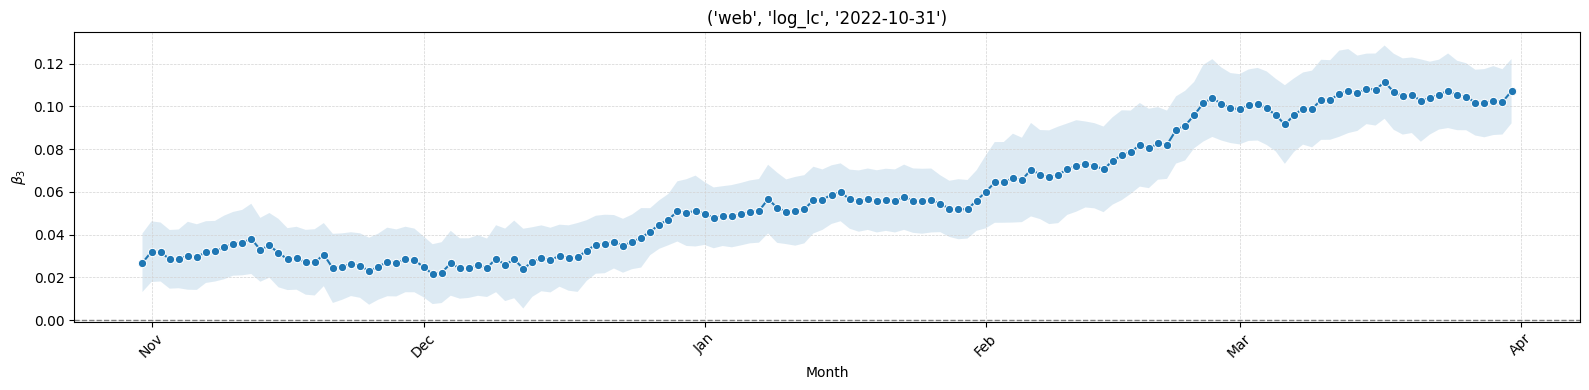

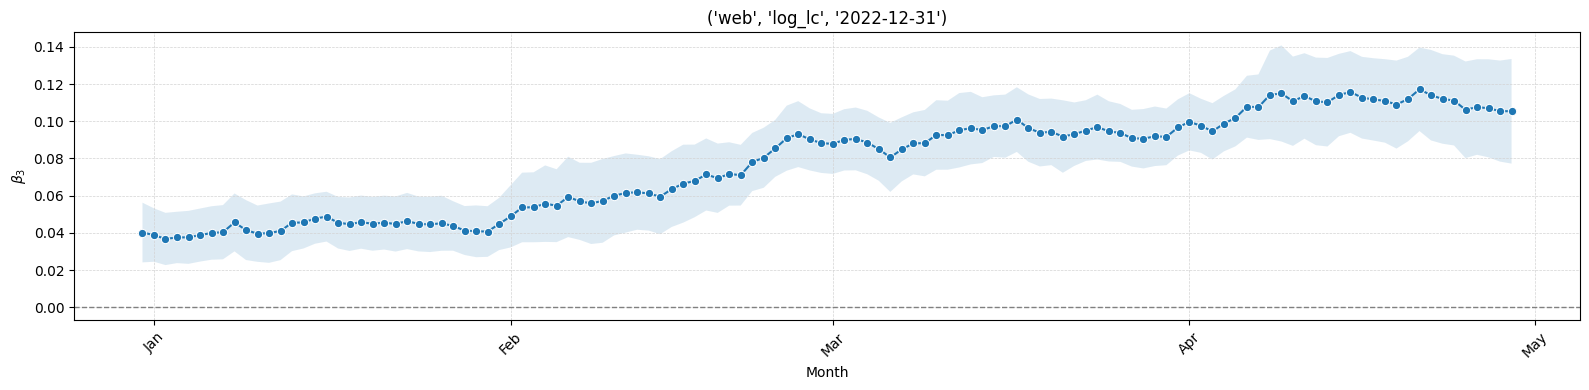

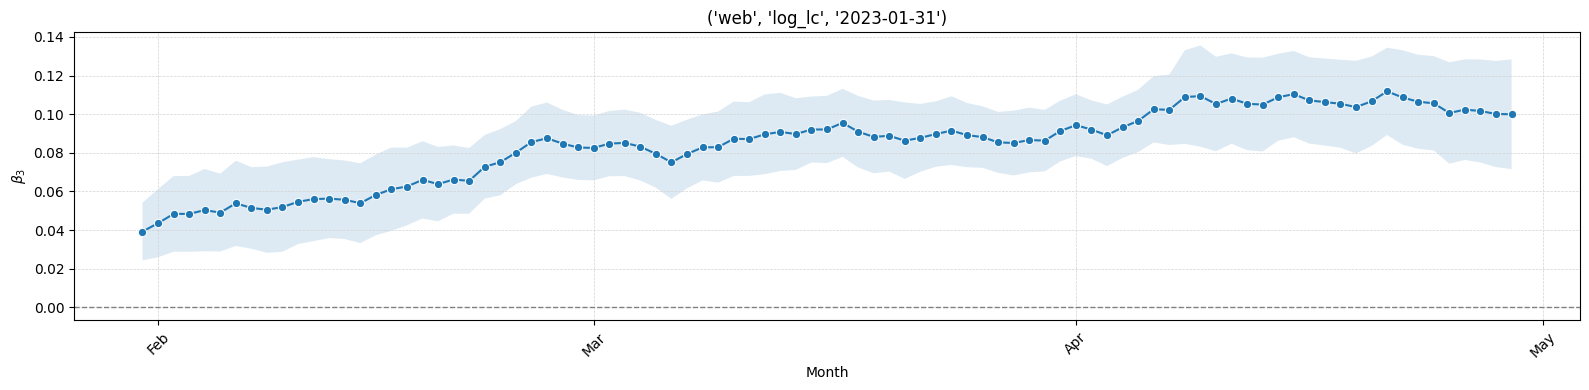

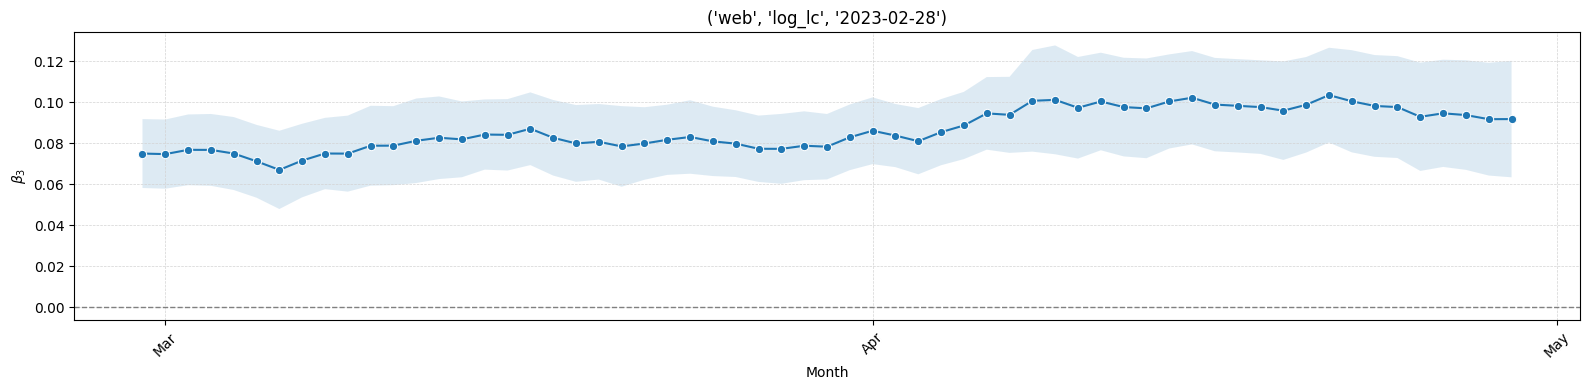

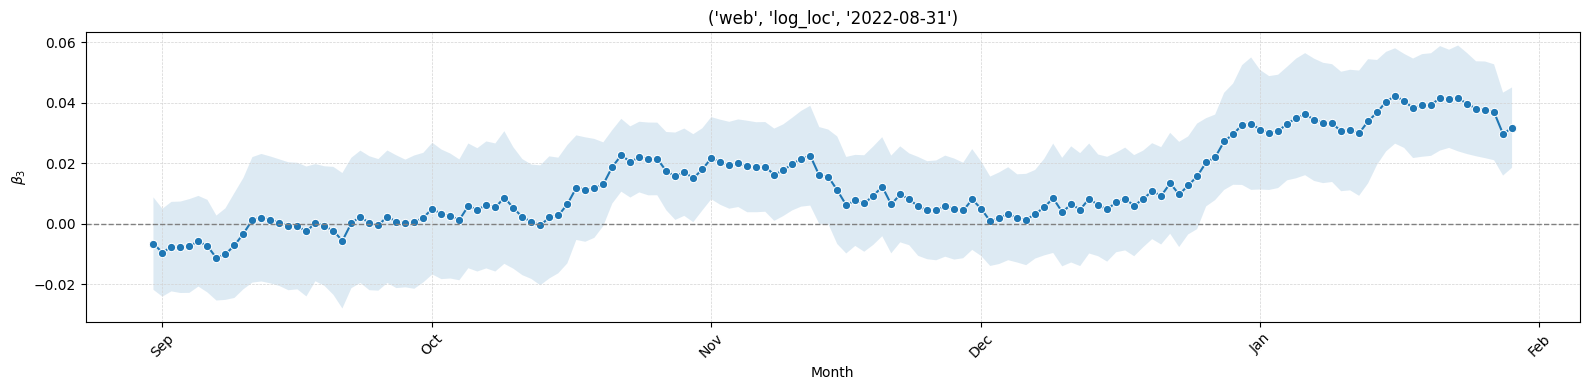

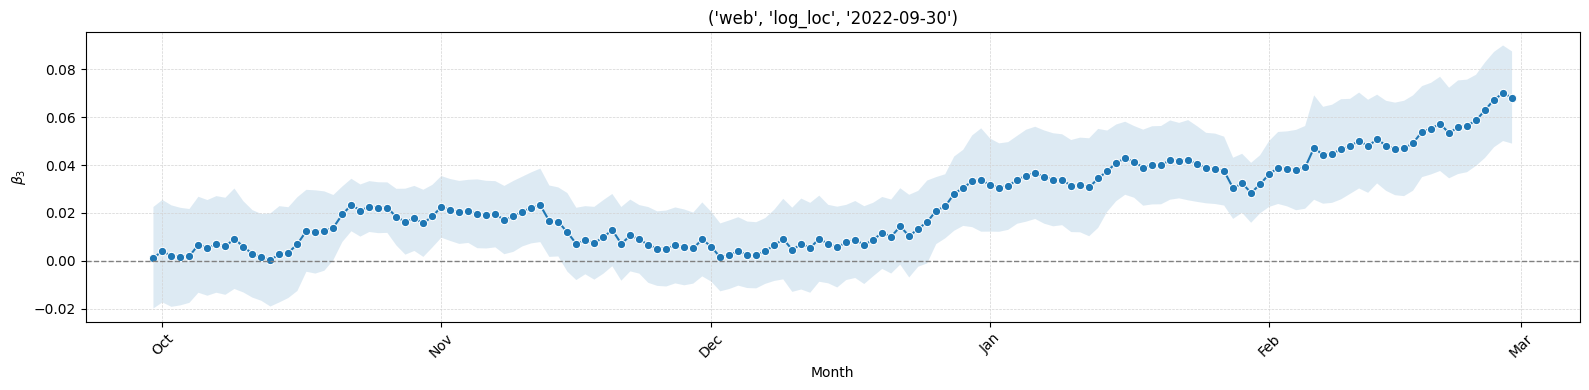

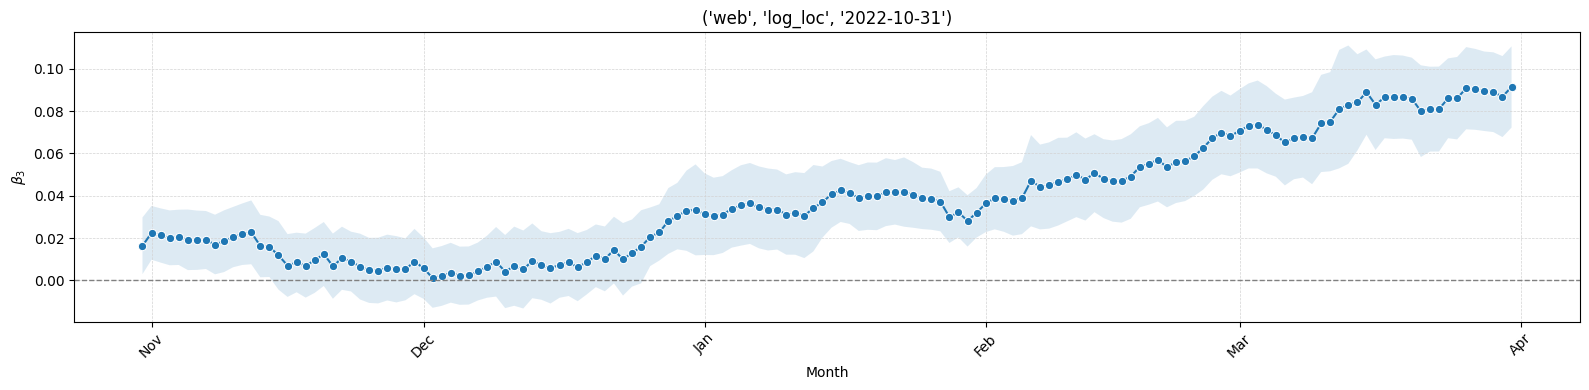

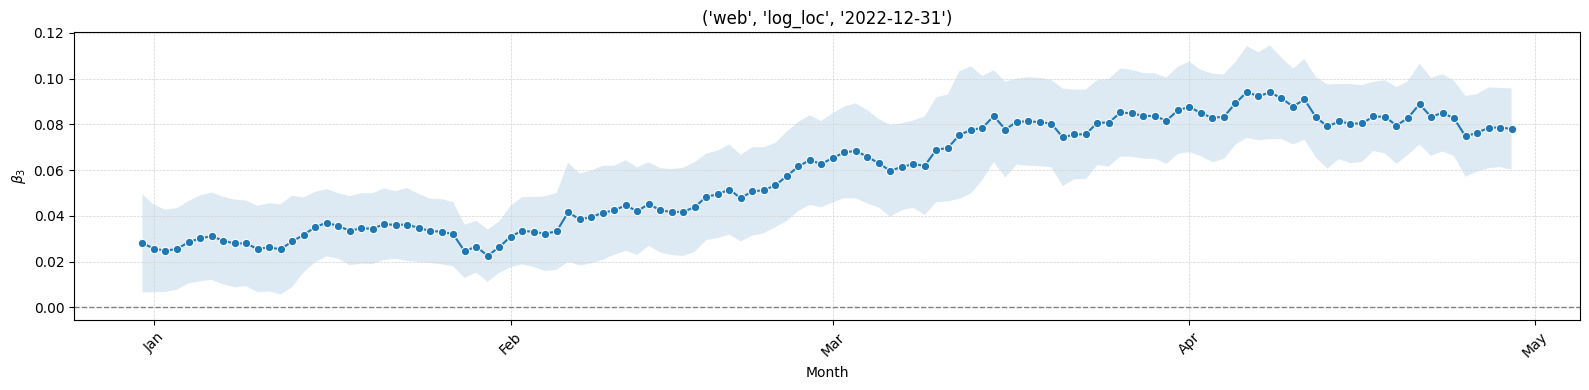

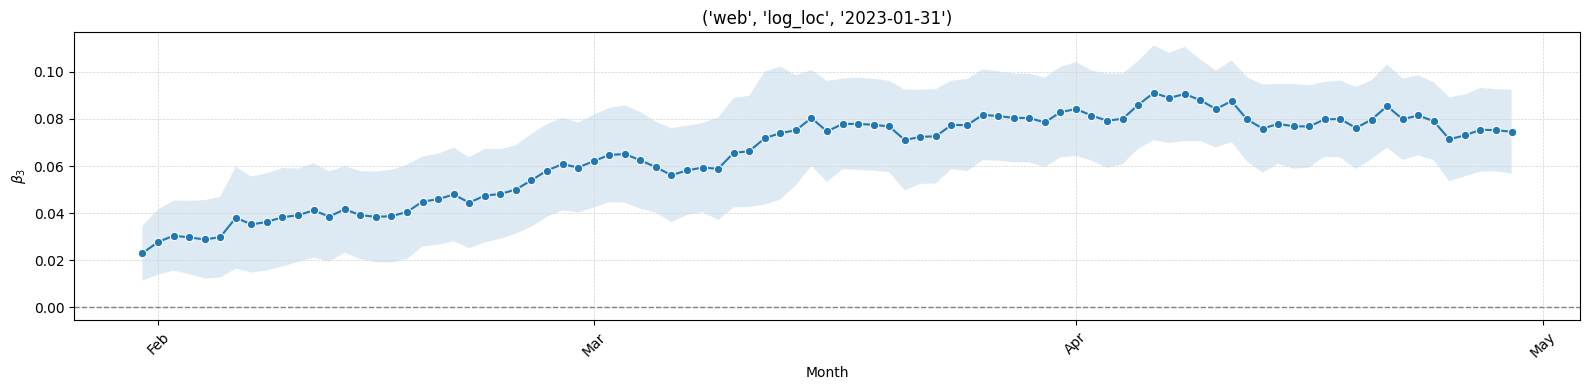

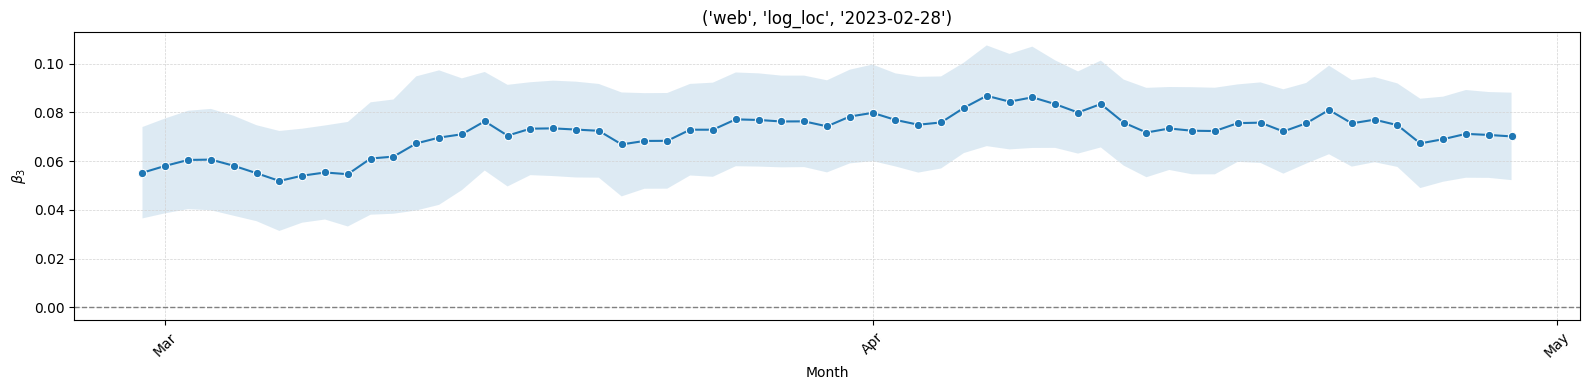

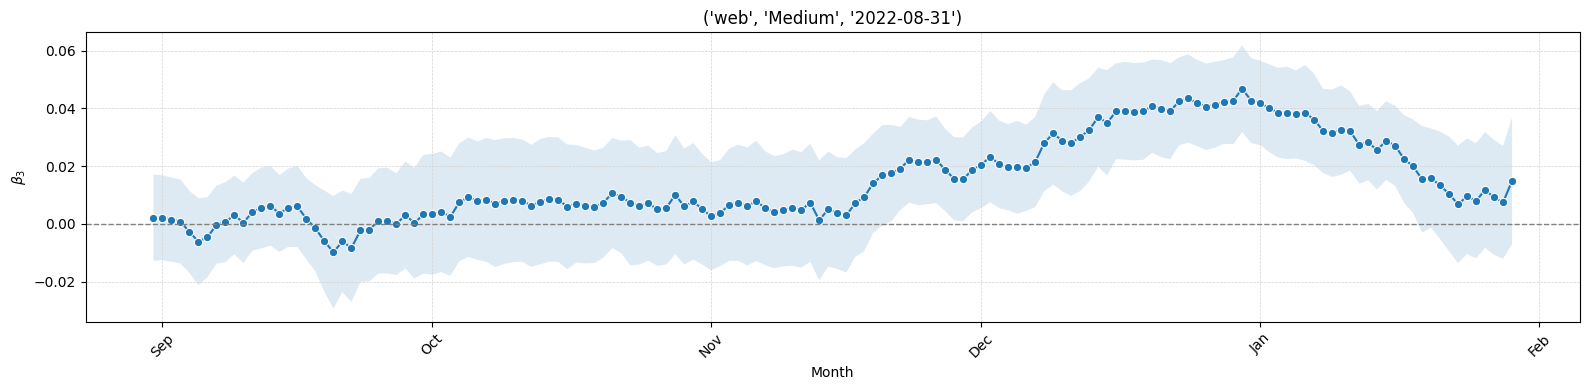

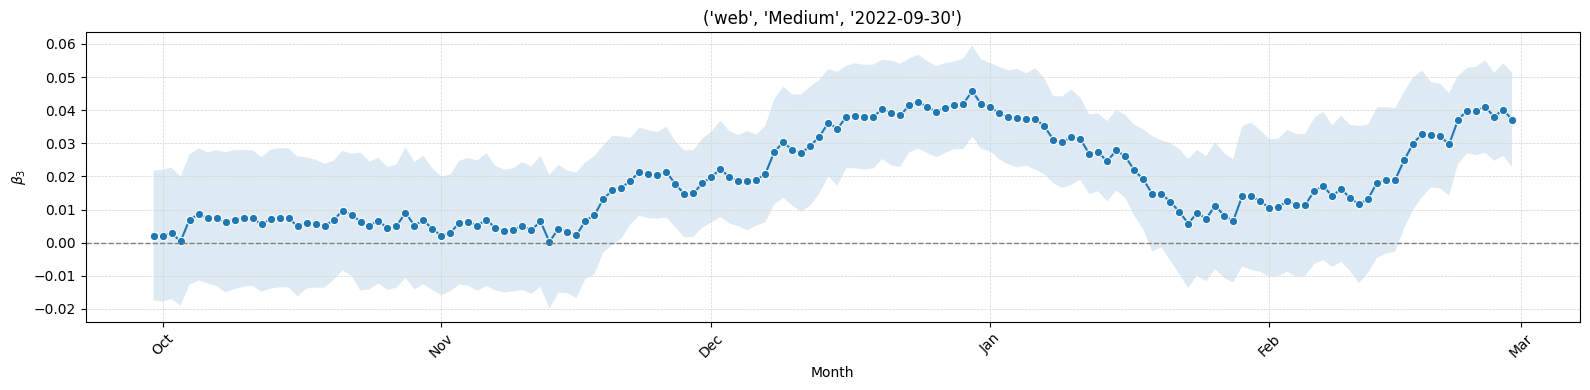

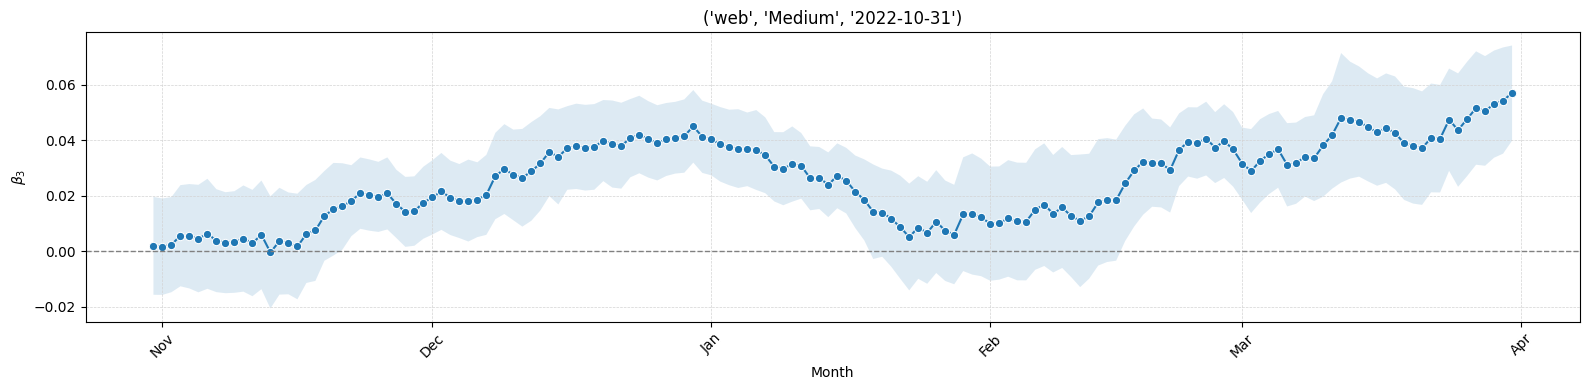

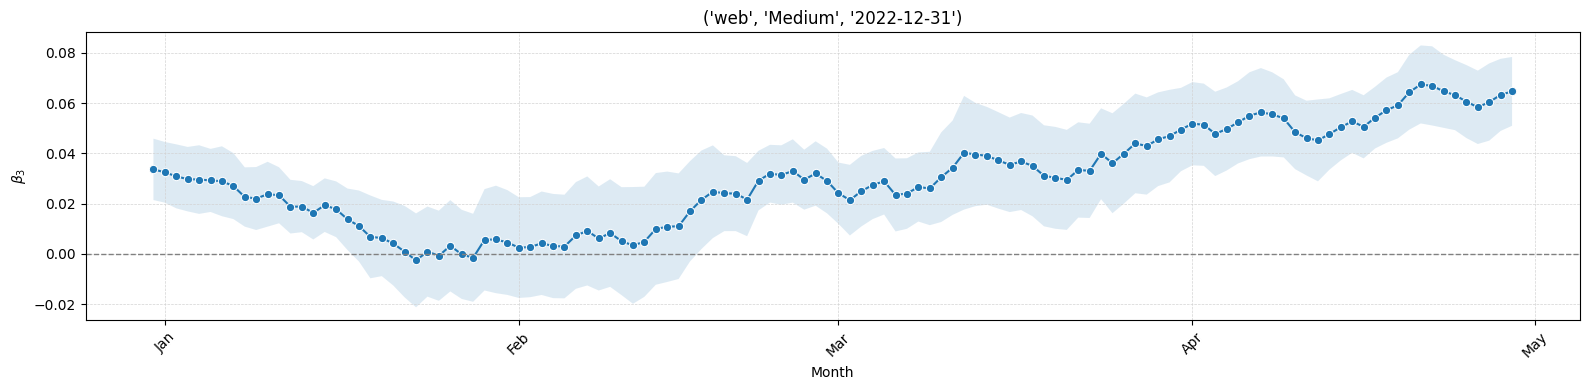

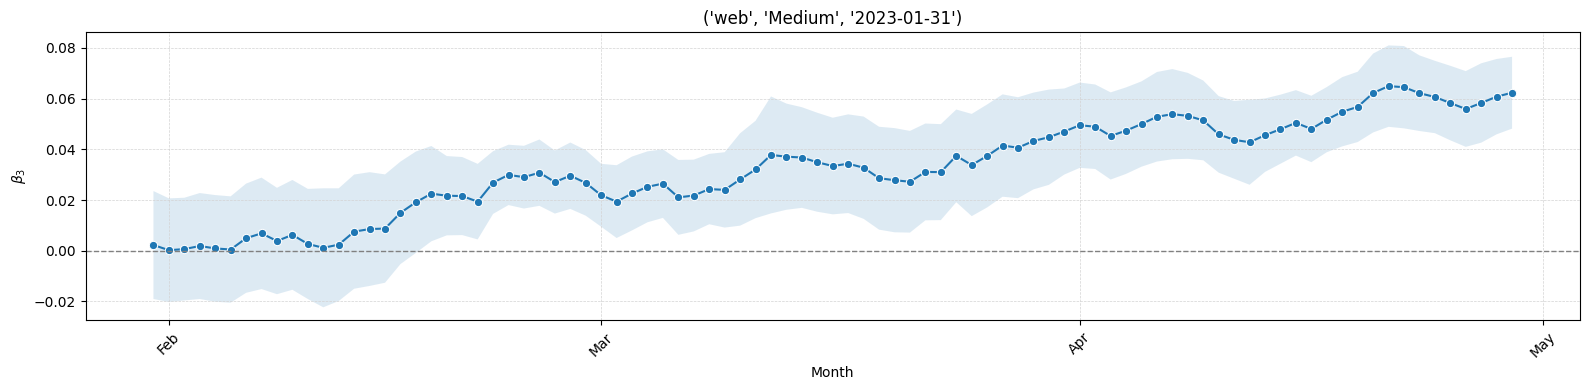

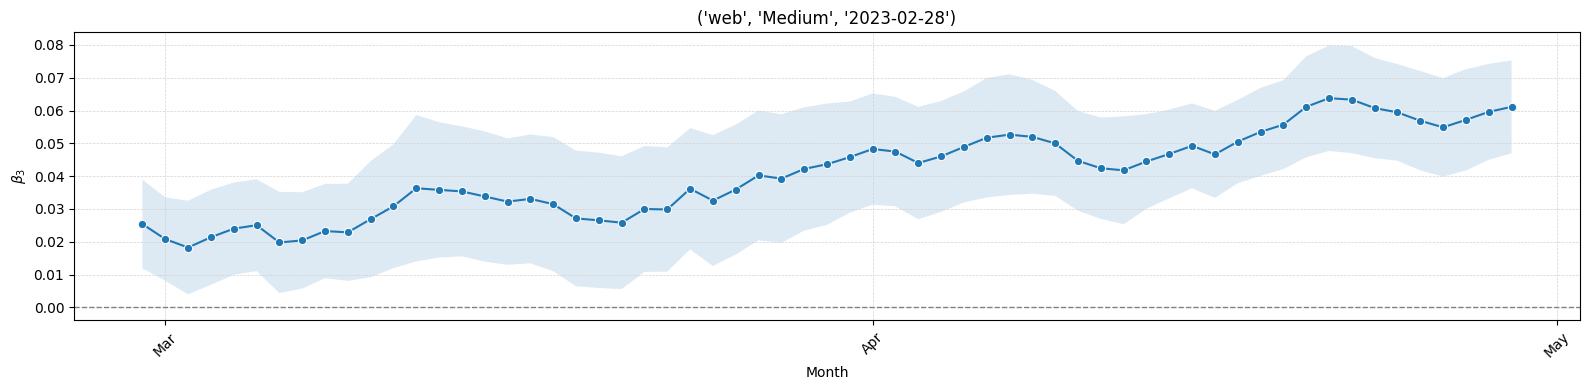

In [21]:
for key, df_res in placebo_results.items():
    so.plot_did(df_res, str(key), 'temp/temp.pdf')